# Karbon Emisyonu Projesi — Exploratory Data Analysis (EDA)

Bu notebook, HF model veri setinin **keşifsel veri analizini (EDA)** adım adım gerçekleştirir.

Bu aşamada:
- Veri temizliği yapılmaz
- Eksik değerler doldurulmaz
- 0 değerleri değiştirilmez
- Feature engineering yapılmaz
- Model kurulmaz

Amaç sadece veri setini **tamamen anlamak**.

---


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
# Gerekli kütüphaneleri yüklüyoruz
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style("whitegrid")

# NOT: df değişkeninin daha önce yüklendiğini varsayıyoruz.
# Eğer değilse, örnek olarak:
# df = pd.read_csv('HF_models_imputed.csv')


In [ ]:
!find /content/drive/MyDrive -name "HF_models_imputed_realistic_v2.csv"

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/grup_proje_veri/HF_models_imputed_realistic_v2.csv')

# 1. BASİT EDA

## 1. Veri Setinin Boyutu

**Neyi inceliyoruz?**
`df.shape` ile veri setindeki toplam satır (kayıt/model) ve sütun (değişken) sayısını görüyoruz.

**Neden önemli?**
Kaç modelin verisiyle çalıştığımızı bilmeden ne örneklem büyüklüğü hakkında yorum yapabiliriz, ne de ileride train/test ayrımı yaparken yeterli veri olup olmadığına karar verebiliriz. Ayrıca eksik değer/aykırı değer oranlarını yüzdeye çevirirken referans noktamız olacak.


In [5]:
# Veri setinin boyutunu inceliyoruz
print("Satır sayısı (kayıt/model sayısı):", df.shape[0])
print("Sütun sayısı (değişken sayısı):", df.shape[1])


Satır sayısı (kayıt/model sayısı): 5227
Sütun sayısı (değişken sayısı): 24


**Çıktıda nelere dikkat etmeliyiz?**
- Satır sayısının beklediğin model sayısına yakın olup olmadığı
- Sütun sayısının verdiğimiz 24 sütunla eşleşip eşleşmediği (eşleşmiyorsa örneğin fazladan bir index sütunu gelmiş olabilir)

**Bu analizi neden yaptık?**
> Veri setinin büyüklüğünü belirleyerek, sonraki tüm analizlerin (eksik değer oranları, kategori dağılımları, model performansı beklentileri) referans çerçevesini oluşturduk.

---


## 2. İlk Kayıtların İncelenmesi

**Neyi inceliyoruz?**
`df.head()` ile veri setinin ilk birkaç satırına göz atıyoruz.

**Neden önemli?**
Sütunların gerçek içeriğini, veri formatını (örneğin sayılar mı metin mi, tarih formatı var mı) ve olası anormallikleri (garip karakterler, boş hücreler) ilk bakışta fark edebiliriz.


In [6]:
# İlk 5 kaydı inceliyoruz
df.head()


,model_id,tier,method,training_flops,emissions_tCO2e,intensity_tCO2e_per_FLOP,model_region,emission_factor_tco2e_per_mwh,training_hardware_type,training_gpu_type,training_tpu_pod,training_token_count,disc.region_text,disclosed.emissions_tco2e,disclosed.electricity_used_mwh,disclosed.emission_factor_tco2e_per_mwh,disclosed.region,inference_gpu_type,inference_gpu_count,parameter_values,sources,modality,type,is_moe
0,01-ai/Yi-1.5-34B,tier2,flops_regression,6.324000e+23,130.000,2.055661e-22,China,0.559552,GPU,NVIDIA A800,N/A (GPU eğitimli),3.600000e+12,China,130.000,232.328845,0.559552,China,NVIDIA A100 80GB,2.0,3.400000e+10,"['https://github.com/01-ai/Yi-1.5', 'https://a...",nlp,transformer,False
1,01-ai/Yi-1.5-34B-Chat,tier2,flops_regression,2.040000e+19,0.073,3.578431e-21,China,0.559552,GPU,NVIDIA A800,N/A (GPU eğitimli),3.600000e+12,China,0.073,0.130462,0.559552,China,NVIDIA RTX 4090,4.0,3.400000e+10,"['https://github.com/01-ai/Yi', 'https://githu...",nlp,transformer,False
2,01-ai/Yi-1.5-6B,tier2,flops_regression,1.116000e+23,37.000,3.315412e-22,China,0.559552,GPU,NVIDIA A800,N/A (GPU eğitimli),3.600000e+12,China,37.000,66.124363,0.559552,China,NVIDIA L40S,1.0,6.000000e+09,['https://internal.replicate.com/lucataco/yi-1...,nlp,transformer,False
3,01-ai/Yi-1.5-6B-Chat,tier2,flops_regression,3.600000e+18,0.021,5.833333e-21,China,0.559552,GPU,NVIDIA A800,N/A (GPU eğitimli),3.600000e+12,China,0.021,0.037530,0.559552,China,NVIDIA T4,1.0,6.000000e+09,"['https://github.com/01-ai/Yi-1.5', 'https://h...",nlp,transformer,False
4,01-ai/Yi-1.5-9B,tier2,flops_regression,1.940000e+23,55.000,2.835052e-22,China,0.559552,GPU,NVIDIA A800,N/A (GPU eğitimli),3.600000e+12,China,55.000,98.292973,0.559552,China,NVIDIA A100 40GB,1.0,9.000000e+09,"['https://github.com/01-ai/Yi-1.5', 'https://a...",nlp,transformer,False


**Çıktıda nelere dikkat etmeliyiz?**
- `model_id` gibi sütunların benzersiz görünen değerler içerip içermediği
- Sayısal sütunlarda beklenmedik metin/string değerler olup olmadığı
- `NaN` (eksik) değerlerin ilk bakışta göze çarpıp çarpmadığı

**Bu analizi neden yaptık?**
> Veri setinin gerçek yapısını ve içeriğini ilk elden görerek, sonraki analizlerde nelere dikkat etmemiz gerektiği konusunda genel bir izlenim edindik.

---


## 3. Sütun İsimleri

**Neyi inceliyoruz?**
`df.columns` ile veri setindeki tüm sütun isimlerini listeliyoruz.

**Neden önemli?**
Sütun isimlerinde boşluk, büyük/küçük harf tutarsızlığı, nokta (`.`) gibi karakterler olup olmadığını görmek, ileride kod yazarken hata almamak için önemli (örneğin `disclosed.emissions_tco2e` gibi nokta içeren isimler `df.disclosed.emissions_tco2e` şeklinde erişilemez, `df['disclosed.emissions_tco2e']` şeklinde erişilmelidir).


In [7]:
# Sütun isimlerini listeliyoruz
print(df.columns.tolist())


['model_id', 'tier', 'method', 'training_flops', 'emissions_tCO2e', 'intensity_tCO2e_per_FLOP', 'model_region', 'emission_factor_tco2e_per_mwh', 'training_hardware_type', 'training_gpu_type', 'training_tpu_pod', 'training_token_count', 'disc.region_text', 'disclosed.emissions_tco2e', 'disclosed.electricity_used_mwh', 'disclosed.emission_factor_tco2e_per_mwh', 'disclosed.region', 'inference_gpu_type', 'inference_gpu_count', 'parameter_values', 'sources', 'modality', 'type', 'is_moe']


In [8]:
# Sütun isimlerindeki noktaları (_) ile değiştiriyoruz
df.columns = df.columns.str.replace('.', '_', regex=False)

# Kontrol
print(df.columns.tolist())

['model_id', 'tier', 'method', 'training_flops', 'emissions_tCO2e', 'intensity_tCO2e_per_FLOP', 'model_region', 'emission_factor_tco2e_per_mwh', 'training_hardware_type', 'training_gpu_type', 'training_tpu_pod', 'training_token_count', 'disc_region_text', 'disclosed_emissions_tco2e', 'disclosed_electricity_used_mwh', 'disclosed_emission_factor_tco2e_per_mwh', 'disclosed_region', 'inference_gpu_type', 'inference_gpu_count', 'parameter_values', 'sources', 'modality', 'type', 'is_moe']


**Çıktıda nelere dikkat etmeliyiz?**
- Nokta (`.`) içeren sütun isimleri (bunlara köşeli parantez ile erişmemiz gerekecek)
- Baştaki/sondaki boşluklar (varsa `.str.strip()` ile temizlenmesi gerekebilir — ama bu adımı ileride yapacağız)

**Bu analizi neden yaptık?**
> İleride yazacağımız kodlarda sütun isimleriyle ilgili hata almamak için isimlerin tam ve doğru halini teyit ettik.

---


## 4. Veri Tipleri ve Genel Bilgi

**Neyi inceliyoruz?**
`df.info()` ile her sütunun veri tipini (int, float, object/string) ve dolu (non-null) değer sayısını görüyoruz.

**Neden önemli?**
Bir sütunun sayısal olması gerekirken `object` (metin) olarak görünmesi, o sütunda beklenmedik karakterler (örneğin "N/A", "-", boşluk) olduğuna işaret edebilir. Bu bilgi, eksik değer analizimiz için de ön bir sinyal verir.


In [9]:
# Veri tipleri ve genel bilgi
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5227 entries, 0 to 5226
Data columns (total 24 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   model_id                                 5227 non-null   str    
 1   tier                                     5227 non-null   str    
 2   method                                   5227 non-null   str    
 3   training_flops                           5227 non-null   float64
 4   emissions_tCO2e                          5227 non-null   float64
 5   intensity_tCO2e_per_FLOP                 5227 non-null   float64
 6   model_region                             5227 non-null   str    
 7   emission_factor_tco2e_per_mwh            5227 non-null   float64
 8   training_hardware_type                   5227 non-null   str    
 9   training_gpu_type                        5227 non-null   str    
 10  training_tpu_pod                         5227 non-null   st

**Çıktıda nelere dikkat etmeliyiz?**
- `training_flops`, `emissions_tCO2e`, `parameter_values` gibi sayısal olması beklenen sütunların `object` (metin) tipinde görünüp görünmediği
- `Non-Null Count` sütunundaki sayının toplam satır sayısından (5227) ne kadar düşük olduğu — bu, eksik değer oranı hakkında ilk fikir verir

**Bu analizi neden yaptık?**
> Sütunların veri tiplerini kontrol ederek, sayısal olması gereken ama metin olarak kaydedilmiş sütunlar olup olmadığını tespit ettik. Bu, ileride veri temizliği aşamasında kritik olacak.

---


## 5. Sayısal Değişkenlerin Temel İstatistikleri

**Neyi inceliyoruz?**
`df.describe()` ile sayısal sütunların count, mean, std, min, çeyrekler (25%-50%-75%) ve max değerlerini inceliyoruz.

Özellikle şu değişkenlere odaklanıyoruz:
`training_flops`, `emissions_tCO2e`, `intensity_tCO2e_per_FLOP`, `emission_factor_tco2e_per_mwh`, `training_token_count`, `disclosed.emissions_tco2e`, `disclosed.electricity_used_mwh`, `disclosed.emission_factor_tco2e_per_mwh`, `inference_gpu_count`, `parameter_values`

**Neden önemli?**
Bu istatistikler, değişkenlerin ölçeğini, aşırı değer (outlier) potansiyelini ve dağılımın simetrik olup olmadığını (mean ile median/50% arasındaki fark) anlamamıza yardımcı olur.


In [10]:
# Sayısal değişkenlerin temel istatistikleri
numeric_cols = [
    'training_flops', 'emissions_tCO2e', 'intensity_tCO2e_per_FLOP',
    'emission_factor_tco2e_per_mwh', 'training_token_count',
    'disclosed_emissions_tco2e', 'disclosed_electricity_used_mwh',
    'disclosed_emission_factor_tco2e_per_mwh', 'inference_gpu_count',
    'parameter_values'
]

df[numeric_cols].describe()


,training_flops,emissions_tCO2e,intensity_tCO2e_per_FLOP,emission_factor_tco2e_per_mwh,training_token_count,disclosed_emissions_tco2e,disclosed_electricity_used_mwh,disclosed_emission_factor_tco2e_per_mwh,inference_gpu_count,parameter_values
count,5.227000e+03,5227.000000,5.227000e+03,5227.000000,5.227000e+03,5227.000000,5227.000000,5227.000000,5227.000000,5.227000e+03
mean,1.336313e+23,11.411590,3.667171e-16,0.422306,2.644742e+12,12.429849,29.328457,0.422215,1.228047,4.590850e+09
std,1.140907e+24,123.247024,2.405659e-14,0.102482,4.177953e+13,138.625453,353.374001,0.102824,7.938027,1.616887e+10
min,7.621000e+00,0.000000,0.000000e+00,0.025000,5.749000e+03,0.000000,0.000000,0.000000,1.000000,5.760000e+03
25%,1.000000e+19,0.020000,3.333333e-22,0.383549,3.226039e+10,0.013500,0.035955,0.383549,1.000000,3.450000e+08
50%,2.444778e+20,1.000000,2.040816e-21,0.445000,9.480000e+10,1.000000,2.413870,0.445000,1.000000,5.600000e+08
75%,1.687246e+22,3.000000,1.335256e-20,0.445000,1.400000e+12,3.000000,9.882517,0.445000,1.000000,4.500000e+09
max,5.076000e+25,8176.000000,1.737818e-12,0.801948,3.000000e+15,8930.000000,23282.541066,0.801948,512.000000,4.800000e+11


**Çıktıda nelere dikkat etmeliyiz?**
- `mean` ile `50%` (medyan) arasındaki büyük fark, dağılımın çarpık olduğuna işaret eder
- `max` değerinin `75%` çeyreğinden çok uzak olması, olası aşırı uç (outlier) değerlere işaret eder
- `min` değerinin `0` olduğu sütunlar (özellikle `emissions_tCO2e`), 0 değer analizimiz için bir ön sinyal
- `count` değerinin 5227'den düşük olduğu sütunlar, eksik değer olduğunu gösterir

**Bu analizi neden yaptık?**
> Sayısal değişkenlerin ölçeğini, merkezi eğilimini ve olası aşırı değer/çarpıklık potansiyelini sayısal olarak ölçtük. Bu, ileride hangi değişkenlerin log-dönüşüm veya outlier işlemi gerektirebileceği konusunda ilk ipucunu verdi.

---


## 6. Kategorik Değişkenlerin Özeti

**Neyi inceliyoruz?**
Aşağıdaki kategorik sütunların unique değer sayılarını, en sık görülen değerlerini ve frekanslarını inceliyoruz:
`tier`, `method`, `model_region`, `training_hardware_type`, `training_gpu_type`, `training_tpu_pod`, `disc.region_text`, `disclosed.region`, `inference_gpu_type`, `modality`, `type`, `is_moe`

**Neden önemli?**
Kategorik değişkenlerin kaç farklı değer aldığını bilmek, ileride bu değişkenleri model için nasıl kodlayacağımızı (one-hot encoding vb.) planlamamıza yardımcı olur. Ayrıca çok nadir görülen kategoriler (örneğin sadece 1-2 kayıtta geçen bir GPU tipi) ileride ayrı ele alınmalı.


In [11]:
# Kategorik değişkenlerin özeti
categorical_cols = [
    'tier', 'method', 'model_region', 'training_hardware_type',
    'training_gpu_type', 'training_tpu_pod', 'disc_region_text',
    'disclosed_region', 'inference_gpu_type', 'modality', 'type', 'is_moe'
]

for col in categorical_cols:
    print(f"--- {col} ---")
    print("Unique değer sayısı:", df[col].nunique())
    print(df[col].value_counts(dropna=False).head(10))
    print()


--- tier ---
Unique değer sayısı: 3
tier
tier2    2623
tier3    1864
tier1     740
Name: count, dtype: int64

--- method ---
Unique değer sayısı: 9
method
flops_regression              2619
mean_values                   1076
parameters_regression          788
direct                         369
flops_estimate                 366
disclosed_energy                 5
post_training_proxy              2
flops_regression_corrected       1
distillation_proxy               1
Name: count, dtype: int64

--- model_region ---
Unique değer sayısı: 75
model_region
Unknown          2183
United States    1354
China             628
USA               176
France            103
Germany           103
South Korea        89
Finland            66
Australia          66
Japan              43
Name: count, dtype: int64

--- training_hardware_type ---
Unique değer sayısı: 3
training_hardware_type
GPU      4875
TPU       338
Other      14
Name: count, dtype: int64

--- training_gpu_type ---
Unique değer sayısı: 195
t

**Çıktıda nelere dikkat etmeliyiz?**
- Unique değer sayısı çok yüksek olan sütunlar (örneğin `training_gpu_type`) — bu, ileride encoding stratejisini etkileyecek
- `NaN` değerin value_counts çıktısında ne kadar yer kapladığı (eksik değer oranı hakkında fikir verir)
- Bir kategorinin veri setinin çoğunluğunu oluşturup oluşturmadığı (dengesiz dağılım / imbalance riski)

**Bu analizi neden yaptık?**
> Kategorik değişkenlerin çeşitliliğini ve dağılımını inceleyerek, hangi değişkenlerin model için kolayca kodlanabileceğini, hangilerinin ise nadir kategoriler nedeniyle özel işlem gerektirebileceğini belirledik.

---


## 7. Eksik Değer Analizi

**Neyi inceliyoruz?**
Her sütundaki eksik (NaN) değer sayısını ve yüzdesini bir tabloda gösteriyor, ardından bunu görselleştiriyoruz.

**Neden önemli?**
Eksik değer oranı, ileride hangi sütunları kullanabileceğimiz, hangilerinin doldurulması (imputation) gerekeceği veya hangilerinin tamamen çıkarılması gerekebileceği konusunda temel bir karar kriteri olacak. Bu aşamada sadece **tespit** ediyoruz, herhangi bir doldurma işlemi yapmıyoruz.


In [12]:
# Eksik değer sayısı ve yüzdesi
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    'Eksik Değer Sayısı': missing_count,
    'Eksik Değer Yüzdesi (%)': missing_percent.round(2)
}).sort_values(by='Eksik Değer Yüzdesi (%)', ascending=False)

missing_table


,Eksik Değer Sayısı,Eksik Değer Yüzdesi (%)
model_id,0,0.0
tier,0,0.0
method,0,0.0
training_flops,0,0.0
emissions_tCO2e,0,0.0
intensity_tCO2e_per_FLOP,0,0.0
model_region,0,0.0
emission_factor_tco2e_per_mwh,0,0.0
training_hardware_type,0,0.0
training_gpu_type,0,0.0


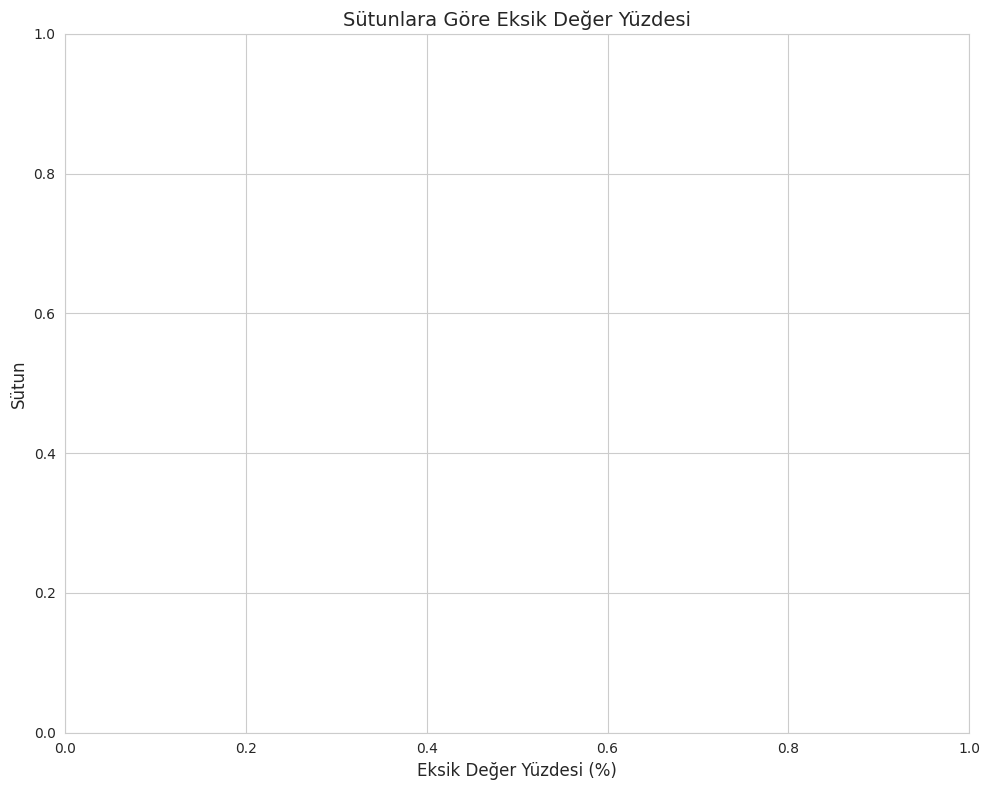

In [13]:
# Eksik değer oranlarını görselleştiriyoruz
plt.figure(figsize=(10, 8))
missing_table_sorted = missing_table[missing_table['Eksik Değer Sayısı'] > 0]

sns.barplot(
    x=missing_table_sorted['Eksik Değer Yüzdesi (%)'],
    y=missing_table_sorted.index,
    color='steelblue'
)
plt.title('Sütunlara Göre Eksik Değer Yüzdesi', fontsize=14)
plt.xlabel('Eksik Değer Yüzdesi (%)', fontsize=12)
plt.ylabel('Sütun', fontsize=12)
plt.tight_layout()
plt.show()


**Çıktıda nelere dikkat etmeliyiz?**
- Eksik değer oranı %50'nin üzerinde olan sütunlar (bu sütunların kullanılabilirliği tartışmalı olabilir)
- `disclosed.` ön ekli sütunların (isteğe bağlı beyan edilen veriler olduğu için) muhtemelen yüksek eksik oranına sahip olması beklenir
- Hedef değişkenimiz olacak `emissions_tCO2e` sütununun eksik değer oranı — bu kritik, çünkü eksik hedef değerli satırlar modelleme aşamasında farklı ele alınmalı

**Bu analizi neden yaptık?**
> Hangi sütunların ne kadar eksik veri içerdiğini net bir şekilde tespit ederek, veri ön işleme aşamasında öncelik sırasını belirlemek için temel oluşturduk.

---


## 8. Duplicate Kayıtlar

**Neyi inceliyoruz?**
Tamamen aynı olan (tüm sütunlarda birebir eşleşen) satır sayısını ve `model_id` sütununun tekrar edip etmediğini kontrol ediyoruz.

**Neden önemli?**
Duplicate kayıtlar, istatistiksel analizleri ve model eğitimini yanlış yönlendirebilir (aynı örneğin birden fazla kez sayılması). Bu aşamada sadece tespit ediyoruz, silme işlemi yapmıyoruz.


In [14]:
# Tamamen duplicate satır sayısı
full_duplicates = df.duplicated().sum()
print("Tamamen duplicate satır sayısı:", full_duplicates)

# model_id tekrar ediyor mu?
duplicate_model_ids = df['model_id'].duplicated().sum()
print("Tekrar eden model_id sayısı:", duplicate_model_ids)

if duplicate_model_ids > 0:
    print("\nTekrar eden model_id örnekleri:")
    print(df[df['model_id'].duplicated(keep=False)].sort_values('model_id')['model_id'].head(20))


Tamamen duplicate satır sayısı: 0
Tekrar eden model_id sayısı: 0


**Çıktıda nelere dikkat etmeliyiz?**
- Tamamen duplicate satır varsa, bu muhtemelen veri toplama/birleştirme sürecinde bir hata işareti
- `model_id` tekrar ediyorsa ama diğer sütunlar farklıysa, bu aynı modelin farklı kaynaklardan/zamanlarda raporlanmış farklı versiyonları olabilir — bu durumda hangisinin "doğru" olduğuna ileride karar vermemiz gerekecek

**Bu analizi neden yaptık?**
> Veri setinde tekrarlayan kayıt olup olmadığını tespit ederek, ileride model eğitiminde yanlılık (bias) yaratabilecek bir problemi erken fark ettik.

---


## 9. Sıfır Değer Analizi

**Neyi inceliyoruz?**
Sayısal sütunlarda kaç adet `0` değeri olduğunu bir tabloda gösteriyoruz. `emissions_tCO2e` sütunundaki 0 değerlerini ayrıca detaylı inceliyoruz.

**Neden önemli?**
Bir sayısal sütunda 0 değeri, gerçek bir ölçüm mü yoksa "veri yok" anlamında mı kullanılmış, bunu ayırt etmek önemli. Özellikle hedef değişkenimiz olacak `emissions_tCO2e`'de 0 değerlerinin gerçek mi yoksa eksik veri yerine konmuş bir placeholder mı olduğunu anlamak, modelleme stratejimizi doğrudan etkileyecek. Bu aşamada sadece tespit ediyoruz, değiştirmiyoruz.


In [15]:
# Sayısal sütunlarda 0 değer sayısı
zero_counts = {}
for col in numeric_cols:
    zero_counts[col] = (df[col] == 0).sum()

zero_table = pd.DataFrame.from_dict(zero_counts, orient='index', columns=['Sıfır Değer Sayısı'])
zero_table['Sıfır Değer Yüzdesi (%)'] = (zero_table['Sıfır Değer Sayısı'] / len(df) * 100).round(2)
zero_table = zero_table.sort_values(by='Sıfır Değer Sayısı', ascending=False)

zero_table


,Sıfır Değer Sayısı,Sıfır Değer Yüzdesi (%)
disclosed_electricity_used_mwh,81,1.55
emissions_tCO2e,80,1.53
disclosed_emissions_tco2e,80,1.53
intensity_tCO2e_per_FLOP,80,1.53
disclosed_emission_factor_tco2e_per_mwh,1,0.02
training_flops,0,0.00
training_token_count,0,0.00
emission_factor_tco2e_per_mwh,0,0.00
inference_gpu_count,0,0.00
parameter_values,0,0.00


In [16]:
# emissions_tCO2e sütunundaki 0 değerleri detaylı inceliyoruz
zero_emissions = df[df['emissions_tCO2e'] == 0]
print("emissions_tCO2e = 0 olan kayıt sayısı:", len(zero_emissions))
print("Toplam veri setine oranı (%):", round(len(zero_emissions) / len(df) * 100, 2))

zero_emissions.head(10)


emissions_tCO2e = 0 olan kayıt sayısı: 80
Toplam veri setine oranı (%): 1.53


,model_id,tier,method,training_flops,emissions_tCO2e,intensity_tCO2e_per_FLOP,model_region,emission_factor_tco2e_per_mwh,training_hardware_type,training_gpu_type,training_tpu_pod,training_token_count,disc_region_text,disclosed_emissions_tco2e,disclosed_electricity_used_mwh,disclosed_emission_factor_tco2e_per_mwh,disclosed_region,inference_gpu_type,inference_gpu_count,parameter_values,sources,modality,type,is_moe
163,CiaraRowles/TemporalNet,tier2,flops_regression,1.913147e+22,0.0,0.0,Unknown,0.445000,GPU,NVIDIA A100,N/A (GPU eğitimli),5.545354e+11,Unknown,0.0,0.0,0.445000,Unknown,NVIDIA T4,1.0,5.750000e+09,Not disclosed,cv & multimodal,adapter,False
231,DiffusionLight/TurboLoRA,tier2,flops_regression,1.913147e+22,0.0,0.0,Thailand,0.554498,GPU,NVIDIA A100,N/A (GPU eğitimli),5.545354e+11,Thailand,0.0,0.0,0.554498,Thailand,NVIDIA T4,1.0,5.750000e+09,['https://github.com/DiffusionLight/DiffusionL...,cv & multimodal,adapter,False
232,DionTimmer/controlnet_qrcode-control_v1p_sd15,tier2,flops_regression,1.913147e+22,0.0,0.0,Unknown,0.445000,GPU,NVIDIA A100,N/A (GPU eğitimli),5.545354e+11,Unknown,0.0,0.0,0.445000,Unknown,NVIDIA T4,1.0,5.750000e+09,['https://huggingface.co/DionTimmer/controlnet...,cv & multimodal,adapter,False
291,Eugeoter/noob-sdxl-controlnet-canny,tier2,flops_regression,1.913147e+22,0.0,0.0,Unknown,0.445000,GPU,NVIDIA A100,N/A (GPU eğitimli),5.545354e+11,Unknown,0.0,0.0,0.445000,Unknown,NVIDIA T4,1.0,5.750000e+09,['https://huggingface.co/Eugeoter/noob-sdxl-co...,cv & multimodal,adapter,False
292,Eugeoter/noob-sdxl-controlnet-depth_midas-v1-1,tier2,flops_regression,1.913147e+22,0.0,0.0,Unknown,0.445000,GPU,NVIDIA A100,N/A (GPU eğitimli),5.545354e+11,Unknown,0.0,0.0,0.445000,Unknown,NVIDIA T4,1.0,5.750000e+09,Not disclosed,cv & multimodal,adapter,False
294,Eugeoter/noob-sdxl-controlnet-tile,tier2,flops_regression,1.913147e+22,0.0,0.0,Unknown,0.445000,GPU,NVIDIA A100,N/A (GPU eğitimli),5.545354e+11,Unknown,0.0,0.0,0.445000,Unknown,NVIDIA T4,1.0,5.750000e+09,['https://huggingface.co/Eugeoter/noob-sdxl-co...,cv & multimodal,adapter,False
488,InstantX/FLUX.1-dev-Controlnet-Canny,tier2,flops_regression,1.913147e+22,0.0,0.0,Germany,0.344140,GPU,NVIDIA A100 80GB,N/A (GPU eğitimli),5.545354e+11,Germany,0.0,0.0,0.344140,Germany,NVIDIA A100 80GB,1.0,5.750000e+09,['https://replicate.com/xlabs-ai/flux-controln...,cv & multimodal,adapter,False
489,InstantX/FLUX.1-dev-Controlnet-Union,tier2,flops_regression,1.913147e+22,0.0,0.0,Unknown,0.445000,GPU,NVIDIA A100,N/A (GPU eğitimli),5.545354e+11,Unknown,0.0,0.0,0.445000,Unknown,NVIDIA T4,1.0,5.750000e+09,['https://huggingface.co/InstantX/FLUX.1-dev-C...,cv & multimodal,adapter,False
538,JujoHotaru/lora,tier2,flops_regression,1.913147e+22,0.0,0.0,Unknown,0.445000,GPU,NVIDIA A100,N/A (GPU eğitimli),5.545354e+11,Unknown,0.0,0.0,0.445000,Unknown,NVIDIA T4,1.0,5.750000e+09,['https://huggingface.co/JujoHotaru/lora'],cv & multimodal,adapter,False
611,Lightricks/LTX-Video-ICLoRA-detailer-13b-0.9.8,tier2,flops_regression,1.913147e+22,0.0,0.0,Israel,0.567262,GPU,NVIDIA A100,N/A (GPU eğitimli),5.545354e+11,Israel,0.0,0.0,0.567262,Israel,NVIDIA RTX 4090,1.0,5.750000e+09,"['https://www.lightricks.com/ltxv', 'https://g...",cv & multimodal,adapter,False


In [17]:
zero_rows = (df[numeric_cols] == 0).any(axis=1)

print("Toplam satır:", len(df))
print("En az bir sayısal sütununda 0 olan satır:", zero_rows.sum())
print("Silme sonrası kalacak satır:", (~zero_rows).sum())

Toplam satır: 5227
En az bir sayısal sütununda 0 olan satır: 81
Silme sonrası kalacak satır: 5146


In [18]:
print("Silmeden önce:", len(df))

df = df[df["disclosed_electricity_used_mwh"] != 0].copy()

print("Sildikten sonra:", len(df))
print("Kalan 0 değerli sütun sayısı = 0 sayısı:", (df["disclosed_electricity_used_mwh"] == 0).sum())

Silmeden önce: 5227
Sildikten sonra: 5146
Kalan 0 değerli sütun sayısı = 0 sayısı: 0


In [19]:
# Sayısal sütunlarda 0 değer sayısı
zero_counts = {}
for col in numeric_cols:
    zero_counts[col] = (df[col] == 0).sum()

zero_table = pd.DataFrame.from_dict(zero_counts, orient='index', columns=['Sıfır Değer Sayısı'])
zero_table['Sıfır Değer Yüzdesi (%)'] = (zero_table['Sıfır Değer Sayısı'] / len(df) * 100).round(2)
zero_table = zero_table.sort_values(by='Sıfır Değer Sayısı', ascending=False)

zero_table

,Sıfır Değer Sayısı,Sıfır Değer Yüzdesi (%)
training_flops,0,0.0
emissions_tCO2e,0,0.0
intensity_tCO2e_per_FLOP,0,0.0
emission_factor_tco2e_per_mwh,0,0.0
training_token_count,0,0.0
disclosed_emissions_tco2e,0,0.0
disclosed_electricity_used_mwh,0,0.0
disclosed_emission_factor_tco2e_per_mwh,0,0.0
inference_gpu_count,0,0.0
parameter_values,0,0.0


**Çıktıda nelere dikkat etmeliyiz?**
- `emissions_tCO2e` sütununda çok sayıda 0 varsa, bunların gerçek sıfır emisyon mu yoksa eksik veri yerine mi kullanıldığı sorgulanmalı (bu, 18. adımda detaylı inceleyeceğimiz konu)
- Diğer sayısal sütunlarda (örneğin `training_flops`) 0 değeri mantıklı mı, yoksa fiziksel olarak imkansız mı (bir modelin FLOP değeri gerçekte 0 olamaz)

**Bu analizi neden yaptık?**
> Sayısal sütunlardaki 0 değerlerinin gerçek ölçüm mü yoksa gizli bir eksik veri işareti mi olduğunu sorgulamak için ilk tespiti yaptık. Bu, veri temizliği aşamasında kritik bir karar noktası olacak.

---


# 2. İLERİ SEVİYE EDA


## 10. Sayısal Değişkenlerin Dağılımları

**Neyi inceliyoruz?**
`training_flops`, `emissions_tCO2e`, `intensity_tCO2e_per_FLOP`, `emission_factor_tco2e_per_mwh`, `training_token_count`, `disclosed.electricity_used_mwh`, `parameter_values` değişkenleri için histogram oluşturuyoruz.

**Neden önemli?**
Dağılımın şekli (simetrik, sağa/sola çarpık, aşırı uçlu), ileride hangi dönüşümlerin (örneğin log dönüşüm) gerekebileceğini ve hangi istatistiksel yöntemlerin uygun olacağını belirler.


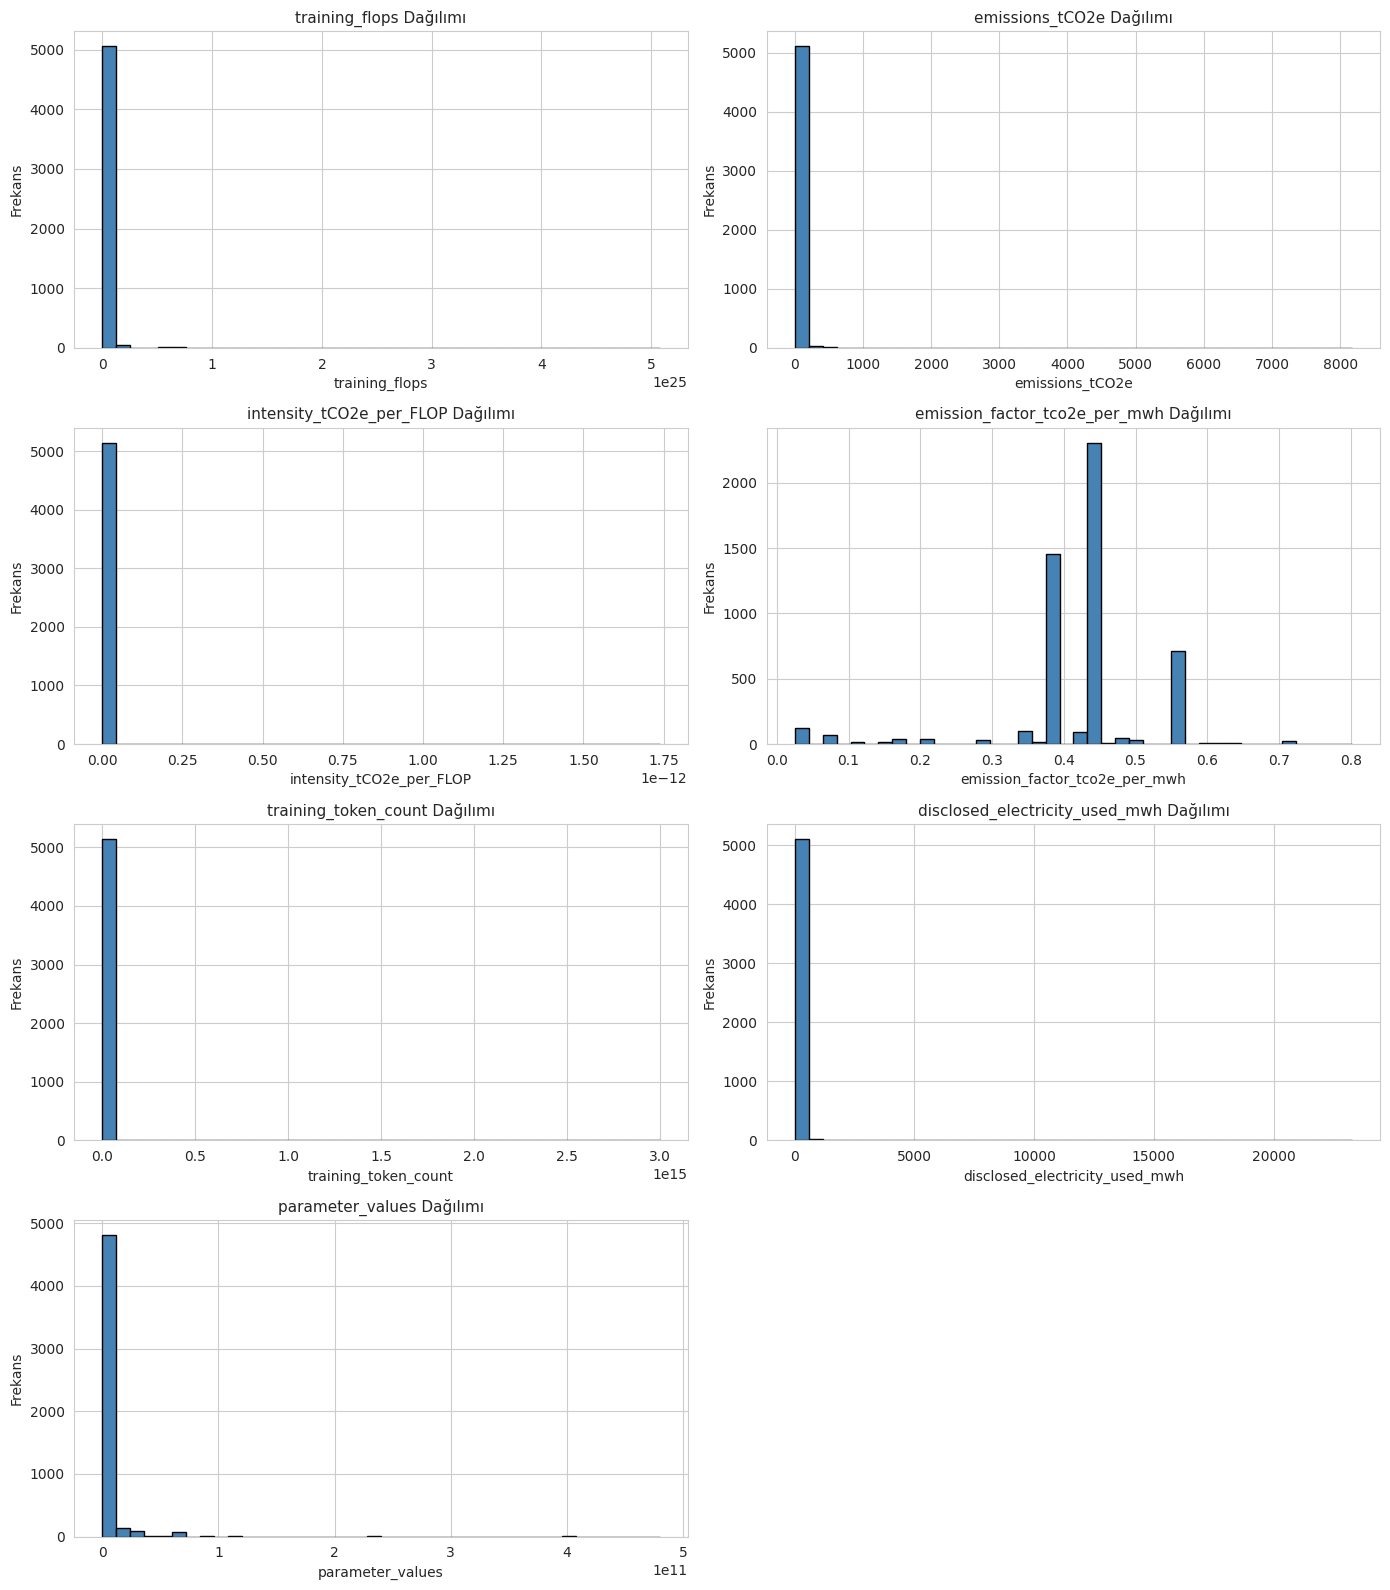

In [20]:
# Sayısal değişkenlerin dağılımları (histogram)
dist_cols = [
    'training_flops', 'emissions_tCO2e', 'intensity_tCO2e_per_FLOP',
    'emission_factor_tco2e_per_mwh', 'training_token_count',
    'disclosed_electricity_used_mwh', 'parameter_values'
]

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(dist_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color='steelblue', edgecolor='black')
    axes[i].set_title(f'{col} Dağılımı', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekans')

# Kullanılmayan son subplot'u gizle
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()


**Nelere bakmalıyız?**
- **Simetrik mi?** Histogramın ortasında yoğunlaşma varsa ve iki yanı benzer şekilde dağılıyorsa simetriktir
- **Sağa çarpık mı (right-skewed)?** Çoğu değer solda toplanmış, sağa doğru uzun bir "kuyruk" varsa (bu, karbon emisyonu/FLOP gibi değişkenlerde çok yaygındır — birkaç dev model, çoğu küçük model)
- **Sola çarpık mı (left-skewed)?** Tam tersi durum
- **Aşırı uç değer var mı?** X ekseninin çok geniş bir aralığa yayılması ama çubukların büyük çoğunluğunun tek bir bölgede toplanması, uç değerlerin varlığına işaret eder

**Bu analizi neden yaptık?**
> Sayısal değişkenlerin dağılım şeklini görselleştirerek, ileride log-dönüşüm gibi işlemlerin gerekip gerekmeyeceğine dair ilk kanıtları topladık. Karbon emisyonu ve FLOP gibi değişkenlerde sağa çarpıklık beklenen bir durumdur çünkü büyük modeller nadir ama etkisi büyüktür.

---


## 11. Boxplot ile Aykırı Değer Analizi

**Neyi inceliyoruz?**
Önemli sayısal değişkenler için boxplot oluşturuyoruz.

**Neden önemli?**
Boxplot, medyan, çeyrekler açıklığı (IQR) ve bu aralığın dışında kalan noktaları (potansiyel outlier) görsel olarak net şekilde gösterir. Bu aşamada sadece hangi değişkenlerde güçlü aykırı değer ihtimali olduğunu belirlemeye çalışıyoruz, silme işlemi yapmıyoruz.


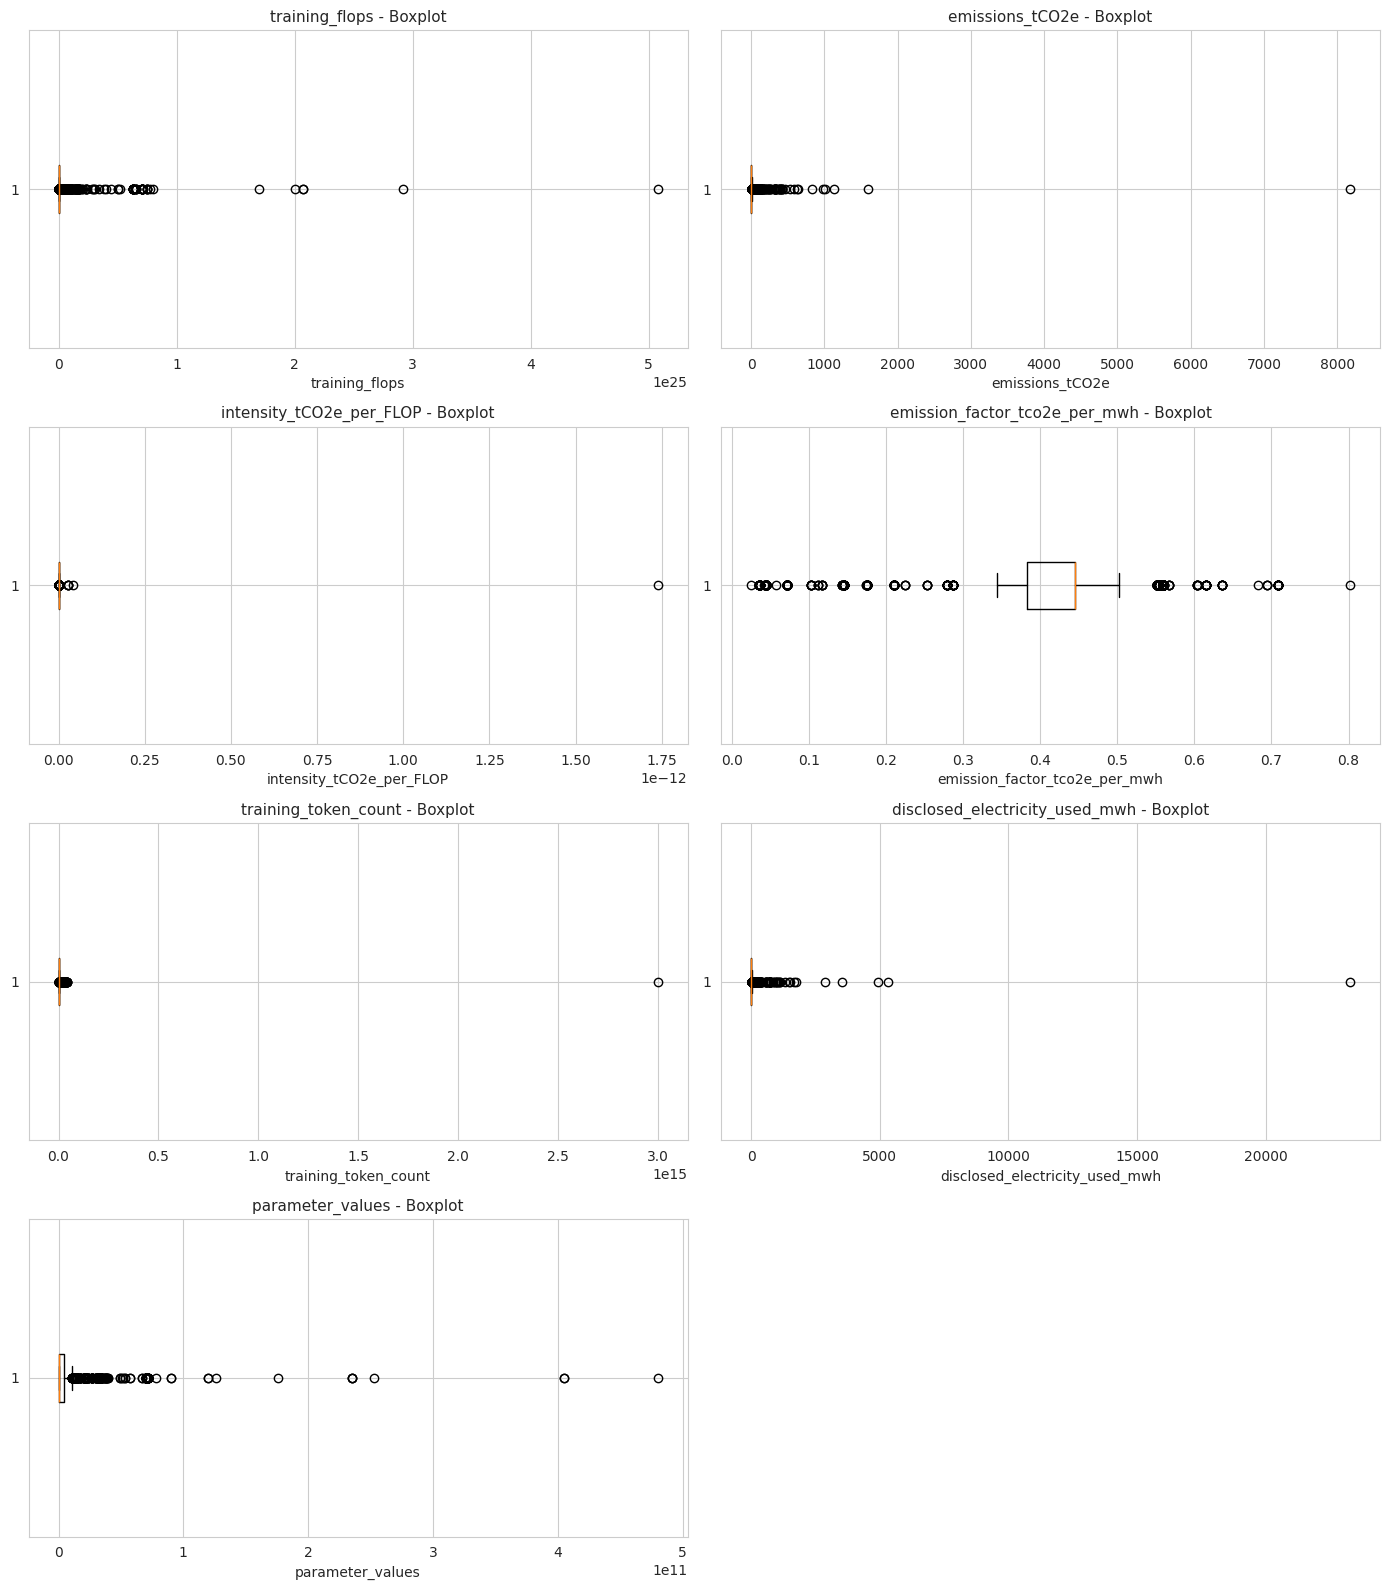

In [21]:
# Boxplot ile aykırı değer analizi
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(dist_cols):
    data = df[col].dropna()
    axes[i].boxplot(data, vert=False)
    axes[i].set_title(f'{col} - Boxplot', fontsize=11)
    axes[i].set_xlabel(col)

fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()


**Çıktıda nelere dikkat etmeliyiz?**
- Kutunun (IQR) dışında kalan çok sayıda nokta varsa, o değişken güçlü outlier potansiyeli taşıyor demektir
- Noktaların ana kutudan ne kadar uzakta olduğu (aşırı uzak noktalar, ölçüm hatası mı yoksa gerçekten çok büyük bir model mi olduğunu sorgulamamızı gerektirir)
- `emissions_tCO2e` ve `training_flops` gibi değişkenlerde outlier'ların "hatalı veri" değil, "gerçekten çok büyük modeller" olabileceğini unutmayalım (örneğin GPT-4 boyutunda bir model)

**Bu analizi neden yaptık?**
> Hangi değişkenlerde aykırı değer riski yüksek olduğunu görsel olarak tespit ederek, ileride outlier işleme stratejisi (silme, capping, log dönüşüm) için ön bilgi topladık.

---


## 12. Korelasyon Analizi

**Neyi inceliyoruz?**
Sayısal sütunlar arasındaki korelasyon matrisini hesaplayıp heatmap ile görselleştiriyoruz. Ayrıca `emissions_tCO2e` ile diğer değişkenlerin korelasyonlarını büyükten küçüğe sıralı bir tabloda gösteriyoruz.

**Neden önemli?**
Hangi değişkenlerin hedef değişkenle (`emissions_tCO2e`) güçlü ilişkili olduğunu görmek, ileride feature seçimi için fikir verir. **Ancak korelasyon nedensellik anlamına gelmez** — sadece iki değişkenin birlikte nasıl hareket ettiğini gösterir.


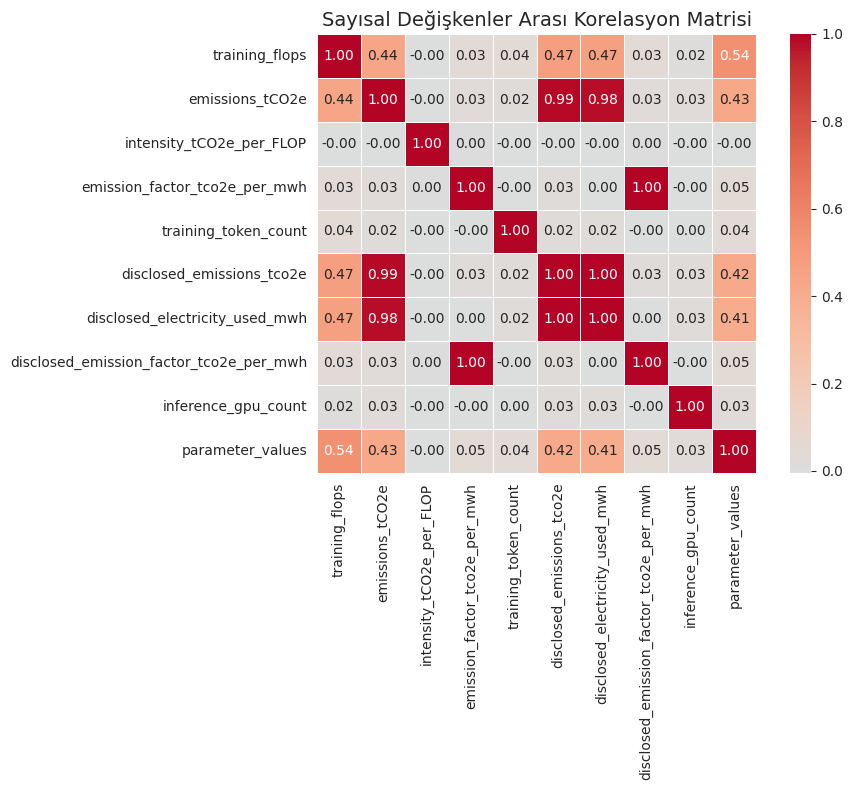

In [22]:
# Korelasyon matrisi
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Sayısal Değişkenler Arası Korelasyon Matrisi', fontsize=14)
plt.tight_layout()
plt.show()


In [23]:
# emissions_tCO2e ile diğer değişkenlerin korelasyonu (büyükten küçüğe)
emissions_corr = corr_matrix['emissions_tCO2e'].drop('emissions_tCO2e').sort_values(ascending=False)
emissions_corr_table = emissions_corr.to_frame(name='Korelasyon (emissions_tCO2e ile)')
emissions_corr_table


,Korelasyon (emissions_tCO2e ile)
disclosed_emissions_tco2e,0.985509
disclosed_electricity_used_mwh,0.977182
training_flops,0.442123
parameter_values,0.425334
disclosed_emission_factor_tco2e_per_mwh,0.031570
emission_factor_tco2e_per_mwh,0.031361
inference_gpu_count,0.027832
training_token_count,0.022951
intensity_tCO2e_per_FLOP,-0.001062


**Çıktıda nelere dikkat etmeliyiz?**
- 1'e yakın (pozitif) veya -1'e yakın (negatif) değerler güçlü ilişkiye işaret eder, 0'a yakın değerler zayıf/ilişkisiz demektir
- `intensity_tCO2e_per_FLOP` gibi hedef değişkenden matematiksel olarak türetilmiş olabilecek değişkenlerle çok yüksek korelasyon görürsek, bu bir **data leakage** işareti olabilir (19. adımda detaylı ele alacağız)
- **Uyarı:** Yüksek korelasyon "A, B'ye neden olur" anlamına gelmez, sadece birlikte değiştiklerini gösterir

**Bu analizi neden yaptık?**
> Hangi sayısal değişkenlerin hedef değişkenle güçlü ilişkili olduğunu tespit ederek, ileride hangi değişkenlerin modelde önemli olabileceği (ve hangilerinin leakage riski taşıyabileceği) konusunda ön bilgi edindik.

---


## 13. emissions_tCO2e ile Önemli Sayısal Değişkenlerin İlişkisi

**Neyi inceliyoruz?**
`training_flops`, `training_token_count`, `parameter_values`, `disclosed.electricity_used_mwh`, `emission_factor_tco2e_per_mwh` değişkenleri ile `emissions_tCO2e` arasında scatterplot oluşturuyoruz.

**Neden önemli?**
Scatterplot, korelasyon katsayısının yakalayamadığı doğrusal olmayan ilişkileri, kümelenmeleri ve outlier'ları görsel olarak ortaya çıkarır.


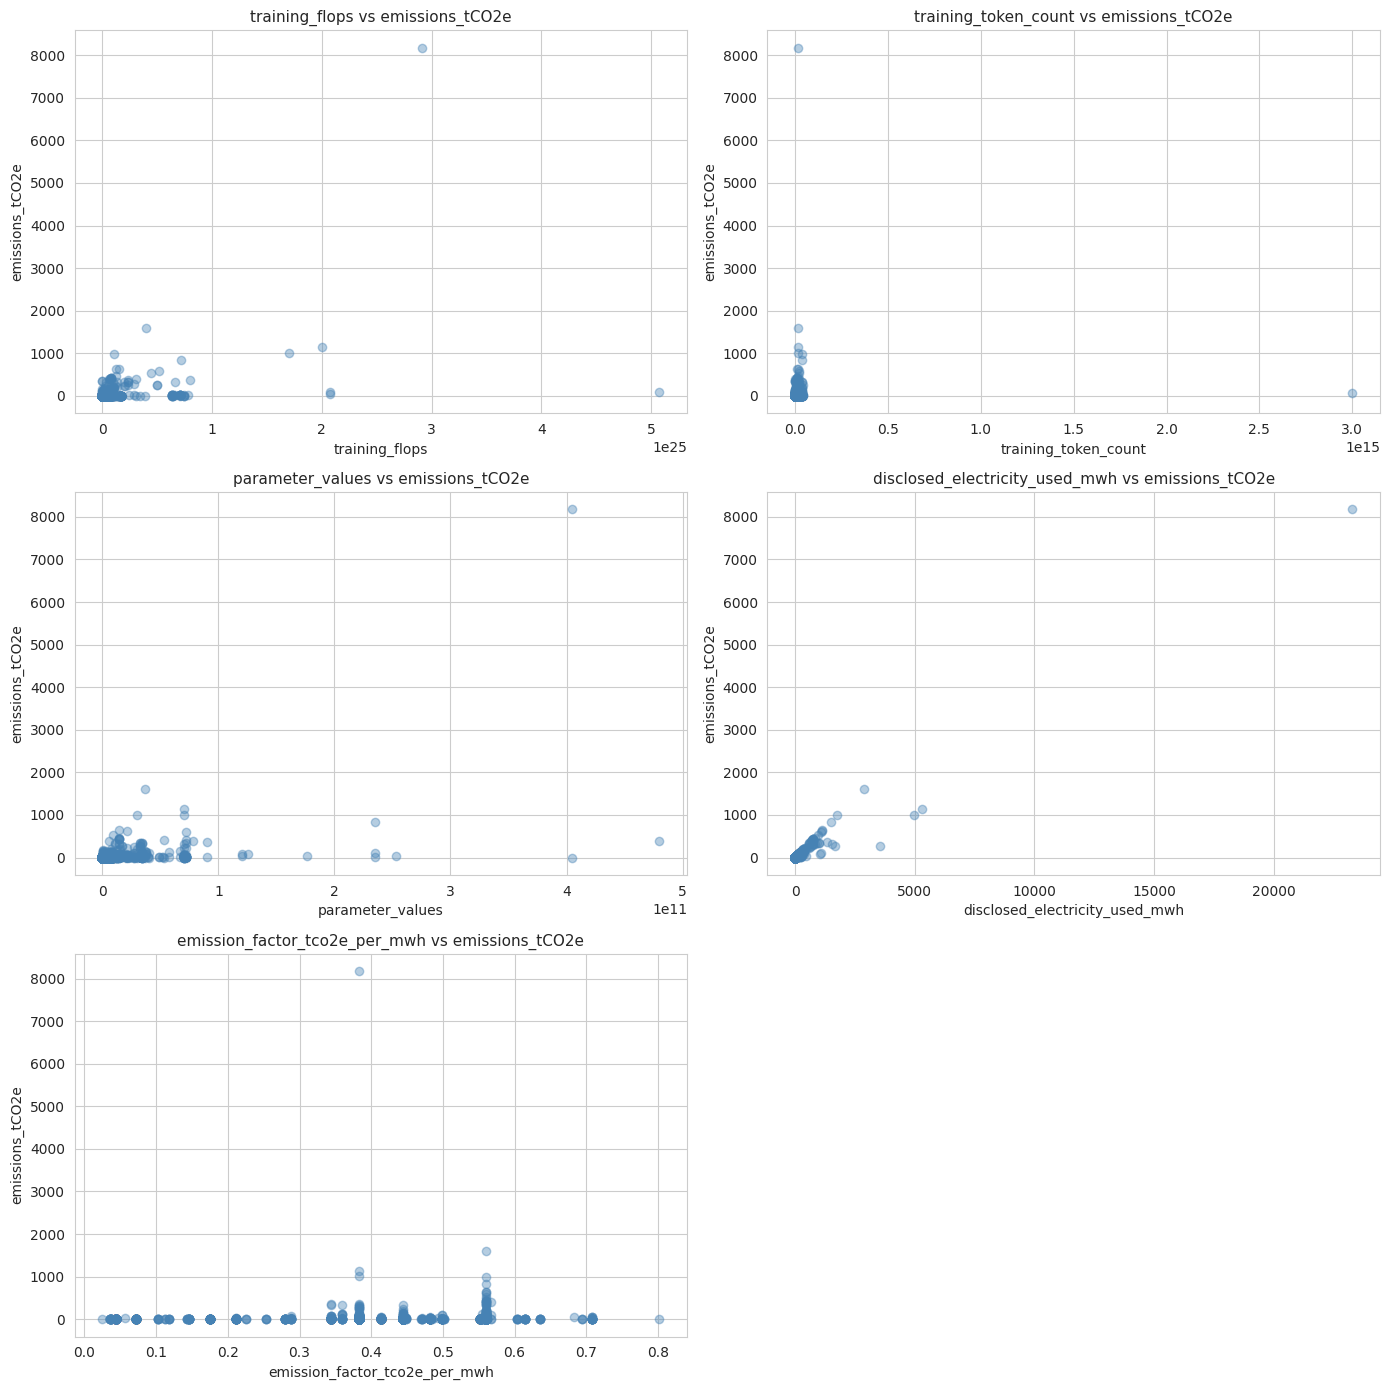

In [24]:
# emissions_tCO2e ile önemli değişkenlerin scatterplot'ları
scatter_cols = [
    'training_flops', 'training_token_count', 'parameter_values',
    'disclosed_electricity_used_mwh', 'emission_factor_tco2e_per_mwh'
]

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(scatter_cols):
    plot_data = df[[col, 'emissions_tCO2e']].dropna()
    axes[i].scatter(plot_data[col], plot_data['emissions_tCO2e'], alpha=0.4, color='steelblue')
    axes[i].set_title(f'{col} vs emissions_tCO2e', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('emissions_tCO2e')

fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()


**Her grafik bize ne anlatabilir?**
- **training_flops vs emissions_tCO2e:** Daha fazla hesaplama (FLOP) genelde daha fazla enerji ve dolayısıyla daha fazla emisyon anlamına gelmeli — pozitif bir eğilim bekleriz
- **training_token_count vs emissions_tCO2e:** Daha fazla veri ile eğitim, eğitim süresini ve enerjiyi artırabilir
- **parameter_values vs emissions_tCO2e:** Daha büyük modellerin (daha fazla parametre) genelde daha fazla emisyona sahip olması beklenir
- **disclosed.electricity_used_mwh vs emissions_tCO2e:** Elektrik tüketimi ile emisyon arasında doğrudan bir ilişki bekleriz (enerji kullanımı arttıkça emisyon da artar)
- **emission_factor_tco2e_per_mwh vs emissions_tCO2e:** Bölgenin enerji karışımının (kömür ağırlıklı mı, yenilenebilir ağırlıklı mı) emisyona etkisini gösterir; ilişki daha zayıf/dağınık olabilir çünkü bu faktör tek başına toplam emisyonu belirlemez

**Bu analizi neden yaptık?**
> Hedef değişkenle ilişkili olması beklenen değişkenlerin gerçekte nasıl bir ilişki sergilediğini görsel olarak doğruladık; doğrusal olmayan ilişkiler veya beklenmedik kümelenmeler olup olmadığını kontrol ettik.

---


## 14. Kategorik Değişkenlere Göre Karbon Emisyonu

**Neyi inceliyoruz?**
`tier`, `method`, `model_region`, `training_hardware_type`, `training_gpu_type`, `modality`, `type`, `is_moe` değişkenlerine göre `emissions_tCO2e` dağılımını; groupby tabloları (median, mean, count) ve boxplot/barplot ile inceliyoruz.

**Neden önemli?**
Bu analiz, hangi kategorik değişkenlerin emisyon seviyesinde belirgin farklılık yarattığını gösterir. Örneğin belirli bir eğitim yöntemi (`method`) veya donanım tipi sistematik olarak daha yüksek emisyona mı yol açıyor?


In [25]:
# Kategorik değişkenlere göre emissions_tCO2e özet tabloları
cat_cols_emission = ['tier', 'method', 'model_region', 'training_hardware_type',
                      'training_gpu_type', 'modality', 'type', 'is_moe']

for col in cat_cols_emission:
    print(f"--- {col} bazında emissions_tCO2e özeti ---")
    summary = df.groupby(col)['emissions_tCO2e'].agg(['count', 'mean', 'median']).sort_values('count', ascending=False)
    print(summary.head(10))
    print()


--- tier bazında emissions_tCO2e özeti ---
       count       mean  median
tier                           
tier2   2543  13.714695    0.92
tier3   1864   2.428683    3.00
tier1    739  27.373271    0.31

--- method bazında emissions_tCO2e özeti ---
                            count       mean     median
method                                                 
flops_regression             2539  13.715505   0.920000
mean_values                  1076   2.980548   3.000000
parameters_regression         788   1.675121   0.086000
direct                        369  39.285414   0.250000
flops_estimate                365  15.576793   0.380000
disclosed_energy                5   9.400000  13.000000
post_training_proxy             2   8.326224   8.326224
distillation_proxy              1   0.150000   0.150000
flops_regression_corrected      1  36.000000  36.000000

--- model_region bazında emissions_tCO2e özeti ---
               count       mean   median
model_region                            
U

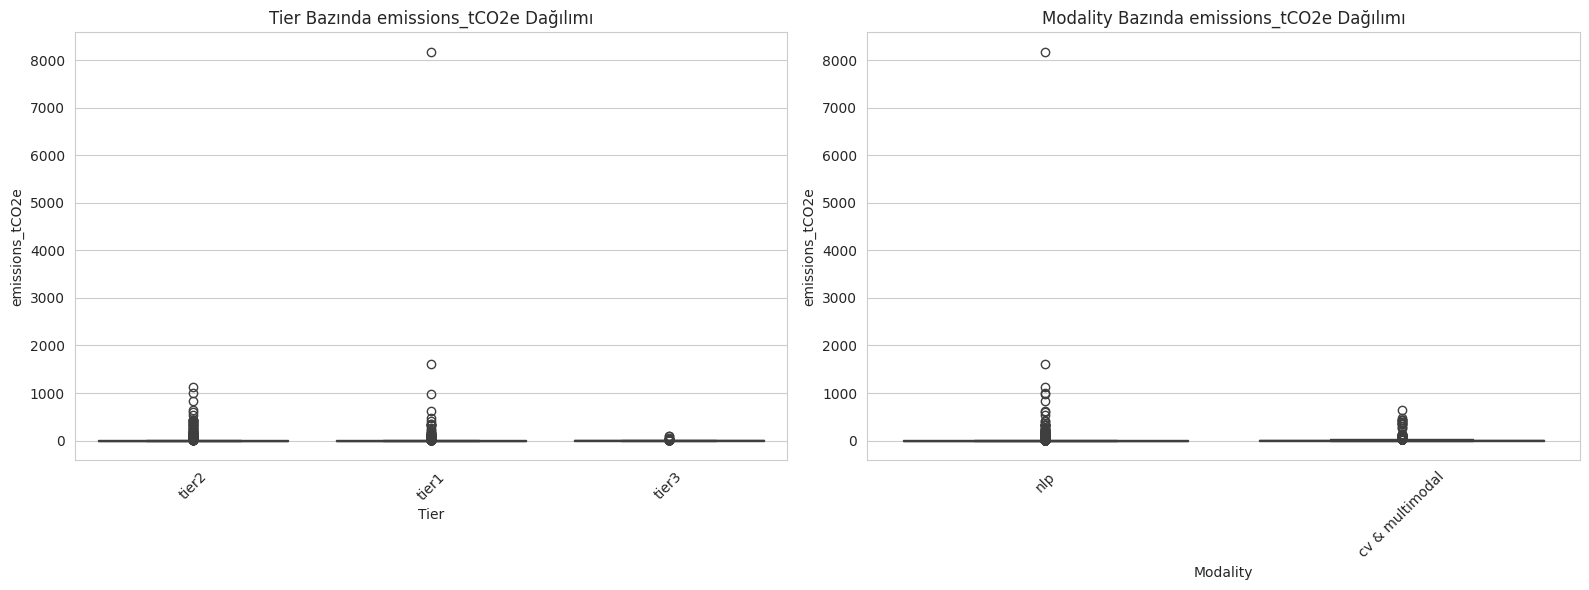

In [26]:
# En sık görülen kategorilere göre boxplot (örnek: tier ve modality)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# tier bazında boxplot
sns.boxplot(data=df, x='tier', y='emissions_tCO2e', ax=axes[0])
axes[0].set_title('Tier Bazında emissions_tCO2e Dağılımı', fontsize=12)
axes[0].set_xlabel('Tier')
axes[0].set_ylabel('emissions_tCO2e')
axes[0].tick_params(axis='x', rotation=45)

# modality bazında boxplot
sns.boxplot(data=df, x='modality', y='emissions_tCO2e', ax=axes[1])
axes[1].set_title('Modality Bazında emissions_tCO2e Dağılımı', fontsize=12)
axes[1].set_xlabel('Modality')
axes[1].set_ylabel('emissions_tCO2e')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


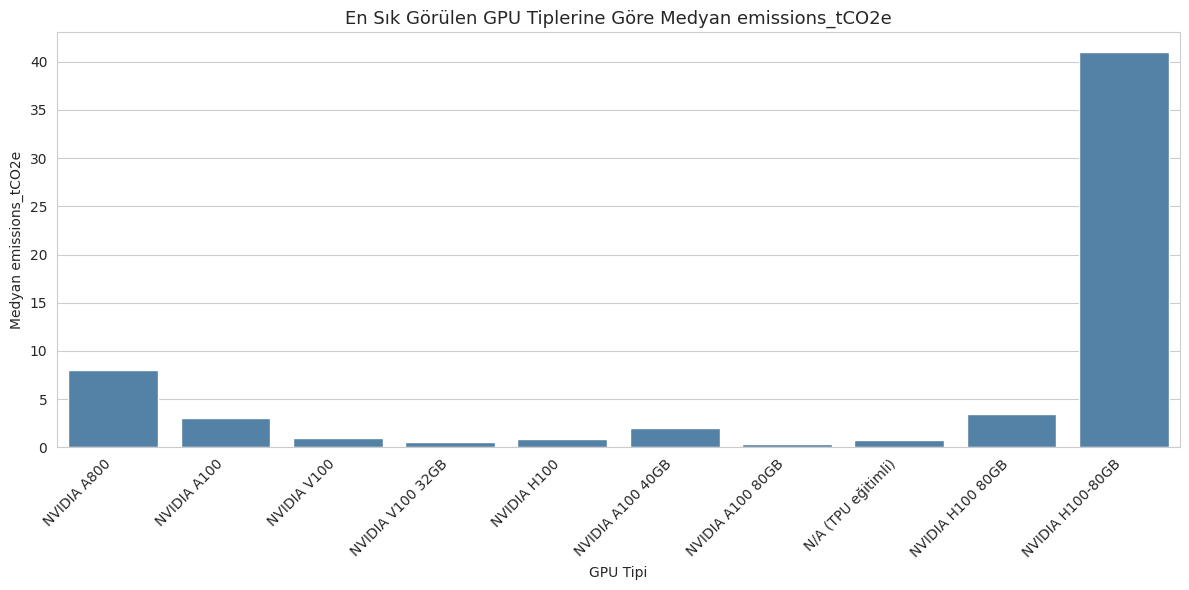

In [27]:
# En sık görülen training_gpu_type kategorileri için barplot (top 10)
top_gpu_types = df['training_gpu_type'].value_counts().head(10).index
df_top_gpu = df[df['training_gpu_type'].isin(top_gpu_types)]

plt.figure(figsize=(12, 6))
sns.barplot(data=df_top_gpu, x='training_gpu_type', y='emissions_tCO2e',
            estimator='median', errorbar=None, color='steelblue')
plt.title('En Sık Görülen GPU Tiplerine Göre Medyan emissions_tCO2e', fontsize=13)
plt.xlabel('GPU Tipi')
plt.ylabel('Medyan emissions_tCO2e')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Çıktıda nelere dikkat etmeliyiz?**
- `count` değeri çok düşük olan kategorilerde (örneğin sadece 2-3 kayıt), mean/median değerleri güvenilir olmayabilir — yorum yaparken temkinli olmalıyız
- Boxplot'larda kategoriler arası medyan farkları belirginse, bu değişken modelde önemli bir feature olabilir
- `is_moe` (Mixture of Experts) gibi ikili (binary) değişkenlerde iki grup arasındaki fark özellikle dikkat çekicidir

**Bu analizi neden yaptık?**
> Kategorik değişkenlerin karbon emisyonu üzerindeki potansiyel etkisini karşılaştırarak, ileride model için hangi kategorik değişkenlerin ayırt edici olabileceğini belirledik.

---


## 15. Bölge Analizi

**Neyi inceliyoruz?**
`model_region`, `disc.region_text`, `disclosed.region` sütunlarının birbiriyle ne kadar uyumlu olduğunu çapraz tablolarla inceliyoruz. Ayrıca bölgelere göre emisyon faktörü ve `emissions_tCO2e` farklarını inceliyoruz.

**Neden önemli?**
Üç farklı bölge sütununun olması, veri setinin farklı kaynaklardan/aşamalardan geldiğini gösteriyor olabilir. Bunların ne kadar tutarlı olduğunu bilmek, ileride hangi bölge sütununu "ana kaynak" olarak kullanacağımıza karar vermemizde kritik.


In [28]:
# Bölge sütunlarının çapraz tablosu (model_region vs disclosed.region)
cross_tab_1 = pd.crosstab(df['model_region'], df['disclosed_region'], dropna=False)
print("model_region vs disclosed_region çapraz tablosu:")
cross_tab_1


model_region vs disclosed_region çapraz tablosu:


disclosed_region,Albania,Argentina,Bangladesh,Belgium,Brazil,Canada,Chile,China,China (Ulanqab) and Singapore,Cloud TPU (Google),Croatia,Czech Republic,Denmark,EU‑Ireland,East US,East US (assumed),Egypt,Finland,France,French supercluster Jean-Zay,Germany,"Guadalupe, Nuevo Leon, Mexico",Hong Kong,Hungary,India,Indonesia,"International (EleutherAI, global open-source)",Iran,Ireland,Israel,Italy,Japan,Kazakhstan,Malaysia,Mexico,Montreal,Nepal,Netherlands,Norway,"Phoenix, AZ",Poland,Portugal,Qatar,Romania,Saudi Arabia,Singapore,South Korea,Spain,Sweden,Switzerland,Taiwan,Thailand,Tunisia,Turkey,Türkiye,UAE,UK,US-east,USA,US‑east,United Arab Emirates,United States,Unknown,Viet Nam,Vietnam,Vietnam (Vietnamese team),West US 2,West US 2,West US 2,low‑carbon nuclear energy,"Île‑de‑France, France"
model_region,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Albania,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Argentina,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Australia,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,66,0,0,0,0,0,0,0,0,0,0,0,0
Bangladesh,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Belgium,0,0,0,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
United States or global (Google DeepMind),0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
Unknown,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2126,0,0,0,0,0,0,0,0
Viet Nam,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0


In [29]:
# model_region vs disc.region_text çapraz tablosu
cross_tab_2 = pd.crosstab(df['model_region'], df['disc_region_text'], dropna=False)
print("model_region vs disc_region_text çapraz tablosu:")
cross_tab_2


model_region vs disc_region_text çapraz tablosu:


disc_region_text,Albania,Argentina,Bangladesh,Belgium,"Bozeman, Montana, USA (Snowflake HQ)",Brazil,Canada,Chile,China,China (Ulanqab) and Singapore regions for training large models,Cloud TPU (Google),Croatia,Czech Republic,Denmark,EU‑Ireland,Egypt,Finland,France,France (CINES ADASTRA HPC cluster),France (CINES ADASTRA cluster),France (low‑carbon nuclear energy),French supercluster Jean-Zay,Germany,"Guadalupe, Nuevo Leon, Mexico",Hong Kong,Hungary,India,Indonesia,"International (EleutherAI, global open-source)",Iran,Ireland,Israel,Italy,Japan,Kazakhstan,"LUMI supercomputer, CSC - IT Center for Science, Finland","LUMI supercomputer, Finland (EuroHPC, hosted by CSC)",Malaysia,Mexico,Montreal,Nepal,Netherlands,Norway,"Phoenix, AZ",Poland,Portugal,Qatar,Romania,Saudi Arabia,Singapore,South Korea,Spain,Sweden,Switzerland,Taiwan,Thailand,Tunisia,Turkey,Türkiye,UAE,UK,US-east,USA,US‑east,US‑east (for SD v1 estimate),United Arab Emirates,Unknown,Viet Nam,Vietnam,Vietnam (Vietnamese team),West US 2,West US 2,West US 2,"Wroclaw, Poland",assumed East US,low‑carbon nuclear energy,"low‑carbon nuclear energy cluster at CINES ADASTRA, France","Île‑de‑France, France"
model_region,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Albania,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Argentina,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Australia,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,66,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Bangladesh,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Belgium,0,0,0,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
United States or global (Google DeepMind),0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Unknown,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2126,0,0,0,0,0,0,0,0,0,0,0
Viet Nam,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0


In [30]:
# Bölgelere göre emisyon faktörü ve emissions_tCO2e farkları
region_summary = df.groupby('model_region').agg(
    kayit_sayisi=('model_id', 'count'),
    ortalama_emisyon_faktoru=('emission_factor_tco2e_per_mwh', 'mean'),
    ortalama_emisyon=('emissions_tCO2e', 'mean'),
    medyan_emisyon=('emissions_tCO2e', 'median')
).sort_values('kayit_sayisi', ascending=False)

region_summary


,kayit_sayisi,ortalama_emisyon_faktoru,ortalama_emisyon,medyan_emisyon
model_region,,,,
Unknown,2127,0.444818,4.841693,1.000
United States,1349,0.383549,16.240181,0.920
China,620,0.559552,32.583636,3.000
USA,175,0.410236,7.621863,0.920
France,101,0.044179,1.226077,0.086
...,...,...,...,...
Saudi Arabia/China,1,0.445000,1.000000,1.000
Tunisia,1,0.445000,3.000000,3.000
Türkiye,1,0.469697,0.380000,0.380


**Çıktıda nelere dikkat etmeliyiz?**
- Çapraz tablolarda diyagonal (köşegen) dışında yoğun hücreler varsa, iki sütun arasında tutarsızlık var demektir (örneğin `model_region` "US" derken `disclosed.region` "Europe" diyorsa)
- Bölgeler arası emisyon faktörü farkları büyükse, bu bölgenin enerji karışımının (kömür/yenilenebilir oranı) emisyon üzerinde önemli bir belirleyici olduğunu gösterir
- Kayıt sayısı çok az olan bölgelerde ortalama/medyan değerlerin güvenilirliği düşük olabilir

**Bu analizi neden yaptık?**
> Üç farklı bölge sütununun tutarlılığını kontrol ederek, veri setinde hangi bölge bilgisinin daha güvenilir olduğunu ve bölgesel farkların emisyon üzerindeki potansiyel etkisini tespit ettik.

---


## 16. Bildirilen ve Ana Emisyon Değerlerinin Karşılaştırılması

**Neyi inceliyoruz?**
`emissions_tCO2e` (ana değer) ile `disclosed.emissions_tco2e` (bildirilen değer) sütunlarını, ikisinin de dolu olduğu kayıtlar üzerinden karşılaştırıyoruz: fark, mutlak fark, yüzde fark.

**Neden önemli?**
Bu iki sütun birbirine ne kadar yakınsa, ana `emissions_tCO2e` sütununun güvenilirliği o kadar artar. Büyük farklar varsa, veri kalitesi veya hesaplama yöntemi farklılıkları olabileceğini gösterir. **Bu geçici bir analiz — ana veri setini kalıcı olarak değiştirmiyoruz.**


In [31]:
# İkisi de dolu olan kayıtları geçici bir DataFrame'de topluyoruz
comparison_df = df[['model_id', 'emissions_tCO2e', 'disclosed_emissions_tco2e']].dropna(
    subset=['emissions_tCO2e', 'disclosed_emissions_tco2e']
).copy()

print("Her iki değerin de dolu olduğu kayıt sayısı:", len(comparison_df))

# Fark hesaplamaları (geçici, sadece bu analiz için)
comparison_df['fark'] = comparison_df['emissions_tCO2e'] - comparison_df['disclosed_emissions_tco2e']
comparison_df['mutlak_fark'] = comparison_df['fark'].abs()
comparison_df['yuzde_fark'] = (
    comparison_df['mutlak_fark'] / comparison_df['disclosed_emissions_tco2e'].replace(0, np.nan)
) * 100

comparison_df[['model_id', 'emissions_tCO2e', 'disclosed_emissions_tco2e',
               'fark', 'mutlak_fark', 'yuzde_fark']].describe()


Her iki değerin de dolu olduğu kayıt sayısı: 5146


,emissions_tCO2e,disclosed_emissions_tco2e,fark,mutlak_fark,yuzde_fark
count,5.146000e+03,5.146000e+03,5146.000000,5146.000000,5.146000e+03
mean,1.158810e+01,1.262356e+01,-1.035452,1.065796,4.941583e+02
std,1.242051e+02,1.397037e+02,27.259813,27.258643,3.162306e+04
min,1.300000e-15,1.400000e-09,-1094.000000,0.000000,0.000000e+00
25%,2.400000e-02,2.000000e-02,0.000000,0.000000,0.000000e+00
50%,1.000000e+00,1.000000e+00,0.000000,0.000000,0.000000e+00
75%,3.000000e+00,3.000000e+00,0.000000,0.000000,0.000000e+00
max,8.176000e+03,8.930000e+03,35.580000,1094.000000,2.268349e+06


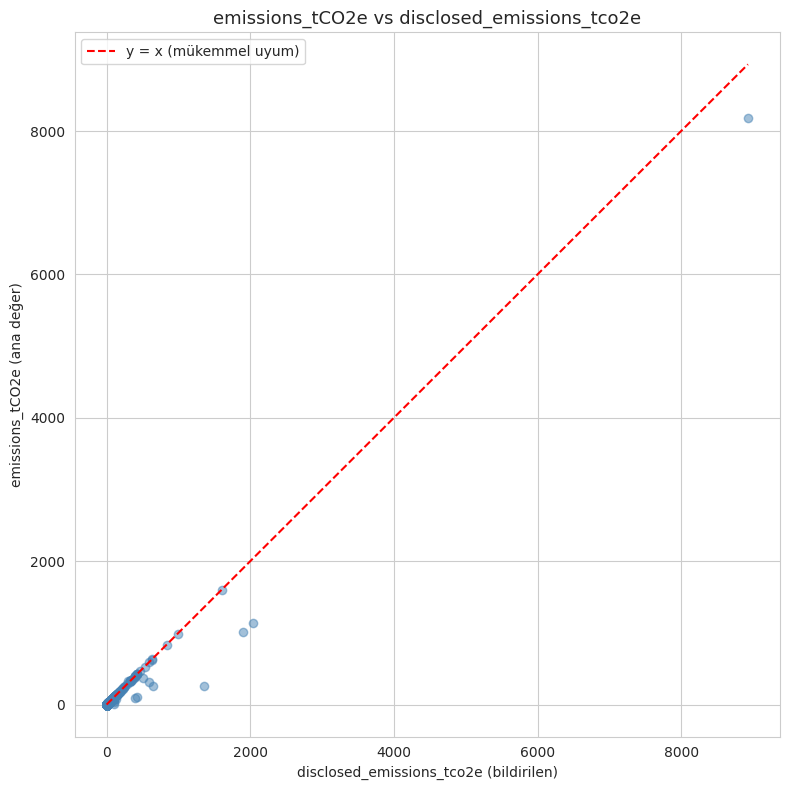

In [32]:
# Scatterplot ile iki değeri karşılaştırma
plt.figure(figsize=(8, 8))
plt.scatter(comparison_df['disclosed_emissions_tco2e'], comparison_df['emissions_tCO2e'],
            alpha=0.5, color='steelblue')

# Referans için y = x doğrusu (mükemmel uyum çizgisi)
max_val = max(comparison_df['disclosed_emissions_tco2e'].max(), comparison_df['emissions_tCO2e'].max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='y = x (mükemmel uyum)')

plt.title('emissions_tCO2e vs disclosed_emissions_tco2e', fontsize=13)
plt.xlabel('disclosed_emissions_tco2e (bildirilen)')
plt.ylabel('emissions_tCO2e (ana değer)')
plt.legend()
plt.tight_layout()
plt.show()


**Çıktıda nelere dikkat etmeliyiz?**
- Noktaların kırmızı `y = x` çizgisine ne kadar yakın olduğu — çizgiye yakın noktalar iki sütunun uyumlu olduğunu gösterir
- `yuzde_fark` sütununda çok yüksek değerler (örneğin %100'ün üzerinde), iki sütun arasında ciddi tutarsızlık olduğunu gösterir
- Çizginin altında/üstünde sistematik bir kayma varsa (örneğin tüm noktalar çizginin altında), bir sütun sistematik olarak diğerinden düşük/yüksek hesaplanıyor olabilir

**Bu analizi neden yaptık?**
> Ana emisyon değerinin bildirilen değerle ne kadar tutarlı olduğunu ölçerek, veri kalitesi hakkında fikir edindik. Bu tutarsızlık ileride hangi sütunun hedef değişken olarak kullanılacağı kararını etkileyebilir.

---


## 17. Elektrik Tüketimi – Emisyon İlişkisi

**Neyi inceliyoruz?**
`disclosed.electricity_used_mwh`, `disclosed.emission_factor_tco2e_per_mwh` ve `disclosed.emissions_tco2e` arasındaki ilişkiyi inceliyoruz. Özellikle `electricity_used_mwh × emission_factor` çarpımının, bildirilen emisyon değeriyle ne kadar uyumlu olduğunu kontrol ediyoruz.

**Neden önemli?**
Teorik olarak emisyon = elektrik tüketimi × emisyon faktörü formülüyle hesaplanır. Bu formülün veri setinde ne kadar tutarlı uygulandığını görmek, verinin güvenilirliğini ve hesaplama yönteminin tutarlılığını anlamamızı sağlar. **Veri temizliği veya düzeltme yapmıyoruz, sadece kontrol ediyoruz.**


In [33]:
# electricity_used_mwh x emission_factor ile disclosed.emissions_tco2e karşılaştırması
check_df = df[['model_id', 'disclosed_electricity_used_mwh',
               'disclosed_emission_factor_tco2e_per_mwh',
               'disclosed_emissions_tco2e']].dropna().copy()

print("Üç sütunun da dolu olduğu kayıt sayısı:", len(check_df))

# Hesaplanan emisyon (geçici, kontrol amaçlı)
check_df['hesaplanan_emisyon'] = (
    check_df['disclosed_electricity_used_mwh'] * check_df['disclosed_emission_factor_tco2e_per_mwh']
)

check_df['fark'] = check_df['hesaplanan_emisyon'] - check_df['disclosed_emissions_tco2e']
check_df['mutlak_yuzde_fark'] = (
    check_df['fark'].abs() / check_df['disclosed_emissions_tco2e'].replace(0, np.nan)
) * 100

check_df[['hesaplanan_emisyon', 'disclosed_emissions_tco2e', 'fark', 'mutlak_yuzde_fark']].describe()


Üç sütunun da dolu olduğu kayıt sayısı: 5146


,hesaplanan_emisyon,disclosed_emissions_tco2e,fark,mutlak_yuzde_fark
count,5.146000e+03,5.146000e+03,5.146000e+03,5.146000e+03
mean,1.261608e+01,1.262356e+01,-7.478333e-03,1.761412e+00
std,1.397025e+02,1.397037e+02,2.571975e-01,1.204691e+02
min,1.400000e-09,1.400000e-09,-1.161000e+01,0.000000e+00
25%,2.000000e-02,2.000000e-02,-1.160096e-17,0.000000e+00
50%,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
75%,3.000000e+00,3.000000e+00,0.000000e+00,2.741291e-14
max,8.930000e+03,8.930000e+03,7.759220e-01,8.640712e+03


In [34]:
# Ne kadarı yaklaşık olarak uyumlu (örneğin %5 tolerans içinde)?
tolerans = 5  # yüzde
uyumlu_sayisi = (check_df['mutlak_yuzde_fark'] <= tolerans).sum()
print(f"%{tolerans} tolerans içinde uyumlu kayıt sayısı: {uyumlu_sayisi} / {len(check_df)}")
print(f"Oran: {round(uyumlu_sayisi / len(check_df) * 100, 2)}%")


%5 tolerans içinde uyumlu kayıt sayısı: 5134 / 5146
Oran: 99.77%


**Çıktıda nelere dikkat etmeliyiz?**
- `mutlak_yuzde_fark` değerlerinin çoğu düşükse (örneğin %5'in altında), bu formülün veri setinde tutarlı şekilde uygulandığını gösterir — bu, verinin güvenilirliği açısından olumlu bir sinyal
- Farkların büyük olduğu kayıtlar varsa, bunlar farklı birim, farklı hesaplama metodolojisi veya veri girişi hatası içeriyor olabilir

**Bu analizi neden yaptık?**
> Beklenen matematiksel ilişkinin (elektrik × faktör = emisyon) veri setinde ne ölçüde geçerli olduğunu kontrol ederek, verinin iç tutarlılığı hakkında fikir edindik.

---


## 18. emissions_tCO2e = 0 Olan Kayıtların Detaylı EDA'sı

**Neyi inceliyoruz?**
`emissions_tCO2e == 0` olan kayıtları ayrı bir DataFrame'de topluyor, bu kayıtlarda diğer önemli sütunların (`training_flops`, `emission_factor_tco2e_per_mwh`, `training_token_count`, `disclosed.emissions_tco2e`, `disclosed.electricity_used_mwh`, `disclosed.emission_factor_tco2e_per_mwh`, `model_region`, `training_gpu_type`, `parameter_values`) doluluk durumunu inceliyoruz.

**Neden önemli?**
Amacımız şu soruya cevap bulmak: **"0 emisyon değerlerinin ne kadarı başka bilgiler kullanılarak daha sonra kurtarılabilir?"** Örneğin bir kayıtta `emissions_tCO2e = 0` ama `disclosed.emissions_tco2e` doluysa, ileride bu bilgiyi kullanarak değeri "kurtarabiliriz" (ama bunu şimdi yapmıyoruz, sadece potansiyeli ölçüyoruz).


## 19. Veri Sızıntısı (Data Leakage) Riski İçin Ön İnceleme

**Neyi inceliyoruz?**
Gelecekte hedef değişkenimiz `emissions_tCO2e` olacak. Bu nedenle hangi sütunların doğrudan veya dolaylı olarak hedef değişkenden türetilmiş olabileceğini değerlendiriyoruz. Özellikle `intensity_tCO2e_per_FLOP` ve `disclosed.emissions_tco2e` sütunlarına odaklanıyoruz.

**Neden önemli?**
Data leakage, modelin gerçekte "öğrenmesi" gerekmeyen ama hedef değişkenle matematiksel/mantıksal olarak bağlantılı bir bilgiyi kullanarak yapay olarak yüksek performans göstermesi anlamına gelir. Bu, gerçek dünyada modelin işe yaramamasına yol açar. **Bu bölümde model kurmuyoruz, sadece riskleri değerlendiriyoruz.**


In [35]:
# intensity_tCO2e_per_FLOP'un emissions_tCO2e ile matematiksel ilişkisini kontrol ediyoruz
# Teorik olarak: intensity = emissions_tCO2e / training_flops olabilir

check_intensity = df[['emissions_tCO2e', 'training_flops', 'intensity_tCO2e_per_FLOP']].dropna().copy()
check_intensity['hesaplanan_intensity'] = (
    check_intensity['emissions_tCO2e'] / check_intensity['training_flops']
)

print("intensity_tCO2e_per_FLOP ile hesaplanan_intensity karşılaştırması:")
print(check_intensity[['intensity_tCO2e_per_FLOP', 'hesaplanan_intensity']].describe())

# Korelasyon (leakage'in gücünü göstermek için)
korelasyon = check_intensity['intensity_tCO2e_per_FLOP'].corr(check_intensity['hesaplanan_intensity'])
print(f"\nintensity_tCO2e_per_FLOP ile hesaplanan_intensity arasındaki korelasyon: {korelasyon:.4f}")


intensity_tCO2e_per_FLOP ile hesaplanan_intensity karşılaştırması:
       intensity_tCO2e_per_FLOP  hesaplanan_intensity
count              5.146000e+03          5.146000e+03
mean               3.724894e-16          3.724894e-16
std                2.424517e-14          2.424517e-14
min                3.424164e-28          3.424164e-28
25%                3.750000e-22          3.750000e-22
50%                2.147093e-21          2.147093e-21
75%                1.335256e-20          1.335256e-20
max                1.737818e-12          1.737818e-12

intensity_tCO2e_per_FLOP ile hesaplanan_intensity arasındaki korelasyon: 1.0000


**Değerlendirme:**

**`intensity_tCO2e_per_FLOP`:**
Bu sütun ismiyle bile ("intensity" = yoğunluk, "per_FLOP" = FLOP başına) hedef değişkenden türetilmiş gibi görünüyor — muhtemelen `emissions_tCO2e / training_flops` formülüyle hesaplanmış. Yukarıdaki karşılaştırma bu iki değerin ne kadar örtüştüğünü gösteriyor. Eğer yüksek korelasyon/örtüşme varsa, bu sütunu **model özelliği (feature) olarak kullanmak ciddi bir data leakage riski taşır** çünkü hedef değişkenin bilgisini dolaylı olarak zaten içeriyor.

**`disclosed.emissions_tco2e`:**
Bu sütun, 16. adımda incelediğimiz gibi ana `emissions_tCO2e` değeriyle çok yakından ilişkili (aynı büyüklüğü farklı bir kaynaktan bildiriyor). Bu sütunu feature olarak kullanmak da leakage riski taşır çünkü pratikte "hedefin kendisinin başka bir versiyonunu" modele feature olarak vermiş oluruz.

**Genel prensip:**
Bir sütun, hedef değişkenin ölçülmesinden *sonra* veya hedef değişkenle *aynı süreçte* ortaya çıkan bir bilgiyse (örneğin hedefin normalize edilmiş hali, hedefin başka bir kaynaktan bildirilen versiyonu), bu sütun modelde kullanılmamalı veya çok dikkatli kullanılmalıdır.

**Bu analizi neden yaptık?**
> İleride Linear Regression ve XGBoost modellerinde kullanılacak feature setini belirlerken, hangi sütunların hedef değişkenle "gizli" bir bağlantısı olduğunu tespit ederek, gerçekçi olmayan (leakage kaynaklı) model performansının önüne geçmeyi amaçladık.

---


## 20. EDA Sonunda Kısa Özet

Aşağıdaki kontrol listesi, notebook'taki tüm kod çıktıları incelendikten sonra doldurulmalıdır. Kod çıktılarını görmeden kesin sonuç üretmiyoruz — bu bölüm, kendi gözlemlerinizi not almanız için bir şablon niteliğindedir.

| Başlık | Gözlemler (çıktıları inceledikten sonra doldurunuz) |
|---|---|
| **Veri setinin genel yapısı** | *(satır/sütun sayısı, veri tipleri hakkında notlar)* |
| **Eksik değer problemi** | *(hangi sütunlarda ne kadar eksik var, en kritik olanlar)* |
| **0 değer problemi** | *(emissions_tCO2e ve diğer sütunlarda 0 oranı, kurtarılabilirlik)* |
| **Aykırı değer problemi** | *(hangi değişkenlerde güçlü outlier riski var)* |
| **Güçlü ilişkiler** | *(korelasyon analizinden çıkan en güçlü ilişkiler)* |
| **Kategorik değişkenlerde önemli farklılıklar** | *(hangi kategoriler emisyonu belirgin şekilde farklılaştırıyor)* |
| **Bölgesel farklılıklar** | *(bölge sütunlarının tutarlılığı, bölgesel emisyon faktörü farkları)* |
| **Data leakage riski** | *(intensity_tCO2e_per_FLOP ve disclosed.emissions_tco2e ile ilgili risk değerlendirmesi)* |
| **Veri ön işleme aşamasında ele almamız gereken konular** | *(bir sonraki aşamada önceliklendirilecek maddeler)* |

**Not:** Bu tabloyu, yukarıdaki tüm kod bloklarının çıktılarını inceledikten sonra kendi gözlemlerinizle doldurmanızı öneririm. İstersen her adımın çıktısını paylaştıkça bu özeti birlikte dolduralım.


#Karbon Emisyonu Projesi — Feature Engineering
Bu notebook, EDA aşamasından sonra gelen feature engineering aşamasını, önceden belirlenmiş 14 feature ile sınırlı kapsamda uygular:

A) Mutlaka oluşturulacak (8 feature): cleaned_emissions_tCO2e, standardized_region, log_training_flops, log_parameters, log_training_tokens, gpu_family, calculated_emissions_tCO2e, calculation_method

B) Projeyi güçlendiren (6 feature): flops_per_parameter, flops_per_token, region_carbon_intensity, low_carbon_region, data_quality_flag, sustainability_score



In [36]:
def is_missing_text(x):
    '''Bir metin hücresinin fiilen eksik/bilinmiyor anlamına gelip gelmediğini kontrol eder.
    Sayısal sütunlarda NaN yok ama metinsel sütunlarda Unknown, N/A (...) gibi placeholder'lar var.'''
    if pd.isna(x):
        return True
    s = str(x).strip().lower()
    if s in {'unknown', 'n/a', 'na', 'none', 'nan', ''}:
        return True
    if s.startswith('n/a'):
        return True
    return False

print('model_region eksik/placeholder sayısı:', df['model_region'].apply(is_missing_text).sum())
print('training_gpu_type eksik/placeholder sayısı:', df['training_gpu_type'].apply(is_missing_text).sum())

model_region eksik/placeholder sayısı: 2127
training_gpu_type eksik/placeholder sayısı: 358


## Feature Engineering Master Tablosu

Aşağıdaki tablo, oluşturulacak 14 feature'ın tamamını literatür bağlantısı, ML kullanılabilirliği ve leakage riskiyle birlikte özetler. Detaylı gerekçeler her feature'ın kendi bölümünde tekrar ele alınacaktır.

| # | Feature | Kullanılan sütunlar | Formül / yöntem | Bilimsel anlamı | Literatür başlığı | ML feature mi? | Direct calc. için mi? | Reporting/sustainability için mi? | Leakage riski | Eksik değer stratejisi | Linear Regression notu | XGBoost notu |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| 1 | `cleaned_emissions_tCO2e` | `emissions_tCO2e`, `disclosed_emissions_tCO2e`, `calculated_emissions_tCO2e` | Öncelik hiyerarşisiyle doğrulama/kurtarma (bkz. bölüm 1) | Nihai, doğrulanmış hedef değişken | CO2 → çevresel maliyet metodolojisi | ✅ **Hedef (y)**, girdi değil | Hayır (bunun kendisi hesaplamanın sonucu) | Evet (raporun ana metriği) | — (hedefin kendisi) | Kurtarılamayan kayıtlar `NaN` bırakılır (ML tahmini gerekir) | y değişkeni, feature değil | y değişkeni, feature değil |
| 2 | `standardized_region` | `model_region`, `disc_region_text`, `disclosed_region` | 3 sütunu önce birleştir, sonra kural-tabanlı normalize et | Lokasyon etkisinin temiz kategorik temsili | Lokasyon etkisi | ✅ Evet (kategorik) | Hayır | Evet | SAFE | `Unknown` olarak korunur, silinmez | One-Hot Encoding | Native categorical / kod (`.cat.codes`) |
| 3 | `log_training_flops` | `training_flops` | `log1p(training_flops)` | Sağa çarpıklığı azaltır, ölçek etkisini normalleştirir | Green Algorithms; BLOOM | ✅ Evet | Hayır | Evet (görselleştirme) | SAFE | Veri setinde eksik yok; genel kural: medyan | LR varsayımlarını (normallik) iyileştirir | Fayda sınırlı (ağaçlar monotonik dönüşümlere duyarsız) ama yine de kullanılabilir |
| 4 | `log_parameters` | `parameter_values` | `log1p(parameter_values)` | Model boyutu ölçek etkisini normalleştirir | Carbon Emissions and Large NN Training | ✅ Evet | Hayır | Evet | SAFE | Aynı yukarıdaki | Aynı yukarıdaki | Aynı yukarıdaki |
| 5 | `log_training_tokens` | `training_token_count` | `log1p(training_token_count)` | Eğitim verisi hacmi ölçek etkisini normalleştirir | Scaling-law literatürü (BLOOM) | ✅ Evet | Hayır | Evet | SAFE | Aynı yukarıdaki | Aynı yukarıdaki | Aynı yukarıdaki |
| 6 | `gpu_family` | `training_gpu_type` | Kural-tabanlı regex → {A100, V100, H100, A800, H800, TPU, Other, Unknown} | Donanım neslinin enerji verimliliği farkını yakalar | Measuring the Carbon Intensity of AI in Cloud Instances | ✅ Evet (kategorik) | Hayır | Evet | SAFE | `Unknown`/`Other` ayrı korunur | One-Hot Encoding | Native categorical |
| 7 | `calculated_emissions_tCO2e` | `disclosed_electricity_used_mwh`, `disclosed_emission_factor_tco2e_per_mwh`, `emission_factor_tco2e_per_mwh` | `enerji × emisyon_faktörü` (öncelik: disclosed faktör → genel faktör) | Fiziksel formülle doğrudan hesaplanan emisyon; çapraz doğrulama aracı | Green Algorithms (direct calculation) | ❌ **Hayır** | ✅ Evet (asıl amacı bu) | Evet (doğrulama raporu) | **LEAKAGE** (hedefle neredeyse birebir — enerji × faktör zaten hedefin formülü) | Enerji bilgisi yoksa `NaN` | Kullanılmaz | Kullanılmaz |
| 8 | `calculation_method` | `emissions_tCO2e`, `disclosed_emissions_tCO2e`, `calculated_emissions_tCO2e` | Karar kuralı (bkz. bölüm 1) | Şeffaflık: değer nasıl elde edildi? | CO2 → çevresel maliyet metodolojisi | ⚠️ CONDITIONAL — dolaylı olarak hedefin nasıl bilindiğini işaret eder, ML'ye **alınmaz** | Hayır | Evet (rapor şeffaflığı için kritik) | CONDITIONAL/LEAKAGE riski (hedeften türetilmiş karar) | Kategori zaten tam | Kullanılmaz | Kullanılmaz |
| 9 | `flops_per_parameter` | `training_flops`, `parameter_values` | `training_flops / parameter_values` | Parametre başına eğitim compute'u — eğitim yoğunluğu göstergesi | Chinchilla-tipi scaling ilişkileri (dolaylı) | ✅ Evet | Hayır | Evet | SAFE | Payda=0 → `NaN` → medyan | Ölçeği geniş, log değerlendirilebilir ama yeni feature üretilmedi | Ölçek sorunu yok (ağaç-tabanlı) |
| 10 | `flops_per_token` | `training_flops`, `training_token_count` | `training_flops / training_token_count` | Token başına compute maliyeti — mimari verimlilik göstergesi | Green AI | ✅ Evet | Hayır | Evet | SAFE | Aynı yukarıdaki | Aynı yukarıdaki | Aynı yukarıdaki |
| 11 | `region_carbon_intensity` | `standardized_region`, `emission_factor_tco2e_per_mwh` | Bölgeye göre ortalama emisyon faktörü | `emission_factor_tco2e_per_mwh`'ın standardize edilmiş bölgesel temsili (**yeni bir fiziksel ölçüm DEĞİL**) | Carbon Intensity metodolojisi | ✅ Evet — **ancak** ham `emission_factor_tco2e_per_mwh` ile birlikte kullanılmamalı (multicollinearity) | Hayır | Evet | SAFE (ama ham faktörle birlikte kullanılırsa redundancy riski) | Bölge `Unknown` ise global ortalama | Sadece bunu veya ham faktörü kullan, ikisini birden değil | Aynı öneri geçerli |
| 12 | `low_carbon_region` | `region_carbon_intensity` | İkili gösterge: `region_carbon_intensity <= medyan` | "Düşük karbonlu bölge mi?" göstergesi | Lokasyon etkisi | ✅ Evet | Hayır | Evet | SAFE | Bölge bilinmiyorsa 0 (temkinli varsayım) | Basit ikili değişken, sorunsuz | Basit ikili değişken, sorunsuz |
| 13 | `data_quality_flag` | `calculation_method`, `standardized_region`, `emission_factor_tco2e_per_mwh` | Kural-tabanlı sınıflama: high/medium/low | Kaydın güvenilirlik seviyesi | Çevresel maliyetin tanımı (şeffaflık ilkesi) | ⚠️ CONDITIONAL — hedefin nasıl elde edildiğine bağlı, ML'ye **alınmaz** | Hayır | Evet (kritik rapor bileşeni) | CONDITIONAL/LEAKAGE riski | Kategori zaten tam | Kullanılmaz | Kullanılmaz |
| 14 | `sustainability_score` | `cleaned_emissions_tCO2e`, `flops_per_parameter`, `flops_per_token`, `region_carbon_intensity` | Percentile-rank tabanlı ağırlıklı kompozit (bkz. bölüm 8) | Kullanıcıya sunulan nihai sürdürülebilirlik özeti (**kendi tasarımımız**) | Sustainability Score metodolojisi (literatürde hazır formül yok) | ❌ **Hayır** | Hayır | ✅ Evet (asıl amacı bu) | **LEAKAGE** (`cleaned_emissions_tCO2e`'den doğrudan türetilmiş) | Bileşenlerden biri eksikse skor `NaN` | Kullanılmaz | Kullanılmaz |

**Önemli uyarı — `disclosed_electricity_used_mwh` için iki senaryo:**
- **(A) Tahmin anında elektrik tüketimi biliniyorsa:** Zaten `direct_calculation` yoluna girilir (bkz. `calculated_emissions_tCO2e`), ML tahminine hiç gerek yoktur.
- **(B) Elektrik tüketimi bilinmiyorsa:** Bu sütun ML tahmin probleminde **girdi olarak kullanılamaz**, çünkü tahmin anında zaten mevcut olmayacaktır (gerçek dünyada, bu sütunun dolu olduğu her kayıt zaten direct calculation'a gider — ML'nin göreceği alt küme sistematik olarak bu sütunun boş olduğu kayıtlardır).

Bu nedenle `disclosed_electricity_used_mwh` ML feature listesine **hiçbir koşulda girmez**.


## Bölüm 1 — Hedef Değişken Zinciri: `calculated_emissions_tCO2e` → `cleaned_emissions_tCO2e` → `calculation_method`

Bu üç feature birbirine sıkı bağlı olduğu için birlikte ele alıyoruz.

### 1.1 `calculated_emissions_tCO2e` — Direct Calculation

**Öncelik kuralı:**
1. `disclosed_electricity_used_mwh` mevcut değilse → hesaplanamaz (`NaN`).
2. `disclosed_electricity_used_mwh` mevcutsa ve `disclosed_emission_factor_tco2e_per_mwh` de mevcutsa → `enerji × disclosed_faktör` (en güvenilir: her ikisi de aynı kaynaktan bildirilmiş).
3. `disclosed_electricity_used_mwh` mevcut ama `disclosed_emission_factor_tco2e_per_mwh` mevcut değilse → `enerji × genel emission_factor_tco2e_per_mwh` (bölgesel/genel şebeke faktörüyle fallback).

**Bu feature ML modeline KESİNLİKLE girmez** — çünkü zaten `emisyon = enerji × faktör` formülünün ta kendisidir; hedefle olan ilişkisi istatistiksel değil, cebirseldir.

### 1.2 `cleaned_emissions_tCO2e` — Nihai Hedef Değişken

`emissions_tCO2e = 0` olan 80 kaydı **otomatik "eksik" saymadan**, aşağıdaki öncelik sırasıyla doğruluyor/kurtarıyoruz:

1. Orijinal `emissions_tCO2e ≠ 0` ise → doğrudan kullan (`reported`).
2. `emissions_tCO2e = 0` ama `disclosed_emissions_tCO2e > 0` ise → oradan kurtar (`recovered_from_disclosed`).
3. Yukarıdakiler yoksa ama `calculated_emissions_tCO2e` hesaplanabiliyorsa → onu kullan (`direct_calculation`).
4. Bağımsız kaynaklar da (disclosed emisyon) 0/eksikse ve compute bilgisi (`training_flops`) mevcutsa → bu **doğrulanmış bir sıfıra yakın değer** kabul edilir (`validated_zero`) — silinmez.
5. Hiçbiri mevcut değilse → `NaN` bırakılır, bu kayıtlar bir sonraki notebook'ta **ML tahminine** ihtiyaç duyacaktır (`ml_estimated`).

**Orijinal `emissions_tCO2e` sütunu asla değiştirilmiyor** — `cleaned_emissions_tCO2e` tamamen yeni bir sütun.

### 1.3 `calculation_method` — Şeffaflık Etiketi

Her kaydın `cleaned_emissions_tCO2e` değerinin **hangi yöntemle** elde edildiğini gösteren kategorik sütun: `reported`, `recovered_from_disclosed`, `direct_calculation`, `validated_zero`, `ml_estimated`.

**Neden nihai kullanıcı raporunda önemli?** Bir kullanıcı "Model X'in karbon ayak izi 12.4 tCO2e" dediğimizde, bunun **ölçülmüş bir gerçek mi yoksa modelin tahmini mi** olduğunu bilmek güven açısından kritiktir. Bu sütun olmadan, doğrudan bildirilen bir değer ile ML'nin tahmin ettiği bir değer kullanıcıya aynı kesinlikte sunulmuş olur — bu yanıltıcıdır.

**`validated_zero` neden ayrı bir kategori (gereksiz kategori üretmiyoruz, gerekçesi var):** Bu 80 kayıt, hem `emissions_tCO2e` hem `disclosed_emissions_tCO2e` hem `disclosed_electricity_used_mwh` bağımsız olarak 0 olduğu için "eksik veri" ile "gerçekten sıfıra yakın model" (örn. küçük LoRA/ControlNet adaptörleri) arasındaki farkı ayırt etmek bilimsel olarak gereklidir; bunları `ml_estimated` ile aynı kovaya koymak yanlış bir belirsizlik sinyali verir.


In [37]:
# --- 1.1 calculated_emissions_tCO2e ---
def calculate_emissions(row):
    kwh = row['disclosed_electricity_used_mwh']
    if pd.isna(kwh) or kwh <= 0:
        return np.nan
    if pd.notna(row['disclosed_emission_factor_tco2e_per_mwh']) and row['disclosed_emission_factor_tco2e_per_mwh'] > 0:
        return kwh * row['disclosed_emission_factor_tco2e_per_mwh']
    if pd.notna(row['emission_factor_tco2e_per_mwh']) and row['emission_factor_tco2e_per_mwh'] > 0:
        return kwh * row['emission_factor_tco2e_per_mwh']
    return np.nan

df['calculated_emissions_tCO2e'] = df.apply(calculate_emissions, axis=1)

print('calculated_emissions_tCO2e - eksik (hesaplanamayan) kayıt sayısı:', df['calculated_emissions_tCO2e'].isna().sum())
print(df['calculated_emissions_tCO2e'].describe())

calculated_emissions_tCO2e - eksik (hesaplanamayan) kayıt sayısı: 0
count    5.146000e+03
mean     1.261608e+01
std      1.397025e+02
min      1.400000e-09
25%      2.000000e-02
50%      1.000000e+00
75%      3.000000e+00
max      8.930000e+03
Name: calculated_emissions_tCO2e, dtype: float64


In [38]:
# --- 1.2 & 1.3: cleaned_emissions_tCO2e ve calculation_method birlikte üretiliyor ---
def clean_emissions_and_method(row):
    # 1) Orijinal değer zaten doluysa
    if row['emissions_tCO2e'] != 0:
        return pd.Series([row['emissions_tCO2e'], 'reported'])

    # 2) Bağımsız bildirilen emisyondan kurtarma
    disc_em = row['disclosed_emissions_tco2e']
    if pd.notna(disc_em) and disc_em > 0:
        return pd.Series([disc_em, 'recovered_from_disclosed'])

    # 3) Direct calculation ile kurtarma
    calc_em = row['calculated_emissions_tCO2e']
    if pd.notna(calc_em) and calc_em > 0:
        return pd.Series([calc_em, 'direct_calculation'])

    # 4) Bağımsız kaynaklar da 0/eksikse ve compute bilgisi mevcutsa: doğrulanmış sıfıra yakın değer
    compute_available = pd.notna(row['training_flops']) and row['training_flops'] > 0
    disclosed_also_zero_or_missing = pd.isna(disc_em) or disc_em == 0
    if compute_available and disclosed_also_zero_or_missing:
        return pd.Series([0.0, 'validated_zero'])

    # 5) Hiçbir kaynak yok: ML tahminine ihtiyaç var
    return pd.Series([np.nan, 'ml_estimated'])

result = df.apply(clean_emissions_and_method, axis=1)
df['cleaned_emissions_tCO2e'] = result[0]
df['calculation_method'] = result[1]

print('calculation_method dağılımı:')
print(df['calculation_method'].value_counts())
print()
print('cleaned_emissions_tCO2e eksik (ml_estimated bekleyen) kayıt sayısı:', df['cleaned_emissions_tCO2e'].isna().sum())
print()
print('Doğrulama: calculated_emissions_tCO2e ile disclosed_emissions_tco2e ne kadar uyumlu? (yalnızca ikisi de dolu olan kayıtlarda)')
both_available = df[['calculated_emissions_tCO2e', 'disclosed_emissions_tco2e']].dropna()
corr = both_available['calculated_emissions_tCO2e'].corr(both_available['disclosed_emissions_tco2e'])
print(f'Korelasyon: {corr:.4f}  (n={len(both_available)})')

calculation_method dağılımı:
calculation_method
reported    5146
Name: count, dtype: int64

cleaned_emissions_tCO2e eksik (ml_estimated bekleyen) kayıt sayısı: 0

Doğrulama: calculated_emissions_tCO2e ile disclosed_emissions_tco2e ne kadar uyumlu? (yalnızca ikisi de dolu olan kayıtlarda)
Korelasyon: 1.0000  (n=5146)


## Bölüm 2 — `standardized_region`

**Mapping metodolojisi (önce açıklama, sonra kod):**

1. **Kaynak önceliği:** `disclosed_region` → `disc_region_text` → `model_region` sırasıyla, hangisi doluysa (placeholder değilse) o kullanılır. Bu, en "resmi/bildirilmiş" kaynağa öncelik verir.
2. **Takma ad birleştirme:** `USA`/`US`/`United States` → `United States`; `UK`/`United Kingdom` → `United Kingdom`; `Turkey`/`Türkiye` → `Turkey`; `Vietnam`/`Viet Nam` → `Vietnam`; `UAE`/`United Arab Emirates` → `United Arab Emirates`.
3. **Çoklu bölge ifadeleri** (`"China/USA"`, `"France/USA"` gibi `/` veya `and`/`or` içerenler) → tek bir ülkeye **zorla atanmaz**, `Multi-Region / Belirsiz` olarak işaretlenir (yanlış sınıflandırmayı önlemek için).
4. **Konsorsiyum/tesis açıklamaları** (`"International (BigScience...)"`, `"LUMI supercomputer, Finland"` gibi) → `International / Multi-Institution` olarak gruplanır — bunlar tek bir ülkeye ait değildir.
5. Geri kalan serbest metinler, içinde geçen bilinen bir ülke adına göre eşlenir.
6. `Unknown` değerleri **silinmez**, ayrı bir kategori olarak korunur.

**Ayrıntı seviyesi karışıklığına dikkat:** `"West US 2"` (Azure bulut bölgesi), `"Phoenix, AZ"` (şehir) ve `"United States"` (ülke) farklı ayrıntı seviyelerindedir. Bu üçünü de `United States` altında topluyoruz çünkü hepsi aynı ülkeye işaret ediyor — ancak bunu **yanlışlıkla farklı ülkeleri birleştirme** ile karıştırmamak gerekir (örn. `"Montreal"` şehir adı tek başına bir ülkeye kesin atanamayacağı için — bizim listemizde doğrudan eşleşmediği için — `Diğer / Sınıflandırılamadı` kategorisine düşer; bu şeffaf ve kabul edilebilir bir sınırlamadır).


In [39]:
import re

REGION_ALIASES = [
    (r'\b(usa|us|united states)\b', 'United States'),
    (r'\b(uk|united kingdom)\b', 'United Kingdom'),
    (r'\b(turkiye|türkiye|turkey)\b', 'Turkey'),
    (r'\b(viet nam|vietnam)\b', 'Vietnam'),
    (r'\buae\b', 'United Arab Emirates'),
    (r'\bunited arab emirates\b', 'United Arab Emirates'),
]

COUNTRY_LIST = [
    'China', 'France', 'Germany', 'Finland', 'Australia', 'Japan', 'Canada', 'Russia',
    'Singapore', 'India', 'Israel', 'Ireland', 'Spain', 'Thailand', 'Italy', 'Switzerland',
    'Poland', 'South Korea', 'Sweden', 'Norway', 'Netherlands', 'Denmark', 'Belgium',
    'Portugal', 'Romania', 'Hungary', 'Czech Republic', 'Croatia', 'Ukraine', 'Egypt',
    'Qatar', 'Saudi Arabia', 'Malaysia', 'Indonesia', 'Bangladesh', 'Nepal', 'Kazakhstan',
    'Iran', 'Tunisia', 'Albania', 'Argentina', 'Brazil', 'Chile', 'Mexico', 'Hong Kong',
    'Taiwan',
]

def is_missing_region_value(x):
    if pd.isna(x):
        return True
    s = str(x).strip().lower()
    return s in ('unknown', 'n/a', 'na', 'none', '')

def normalize_region_text(raw):
    s = str(raw).strip()
    low = s.lower()
    if '/' in s or ' and ' in low or ' or ' in low:
        return 'Multi-Region / Belirsiz'
    for pattern, canonical in REGION_ALIASES:
        if re.search(pattern, low):
            return canonical
    for country in COUNTRY_LIST:
        if country.lower() in low:
            return country
    if 'international' in low or 'lumi' in low or 'consortium' in low:
        return 'International / Multi-Institution'
    return 'Diger / Siniflandirilamadi'

def combine_and_standardize_region(row):
    for col in ['disclosed_region', 'disc_region_text', 'model_region']:
        val = row[col]
        if not is_missing_region_value(val):
            return normalize_region_text(val)
    return 'Unknown'

df['standardized_region'] = df.apply(combine_and_standardize_region, axis=1)

print('standardized_region dağılımı (ilk 20):')
print(df['standardized_region'].value_counts().head(20))
print()
n_unclassified = (df['standardized_region'] == 'Diger / Siniflandirilamadi').sum()
print(f"'Diğer / Sınıflandırılamadı' kayıt sayısı: {n_unclassified} ({n_unclassified/len(df)*100:.2f}%)")

standardized_region dağılımı (ilk 20):
standardized_region
Unknown                 2126
United States           1630
China                    621
France                   104
Germany                  100
South Korea               89
Finland                   67
United Kingdom            43
Japan                     43
Canada                    37
United Arab Emirates      28
Singapore                 26
India                     21
Vietnam                   18
Ireland                   16
Spain                     14
Israel                    14
Italy                     13
Thailand                  13
Poland                    11
Name: count, dtype: int64

'Diğer / Sınıflandırılamadı' kayıt sayısı: 5 (0.10%)


## Bölüm 3-5 — Log Dönüşümleri: `log_training_flops`, `log_parameters`, `log_training_tokens`

**Neden log dönüşümü?** EDA'da `training_flops`, `parameter_values` ve `training_token_count` değişkenlerinin ciddi şekilde sağa çarpık olduğunu ve birkaç büyüklük mertebesi (order of magnitude) fark içerdiğini gördük (örn. en küçük model milyonlarca parametre, en büyük model yüzlerce milyar parametre). `log1p(x) = log(1+x)` dönüşümü:
- Büyük değerlerin dağılım üzerindeki baskın etkisini azaltır,
- Çarpımsal (multiplicative) ilişkileri toplamsal (additive) hale getirir — bu, doğrusal modellerin varsayımlarıyla daha uyumludur,
- `x=0` durumunda tanımsızlık oluşmaz (`log(0)` yerine `log1p(0)=0`).

**Orijinal sütunlar silinmiyor** — `log_training_flops`, `log_parameters`, `log_training_tokens` tamamen yeni sütunlar olarak ekleniyor.

**Linear Regression açısından:** Log dönüşüm, doğrusal modelin temel varsayımlarından olan "hata terimlerinin yaklaşık normal dağılması" ve "değişkenler ile hedef arasında yaklaşık doğrusal ilişki" varsayımlarını güçlendirir. Log-dönüştürülmemiş ham `training_flops` ile bir doğrusal model kurulursa, birkaç aşırı büyük model tüm regresyon katsayılarını domine edebilir.

**XGBoost açısından:** Ağaç-tabanlı modeller **monotonik dönüşümlere karşı duyarsızdır** (bir değişkenin sıralamasını koruyan herhangi bir dönüşüm, ağacın bölme noktalarını sonuçta aynı şekilde bulmasını sağlar). Bu nedenle log dönüşümün XGBoost performansına katkısı teorik olarak sınırlıdır — ancak yine de (a) sayısal kararlılık (çok büyük sayılarla çalışırken hassasiyet kaybını azaltır) ve (b) yorumlanabilirlik (feature importance/SHAP çıktılarının daha anlamlı ölçeklerde olması) açısından faydalıdır.


In [40]:
df['log_training_flops'] = np.log1p(df['training_flops'])
df['log_parameters'] = np.log1p(df['parameter_values'])
df['log_training_tokens'] = np.log1p(df['training_token_count'])

print(df[['training_flops', 'log_training_flops',
          'parameter_values', 'log_parameters',
          'training_token_count', 'log_training_tokens']].describe())
print()
print('Eksik değer kontrolü:')
print(df[['log_training_flops', 'log_parameters', 'log_training_tokens']].isna().sum())
print()
print('Inf kontrolü:')
print(np.isinf(df[['log_training_flops', 'log_parameters', 'log_training_tokens']]).sum())

       training_flops  log_training_flops  parameter_values  log_parameters  \
count    5.146000e+03         5146.000000      5.146000e+03     5146.000000   
mean     1.351193e+23           46.604478      4.576990e+09       20.500471   
std      1.149715e+24            5.427451      1.629429e+10        1.999501   
min      7.621000e+00            2.154201      5.760000e+03        8.658866   
25%      9.682560e+18           43.716858      3.450000e+08       19.659055   
50%      2.400000e+20           46.927171      5.000000e+08       20.030119   
75%      1.200000e+22           50.839194      4.500000e+09       22.227343   
max      5.076000e+25           59.189151      4.800000e+11       26.897052   

       training_token_count  log_training_tokens  
count          5.146000e+03          5146.000000  
mean           2.665424e+12            25.696880  
std            4.210514e+13             2.726896  
min            5.749000e+03             8.656955  
25%            3.000000e+10      

## Bölüm 6 — `gpu_family`

`training_gpu_type` sütununda 195 farklı benzersiz metin var; örneğin `"NVIDIA H100-80GB"`, `"NVIDIA H100 80GB"`, `"H100 SXM"`, `"NVIDIA Hopper-series (HGX H20, H800, H100)"` gibi ifadelerin çoğu aynı donanım ailesini işaret ediyor.

**Ana GPU aileleri (kullanıcının belirttiği gibi):** `A100`, `V100`, `H100`, `A800` — bunlara ek olarak veri setinde ayrı bir ihracat-kısıtlı varyant olan `H800`'ü de A800 mantığıyla tutarlı biçimde ayrı bir aile olarak tutuyoruz (A100↔A800 ayrımıyla aynı gerekçe: farklı çip/performans profili). `TPU` de donanım tipi olarak (`training_hardware_type='TPU'` ile örtüşen) ayrı bir aile.

**Düşük frekanslı GPU isimleri için gruplama stratejisi:** T4, P100, RTX serisi, L40S, AMD MI serisi gibi onlarca farklı GPU tipi tek tek çok düşük frekanslarla (çoğu ≤5 kayıt) görünüyor. Bunları ayrı ayrı kategori yapmak (a) one-hot encoding'de gereksiz sütun patlamasına yol açar, (b) her kategoride o kadar az örnek kalır ki model bu kategorilerden hiçbir şey öğrenemez. Bu nedenle ana 6 aileye (A100/V100/H100/A800/H800/TPU) girmeyen **her şeyi** tek bir `Other` kategorisinde topluyoruz. Bu, "gerçekten bilinmiyor" (`Unknown`) durumundan **kasıtlı olarak ayrı** tutuluyor — `Unknown`, GPU bilgisinin hiç mevcut olmadığı kayıtları; `Other`, GPU bilgisi mevcut ama ana ailelerden birine girmeyen (nadir görülen) donanımları temsil ediyor.

**`Unknown` / `Other` kategorileri korunuyor, silinmiyor.**


In [41]:
MAIN_GPU_PATTERNS = [
    (r'h800', 'H800'),
    (r'h100', 'H100'),
    (r'a800', 'A800'),
    (r'a100', 'A100'),
    (r'v100', 'V100'),
    (r'tpu', 'TPU'),
]

def extract_gpu_family(raw):
    if pd.isna(raw):
        return 'Unknown'
    s = str(raw).strip().lower()
    if s in ('unknown', 'n/a', 'na', 'none', '', 'gpu') or s.startswith('n/a'):
        return 'Unknown'
    for pattern, family in MAIN_GPU_PATTERNS:
        if re.search(pattern, s):
            return family
    return 'Other'

df['gpu_family'] = df['training_gpu_type'].apply(extract_gpu_family)

print('gpu_family dağılımı:')
print(df['gpu_family'].value_counts())
print()
other_ratio = (df['gpu_family'] == 'Other').mean()
print(f"'Other' oranı: {other_ratio*100:.2f}%  (ana 6 aileye girmeyen donanım isimleri)")


gpu_family dağılımı:
gpu_family
A100       2240
V100       2072
Unknown     358
H100        215
Other       167
A800         60
H800         34
Name: count, dtype: int64

'Other' oranı: 3.25%  (ana 6 aileye girmeyen donanım isimleri)


## Bölüm 9-10 — `flops_per_parameter`, `flops_per_token`

### `flops_per_parameter = training_flops / parameter_values`
**Bilimsel anlamı:** Bir modelin **parametre başına ne kadar compute harcandığını** gösterir — yani modelin ne kadar "yoğun" eğitildiğini (kaç epoch/token ile, ne kadar tekrar eğitim yapıldığını) dolaylı olarak yansıtır. Chinchilla-tipi scaling-law literatüründe, sabit bir parametre sayısı için farklı miktarda compute harcanabileceği (az veri/kısa eğitim vs. çok veri/uzun eğitim) tartışılır; bu oran o dengeyi özetler.

### `flops_per_token = training_flops / training_token_count`
**Bilimsel anlamı:** **Token başına harcanan compute**'u gösterir — model mimarisinin (katman sayısı, dikkat mekanizması karmaşıklığı vb.) verimliliğinin dolaylı bir göstergesidir. Green AI makalesinin vurguladığı "aynı işi daha az kaynakla yapabilme" (verimlilik) fikrini somutlaştırır: iki model aynı miktarda token işlese bile, biri diğerinden çok daha fazla FLOP harcıyorsa, o model mimari olarak daha az verimlidir.

**Log versiyonuna ihtiyaç var mı?** Değerlendiriyoruz ama **yeni bir feature üretmiyoruz** — bu oranlar zaten iki log-normal benzeri dağılımın bölümü olduğu için görece daha az çarpık olabilir, ancak yine de sağa çarpıklık gösterebilirler. Bu değerlendirmeyi Bölüm 11'deki (validasyon) skewness kontrolünde sayısal olarak yapacağız; eğer ciddi çarpıklık tespit edilirse, **modelleme notebook'unda** (bu notebook'ta değil) log dönüşümü uygulama kararı model bazında (özellikle Linear Regression için) alınabilir.

**Sıfıra bölme kontrolü:** `parameter_values` veya `training_token_count` sütunlarında 0 değer varsa, bölüm işlemi `inf` üretir. Bu veri setinde her iki sütun için de 0 gözlenmemiştir, ancak genel/gerçek dünya kullanımı için güvenlik amacıyla 0'ları `NaN`'a çevirip medyan ile dolduran bir kontrol ekliyoruz.


In [42]:
safe_parameter_values = df['parameter_values'].replace(0, np.nan)
safe_token_count = df['training_token_count'].replace(0, np.nan)

df['flops_per_parameter'] = df['training_flops'] / safe_parameter_values
df['flops_per_token'] = df['training_flops'] / safe_token_count

for col in ['flops_per_parameter', 'flops_per_token']:
    n_missing = df[col].isna().sum()
    n_inf = np.isinf(df[col]).sum()
    if n_missing > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f'{col}: {n_missing} eksik değer medyan ({median_val:.4g}) ile dolduruldu.')
    else:
        print(f'{col}: eksik değer yok.')
    print(f'{col}: inf sayısı = {n_inf}')

print()
print(df[['flops_per_parameter', 'flops_per_token']].describe())


flops_per_parameter: eksik değer yok.
flops_per_parameter: inf sayısı = 0
flops_per_token: eksik değer yok.
flops_per_token: inf sayısı = 0

       flops_per_parameter  flops_per_token
count         5.146000e+03     5.146000e+03
mean          3.539035e+13     2.612393e+13
std           6.561848e+14     1.492639e+15
min           1.172462e-08     1.215730e-10
25%           3.506419e+10     4.218750e+08
50%           4.824000e+11     2.370000e+09
75%           5.792505e+12     1.814529e+10
max           2.271982e+16     1.067077e+17


## Bölüm 11-12 — `region_carbon_intensity`, `low_carbon_region`

### `region_carbon_intensity`

**Bu yeni bir fiziksel ölçüm müdür?** **Hayır.** Bu, mevcut `emission_factor_tco2e_per_mwh` sütununun, `standardized_region` bazında ortalaması alınarak **standardize edilmiş bölgesel temsilidir**. Yeni bir ölçüm değil, var olan bilginin gürültüsünü azaltıp (aynı bölgedeki farklı kayıtların küçük ölçüm farklarını ortalayarak) bölge bazında tekilleştirilmiş halidir.

**Multicollinearity uyarısı:** `region_carbon_intensity`, ham `emission_factor_tco2e_per_mwh` ile **çok yüksek korelasyonludur** (aynı bilginin bölge-ortalamalı versiyonu). İkisini birlikte ML modeline sokmak aynı bilgiyi iki kez saymak anlamına gelir ve özellikle Linear Regression'da çoklu doğrusal bağlantı (multicollinearity) sorununa yol açar. **Öneri: ML feature setinde yalnızca `region_carbon_intensity` kullanılmalı, ham `emission_factor_tco2e_per_mwh` ML girdisi olarak kullanılmamalıdır** (çünkü `region_carbon_intensity`, `standardized_region` ile birlikte daha temiz/gürültüsüz bir temsil sunar).

### `low_carbon_region`

**Eşik seçimi:** Literatürde (6 makalemiz arasında) evrensel kabul görmüş sabit bir "düşük karbon" eşiği (örn. "X tCO2e/MWh altı düşük karbondur" gibi) bulunmuyor — böyle bir eşiği literatüre aitmiş gibi sunmuyoruz. Bu nedenle **veri dağılımına dayalı** bir yaklaşım seçiyoruz:

| Yöntem | Değerlendirme |
|---|---|
| Literatür-temelli sabit eşik | ❌ Kullanılamaz — 6 makalemizde bu projeye özgü bir eşik tanımlanmamış |
| Ortalama (mean) temelli | ❌ Uygun değil — `emission_factor` dağılımı çarpık olduğundan ortalama uç değerlerden etkilenir |
| **Medyan (50. persentil) temelli** ✅ **(seçilen)** | Veri setindeki bölgesel dağılımın tam ortası; outlier'lara ortalamadan daha dayanıklı; sonucu basit ve yorumlanabilir ("bu bölge, veri setindeki bölgelerin daha temiz yarısında mı?") |
| Alt çeyreklik (33./25. persentil) | ⚠️ Alternatif bir seçenek olabilir ama medyan kadar basit/simetrik yorumlanamaz; keyfi bir yüzde seçimi gerektirir |

Medyanı tercih etme gerekçemiz: hem outlier'lara dayanıklı olması hem de "alt %25/%33" gibi ek bir keyfi yüzde parametresi seçmeye gerek bırakmaması.

**Not (şeffaflık için):** Medyan hesaplaması **kayıt (satır) düzeyinde** yapılıyor; yani büyük kayıt sayısına sahip bölgeler (örn. `United States`, `Unknown`) dağılımı daha fazla etkiliyor. Bu, "veri setindeki tipik bir kaydın hangi tarafta olduğu" sorusuna cevap verir — "kaç farklı ülke düşük karbonlu" sorusuna değil. Bu ayrımı bilinçli olarak yapıyoruz çünkü projenin amacı model bazlı raporlama, ülke sayımı değil.


In [43]:
df['region_carbon_intensity'] = df.groupby('standardized_region')['emission_factor_tco2e_per_mwh'].transform('mean')

median_carbon_intensity = df['region_carbon_intensity'].median()
df['low_carbon_region'] = (df['region_carbon_intensity'] <= median_carbon_intensity).astype(int)

print(f'Medyan bölgesel carbon intensity (eşik değeri): {median_carbon_intensity:.4f} tCO2e/MWh')
print()
print('low_carbon_region dağılımı:')
print(df['low_carbon_region'].value_counts())
print()
print('Bölgeye göre ortalama carbon intensity (en düşük 5 / en yüksek 5):')
region_avg = df.groupby('standardized_region')['emission_factor_tco2e_per_mwh'].mean().sort_values()
print(region_avg.head(5))
print('...')
print(region_avg.tail(5))
print()
print('Ham emission_factor_tco2e_per_mwh ile region_carbon_intensity arasındaki korelasyon (multicollinearity kanıtı):')
print(f"{df['emission_factor_tco2e_per_mwh'].corr(df['region_carbon_intensity']):.4f}")

Medyan bölgesel carbon intensity (eşik değeri): 0.4448 tCO2e/MWh

low_carbon_region dağılımı:
low_carbon_region
1    4319
0     827
Name: count, dtype: int64

Bölgeye göre ortalama carbon intensity (en düşük 5 / en yüksek 5):
standardized_region
Albania        0.025000
Sweden         0.035824
Switzerland    0.036599
Nepal          0.042000
France         0.063449
Name: emission_factor_tco2e_per_mwh, dtype: float64
...
standardized_region
Poland        0.614982
Taiwan        0.635651
Bangladesh    0.694625
India         0.708322
Kazakhstan    0.801948
Name: emission_factor_tco2e_per_mwh, dtype: float64

Ham emission_factor_tco2e_per_mwh ile region_carbon_intensity arasındaki korelasyon (multicollinearity kanıtı):
0.9653


## Bölüm 13 — `data_quality_flag`

Her kaydın **güvenilirlik seviyesini** gösteren basit, kural-tabanlı bir sınıflama (**keyfi puanlama YOK** — açık kurallar):

**Değerlendirilen kriterler:**
- `disclosed_emissions_tco2e` mevcut mu? (bağımsız doğrulama var mı?)
- `calculation_method` nedir? (`reported` / `recovered_from_disclosed` / `direct_calculation` / `validated_zero` / `ml_estimated`)
- `standardized_region` biliniyor mu? (`Unknown`, `Diğer / Sınıflandırılamadı`, `Multi-Region / Belirsiz` değilse "biliniyor" kabul edilir)
- `emission_factor_tco2e_per_mwh` mevcut mu?

**Kural tablosu:**

| Koşul | `data_quality_flag` |
|---|---|
| `calculation_method == 'reported'` **VE** bölge biliniyor **VE** emisyon faktörü mevcut | `high` |
| `calculation_method == 'reported'` **AMA** bölge bilinmiyor | `medium` |
| `calculation_method` ∈ {`recovered_from_disclosed`, `direct_calculation`} | `medium` (değer türetilmiş/kurtarılmış, ama güvenilir bir kaynaktan) |
| `calculation_method == 'validated_zero'` | `medium` (doğrulanmış ama çok sınırlı bilgiye dayanıyor) |
| `calculation_method == 'ml_estimated'` **VEYA** bölge bilinmiyor (diğer tüm durumlar) | `low` |

Bu kurallar, "değer ne kadar doğrudan/bağımsız kaynaktan geliyor" ve "eşlik eden metadata (bölge, emisyon faktörü) ne kadar tam" sorularını birleştirir.

**Bu feature ML'ye neden girmiyor?** `data_quality_flag`, `calculation_method` üzerinden **dolaylı olarak** hedefin nasıl elde edildiği bilgisini taşır — bu, `calculation_method` ile aynı CONDITIONAL/LEAKAGE riskini taşır. Yalnızca **raporlama** amaçlıdır.


In [44]:
def assign_data_quality_flag(row):
    method = row['calculation_method']
    region_known = row['standardized_region'] not in (
        'Unknown', 'Diger / Siniflandirilamadi', 'Multi-Region / Belirsiz'
    )
    factor_known = pd.notna(row['emission_factor_tco2e_per_mwh']) and row['emission_factor_tco2e_per_mwh'] > 0

    if method == 'reported' and region_known and factor_known:
        return 'high'
    if method == 'reported' and not region_known:
        return 'medium'
    if method in ('recovered_from_disclosed', 'direct_calculation'):
        return 'medium'
    if method == 'validated_zero':
        return 'medium'
    if method == 'ml_estimated' or not region_known:
        return 'low'
    return 'low'

df['data_quality_flag'] = df.apply(assign_data_quality_flag, axis=1)

print('data_quality_flag dağılımı:')
print(df['data_quality_flag'].value_counts())
print()
print('calculation_method x data_quality_flag çapraz tablo:')
print(pd.crosstab(df['calculation_method'], df['data_quality_flag']))

data_quality_flag dağılımı:
data_quality_flag
high      3014
medium    2132
Name: count, dtype: int64

calculation_method x data_quality_flag çapraz tablo:
data_quality_flag   high  medium
calculation_method              
reported            3014    2132


## Bölüm 14 — `sustainability_score`

**⚠️ AÇIK BEYAN:** Kullandığımız 6 literatür kaynağının hiçbirinde hazır, standart bir "Sustainability Score" formülü **bulunmamaktadır**. Aşağıdaki composite score **tamamen bizim tasarımımızdır**; literatürden alınmış bir formül değildir.

### Double-counting sorunu ve çözümü

Görev tanımında açıkça uyarıldığı gibi: **`emissions` ile `electricity_consumption × emission_factor` matematiksel olarak birbirine bağlıdır** (`calculated_emissions_tCO2e` zaten bu çarpımın kendisi). Eğer skorda hem "carbon emissions" hem "electricity consumption" hem de "region carbon intensity"yi **ayrı ayrı tam ağırlıklı** bileşenler olarak kullanırsak, aynı fiziksel bilgiyi (enerji × faktör = emisyon) **üç kez** saymış oluruz.

**Çözümümüz:** Skora yalnızca **birbirinden matematiksel olarak bağımsız 3 boyut** dahil ediyoruz:

1. **Carbon Footprint (emisyon)** — `cleaned_emissions_tCO2e`. Bu, enerji × faktör bilgisini **zaten kendi içinde barındırdığı** için, ham elektrik tüketimini **ayrı bir bileşen olarak skora eklemiyoruz** (bu, açıkça belirtilen double-counting riskinin kendisi olurdu).
2. **Compute Efficiency (compute verimliliği)** — `flops_per_parameter` ve `flops_per_token`'ın ortalaması. Bu, emisyondan **bağımsız** bir boyuttur: modelin ne kadar "verimli" eğitildiğini gösterir, ne kadar CO2 saldığını değil.
3. **Grid Cleanliness (şebeke temizliği)** — `region_carbon_intensity`. Bu, emisyonun **bir bileşeni** olsa da (emisyon = enerji × bu faktör), ayrı bir "lokasyon tercihi" sinyali taşıdığı için düşük bir ağırlıkla dahil ediyoruz — **ancak elektrik tüketimini ayrıca eklemiyoruz**, sadece faktörü (fiyatlandırmadaki "birim maliyet" gibi düşünülebilir, "toplam maliyet" değil).

**Neden `region_carbon_intensity` dahil ama `emissions` bileşeninin ağırlığı daha yüksek?** Çünkü `cleaned_emissions_tCO2e` projenin **nihai/birincil** çıktı metriğidir (araştırma sorusunun merkezinde bu var); `region_carbon_intensity` ise tamamlayıcı bir bağlam sinyalidir.

### Normalizasyon yöntemi

| Yöntem | Değerlendirme |
|---|---|
| Min-Max | ❌ Uygun değil — `cleaned_emissions_tCO2e` çok güçlü outlier içeriyor; tek bir aşırı büyük model tüm skalayı sıkıştırır |
| Robust Scaling | ⚠️ Kısmen uygun — outlier etkisini azaltır ama sınırsız (0-1'e oturmaz), yorumlanması zor |
| **Percentile / Rank (+ log ön-işleme)** ✅ **(seçilen)** | Outlier'lardan tamamen bağımsızdır (sıralama tabanlı), otomatik 0-1 aralığına oturur, "bu model veri setindeki modellerin %X'inden daha temiz" şeklinde doğrudan yorumlanabilir |

Emisyon gibi çok çarpık dağılımlarda önce `log1p` uygulayıp sonra percentile rank almak, ranking'in orta-aralık farklarına da (yalnızca en uçlara değil) duyarlı kalmasını sağlar.

### Ağırlıklandırma

| Boyut | Ağırlık | Gerekçe |
|---|---|---|
| Carbon Footprint (emissions) | **0.50** | Projenin birincil/nihai çıktı metriği |
| Compute Efficiency | **0.30** | Model tasarımı/eğitim pratiğinin verimliliğini yansıtan bağımsız boyut |
| Grid Cleanliness | **0.20** | Tamamlayıcı, modelin doğrudan kontrolünde olmayan bir bağlam sinyali (düşük ağırlık kasıtlı) |

Bu ağırlıklar **eşit ağırlığa yakın ama emisyona öncelik veren** basit, savunulabilir bir ilk sürümdür. **Data-driven alternatifler** (PCA ile açıklanan varyansa göre otomatik ağırlıklandırma) ve **duyarlılık analizi** (ağırlıkları değiştirip skor sıralamasının ne kadar değiştiğini test etmek) ileride bir geliştirme adımı olarak önerilir; bu notebook'ta sabit ağırlıklarla ilk sürümü kuruyoruz.

### Yön ve ölçek

Skor **0-100 aralığındadır**. **Skor yükseldikçe model daha sürdürülebilir (daha az çevresel maliyetli)** demektir — yani 100'e yakın skor "temiz", 0'a yakın skor "yüksek çevresel maliyetli" anlamına gelir. Bu yön, kullanıcı arayüzünde sezgisel olması için bilinçli olarak seçilmiştir ("yüksek skor = iyi").


In [45]:
def percentile_score_inverted(series):
    '''Ham değeri 0-1 arası bir skora çevirir: düşük ham değer (daha az emisyon/daha verimli)
    -> yüksek skor. Percentile rank kullanıldığı için outlier'lara karşı dayanıklıdır.'''
    rank = series.rank(pct=True)
    return 1 - rank

# 1) Carbon Footprint boyutu (log-normalize edilmiş cleaned_emissions_tCO2e)
log_emissions = np.log1p(df['cleaned_emissions_tCO2e'].clip(lower=0))
score_carbon_footprint = percentile_score_inverted(log_emissions)

# 2) Compute Efficiency boyutu (flops_per_parameter ve flops_per_token ortalaması)
score_fpp = percentile_score_inverted(df['flops_per_parameter'])
score_fpt = percentile_score_inverted(df['flops_per_token'])
score_compute_efficiency = (score_fpp + score_fpt) / 2

# 3) Grid Cleanliness boyutu (region_carbon_intensity - DİKKAT: ham elektrik tüketimi DAHİL DEĞİL)
score_grid_cleanliness = percentile_score_inverted(df['region_carbon_intensity'])

WEIGHTS = {'carbon_footprint': 0.50, 'compute_efficiency': 0.30, 'grid_cleanliness': 0.20}
assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-9, 'Ağırlıklar toplamı 1.0 olmalı'

df['sustainability_score'] = 100 * (
    WEIGHTS['carbon_footprint'] * score_carbon_footprint +
    WEIGHTS['compute_efficiency'] * score_compute_efficiency +
    WEIGHTS['grid_cleanliness'] * score_grid_cleanliness
)

print(df['sustainability_score'].describe())
print()
print('En sürdürülebilir 5 model (yüksek skor = temiz):')
print(df.nlargest(5, 'sustainability_score')[['model_id', 'sustainability_score', 'cleaned_emissions_tCO2e']])
print()
print('En az sürdürülebilir 5 model (düşük skor = yüksek çevresel maliyet):')
print(df.nsmallest(5, 'sustainability_score')[['model_id', 'sustainability_score', 'cleaned_emissions_tCO2e']])
print()
print('sustainability_score eksik değer sayısı:', df['sustainability_score'].isna().sum())

count    5146.000000
mean       49.990284
std        22.118447
min         1.457443
25%        33.715993
50%        47.825496
75%        66.788768
max        98.816557
Name: sustainability_score, dtype: float64

En sürdürülebilir 5 model (yüksek skor = temiz):
                                     model_id  sustainability_score  \
337   Gameselo/STS-multilingual-mpnet-base-v2             98.816557   
3800        mrm8488/t5-base-finetuned-emotion             98.710649   
111             BSC-LT/salamandra-7b-instruct             98.641663   
244        E-MIMIC/inclusively-classification             98.635834   
1509   Stern5497/sbert-legal-xlm-roberta-base             98.303537   

      cleaned_emissions_tCO2e  
337              3.300000e-08  
3800             2.000000e-06  
111              1.000000e-06  
244              6.500000e-06  
1509             6.000000e-06  

En az sürdürülebilir 5 model (düşük skor = yüksek çevresel maliyet):
                          model_id  sustainability

## Target Leakage Özet Kontrolü

Hedef değişkenimiz `cleaned_emissions_tCO2e`. Aşağıdaki sütunlar ML feature setine **kesinlikle girmez**:

- `emissions_tCO2e` (ham hedef, `cleaned_emissions_tCO2e`'nin kaynağı)
- `disclosed_emissions_tco2e` (hedefle ≈0.985 korelasyon, farklı kaynaktan aynı bilgi)
- `calculated_emissions_tCO2e` (hedefin cebirsel bileşeni: enerji × faktör)
- `intensity_tCO2e_per_FLOP` (matematiksel özdeşlik: `emissions/flops`, korelasyon = 1.0000)
- `disclosed_electricity_used_mwh` (bkz. Bölüm 1 — Senaryo A/B ayrımı: bu sütun doluysa zaten direct calculation yapılır, ML'ye hiç gerek kalmaz)
- `sustainability_score` (`cleaned_emissions_tCO2e`'den doğrudan türetilmiş)
- `calculation_method`, `data_quality_flag` (hedefin *nasıl* elde edildiğini dolaylı olarak açık ederler — CONDITIONAL/LEAKAGE)

Aşağıdaki kod, bu kuralın **otomatik olarak** ihlal edilip edilmediğini kontrol eder.


In [46]:
LEAKAGE_COLUMNS = [
    'emissions_tCO2e',
    'disclosed_emissions_tco2e',
    'calculated_emissions_tCO2e',
    'intensity_tCO2e_per_FLOP',
    'disclosed_electricity_used_mwh',
    'sustainability_score',
]
CONDITIONAL_LEAKAGE_COLUMNS = [
    'calculation_method',
    'data_quality_flag',
]
ML_TARGET = 'cleaned_emissions_tCO2e'

# --- intensity_tCO2e_per_FLOP özdeşliğini tekrar doğruluyoruz ---
recalculated_intensity = df['emissions_tCO2e'] / df['training_flops'].replace(0, np.nan)
identity_corr = df['intensity_tCO2e_per_FLOP'].corr(recalculated_intensity)
print(f'intensity_tCO2e_per_FLOP özdeşlik korelasyonu: {identity_corr:.6f} (1.0000e çok yakın -> matematiksel LEAKAGE kanıtı)')
print()
print('LEAKAGE olarak işaretlenen sütunlar:            ', LEAKAGE_COLUMNS)
print('CONDITIONAL/LEAKAGE olarak işaretlenen sütunlar: ', CONDITIONAL_LEAKAGE_COLUMNS)

intensity_tCO2e_per_FLOP özdeşlik korelasyonu: 1.000000 (1.0000e çok yakın -> matematiksel LEAKAGE kanıtı)

LEAKAGE olarak işaretlenen sütunlar:             ['emissions_tCO2e', 'disclosed_emissions_tco2e', 'calculated_emissions_tCO2e', 'intensity_tCO2e_per_FLOP', 'disclosed_electricity_used_mwh', 'sustainability_score']
CONDITIONAL/LEAKAGE olarak işaretlenen sütunlar:  ['calculation_method', 'data_quality_flag']


## Nihai Feature Setleri

### 1) ML PREDICTION FEATURES
Hedef bilinmeden önce elde edilebilen, leakage oluşturmayan feature'lar:

**Sayısal:** `log_training_flops`, `log_parameters`, `log_training_tokens`, `flops_per_parameter`, `flops_per_token`, `region_carbon_intensity`, `low_carbon_region`

**Kategorik:** `standardized_region`, `gpu_family`, `tier`, `method`, `modality`, `type`, `is_moe`

**Not — ham `training_flops`/`parameter_values`/`training_token_count` de dahil edilebilir mi?** Evet, teknik olarak leakage değildirler (hedeften türetilmemişlerdir); ancak log-dönüştürülmüş halleriyle neredeyse aynı bilgiyi taşıdıkları için **redundancy**'yi önlemek amacıyla yalnızca log versiyonlarını ML feature setine dahil ediyoruz. Raporlama/EDA amacıyla ham halleri veri setinde saklanmaya devam ediyor.

**Not — `emission_factor_tco2e_per_mwh` neden bu listede yok?** Bölüm 11'de açıklandığı gibi, `region_carbon_intensity` ile yüksek korelasyonlu (multicollinearity riski) olduğu için yalnızca `region_carbon_intensity` kullanılıyor.

### 2) DIRECT CALCULATION / CARBON ACCOUNTING FEATURES
Emisyonun fiziksel olarak hesaplanması/doğrulanması için kullanılanlar (ML'ye girmez):

`disclosed_emissions_tco2e`, `disclosed_electricity_used_mwh`, `disclosed_emission_factor_tco2e_per_mwh`, `emission_factor_tco2e_per_mwh`, `calculated_emissions_tCO2e`, `intensity_tCO2e_per_FLOP`

### 3) REPORTING / SUSTAINABILITY FEATURES
Kullanıcıya sonuçları açıklamak ve modelleri karşılaştırmak için kullanılanlar:

`cleaned_emissions_tCO2e`, `calculation_method`, `data_quality_flag`, `sustainability_score`, `standardized_region`, `gpu_family`

(Not: `standardized_region` ve `gpu_family` hem ML hem raporlama listesinde yer alır — ML'de encode edilmiş kategorik girdi, raporlamada okunabilir etiket olarak kullanılır; bu bir çelişki değildir.)

### Linear Regression ve XGBoost için feature seti aynı mı?

**Evet, temel feature seti (hangi sütunların kullanılacağı) her iki model için de aynıdır** — leakage kuralları model tipinden bağımsızdır. **Farklı olan yalnızca encoding yöntemidir:**

| | Linear Regression | XGBoost |
|---|---|---|
| Kategorik encoding | One-Hot Encoding (`drop_first=True`) | Native categorical dtype veya `.cat.codes` |
| Log dönüşümler | Faydalı (doğrusallık varsayımı için) | Sınırlı fayda (monotonik dönüşümlere duyarsız) ama sayısal kararlılık için tutulur |
| Ölçekleme (scaling) | Genellikle gerekir (StandardScaler) — **bu notebook'ta yapılmıyor**, modelleme notebook'unun konusu | Gerekmez (ağaç-tabanlı modeller ölçekten bağımsızdır) |


In [47]:
ML_NUMERIC_FEATURES = [
    'log_training_flops', 'log_parameters', 'log_training_tokens',
    'flops_per_parameter', 'flops_per_token',
    'region_carbon_intensity', 'low_carbon_region',
]
ML_CATEGORICAL_FEATURES = [
    'standardized_region', 'gpu_family', 'tier', 'method', 'modality', 'type', 'is_moe',
]
ML_TARGET = 'cleaned_emissions_tCO2e'

DIRECT_CALCULATION_FEATURES = [
    'disclosed_emissions_tco2e', 'disclosed_electricity_used_mwh',
    'disclosed_emission_factor_tco2e_per_mwh', 'emission_factor_tco2e_per_mwh',
    'calculated_emissions_tCO2e', 'intensity_tCO2e_per_FLOP',
]
REPORTING_SUSTAINABILITY_FEATURES = [
    'cleaned_emissions_tCO2e', 'calculation_method', 'data_quality_flag',
    'sustainability_score', 'standardized_region', 'gpu_family',
]

# --- Güvenlik kontrolü: ML feature listesinde LEAKAGE/CONDITIONAL sütun var mı? ---
all_ml_features = set(ML_NUMERIC_FEATURES) | set(ML_CATEGORICAL_FEATURES)
leaked = all_ml_features & (set(LEAKAGE_COLUMNS) | set(CONDITIONAL_LEAKAGE_COLUMNS) | {ML_TARGET})
assert len(leaked) == 0, f'LEAKAGE TESPIT EDILDI: {leaked}'
print('✅ ML feature listesinde hiçbir LEAKAGE/CONDITIONAL sütun bulunmuyor.')
print()
print(f'ML_NUMERIC_FEATURES     ({len(ML_NUMERIC_FEATURES)}):', ML_NUMERIC_FEATURES)
print(f'ML_CATEGORICAL_FEATURES ({len(ML_CATEGORICAL_FEATURES)}):', ML_CATEGORICAL_FEATURES)
print(f'ML_TARGET: {ML_TARGET}')

✅ ML feature listesinde hiçbir LEAKAGE/CONDITIONAL sütun bulunmuyor.

ML_NUMERIC_FEATURES     (7): ['log_training_flops', 'log_parameters', 'log_training_tokens', 'flops_per_parameter', 'flops_per_token', 'region_carbon_intensity', 'low_carbon_region']
ML_CATEGORICAL_FEATURES (7): ['standardized_region', 'gpu_family', 'tier', 'method', 'modality', 'type', 'is_moe']
ML_TARGET: cleaned_emissions_tCO2e


In [48]:
# --- Linear Regression için One-Hot Encoding önizlemesi ---
X_linear_preview = pd.get_dummies(
    df[ML_NUMERIC_FEATURES + ML_CATEGORICAL_FEATURES],
    columns=ML_CATEGORICAL_FEATURES,
    drop_first=True,
)
print('Linear Regression için one-hot encode edilmiş X boyutu:', X_linear_preview.shape)

# --- XGBoost için kategori dtype önizlemesi ---
X_xgb_preview = df[ML_NUMERIC_FEATURES + ML_CATEGORICAL_FEATURES].copy()
for c in ML_CATEGORICAL_FEATURES:
    X_xgb_preview[c] = X_xgb_preview[c].astype('category')
print('XGBoost için kategorik dtype boyutu:', X_xgb_preview.shape)

Linear Regression için one-hot encode edilmiş X boyutu: (5146, 82)


XGBoost için kategorik dtype boyutu: (5146, 14)


## Validasyon Bölümü — Modelleme Öncesi Son Kontroller

Model eğitimine geçmeden önce, ürettiğimiz feature'ların sağlamlığını kontrol ediyoruz: `describe()`, eksik değer kontrolü, `inf` kontrolü, çarpıklık (skewness), hedefle korelasyon, kategorik frekans tabloları ve son bir leakage kontrol listesi.


In [49]:
NEW_NUMERIC_FEATURES = [
    'log_training_flops', 'log_parameters', 'log_training_tokens',
    'flops_per_parameter', 'flops_per_token',
    'region_carbon_intensity', 'low_carbon_region',
    'cleaned_emissions_tCO2e', 'calculated_emissions_tCO2e', 'sustainability_score',
]
NEW_CATEGORICAL_FEATURES = [
    'standardized_region', 'gpu_family', 'calculation_method', 'data_quality_flag',
]

print('=== 1) describe() ===')
print(df[NEW_NUMERIC_FEATURES].describe())

=== 1) describe() ===


       log_training_flops  log_parameters  log_training_tokens  \
count         5146.000000     5146.000000          5146.000000   
mean            46.604478       20.500471            25.696880   
std              5.427451        1.999501             2.726896   
min              2.154201        8.658866             8.656955   
25%             43.716858       19.659055            24.124463   
50%             46.927171       20.030119            25.275035   
75%             50.839194       22.227343            28.036486   
max             59.189151       26.897052            35.637389   

       flops_per_parameter  flops_per_token  region_carbon_intensity  \
count         5.146000e+03     5.146000e+03              5146.000000   
mean          3.539035e+13     2.612393e+13                 0.422046   
std           6.561848e+14     1.492639e+15                 0.099094   
min           1.172462e-08     1.215730e-10                 0.025000   
25%           3.506419e+10     4.218750e+08  

In [50]:
print('=== 2) Eksik değer kontrolü ===')
print(df[NEW_NUMERIC_FEATURES + NEW_CATEGORICAL_FEATURES].isna().sum())
print()
print('Not: cleaned_emissions_tCO2e ve calculated_emissions_tCO2e sütunlarındaki eksik değerler BEKLENEN bir durumdur:')
print("- cleaned_emissions_tCO2e NaN -> calculation_method == 'ml_estimated' (bir sonraki notebook'ta ML ile doldurulacak)")
print("- calculated_emissions_tCO2e NaN -> disclosed_electricity_used_mwh mevcut değil (direct calculation mümkün değil)")

=== 2) Eksik değer kontrolü ===


log_training_flops            0
log_parameters                0
log_training_tokens           0
flops_per_parameter           0
flops_per_token               0
region_carbon_intensity       0
low_carbon_region             0
cleaned_emissions_tCO2e       0
calculated_emissions_tCO2e    0
sustainability_score          0
standardized_region           0
gpu_family                    0
calculation_method            0
data_quality_flag             0
dtype: int64

Not: cleaned_emissions_tCO2e ve calculated_emissions_tCO2e sütunlarındaki eksik değerler BEKLENEN bir durumdur:
- cleaned_emissions_tCO2e NaN -> calculation_method == 'ml_estimated' (bir sonraki notebook'ta ML ile doldurulacak)
- calculated_emissions_tCO2e NaN -> disclosed_electricity_used_mwh mevcut değil (direct calculation mümkün değil)


In [51]:
print('=== 3) Inf kontrolü ===')
inf_counts = np.isinf(df[NEW_NUMERIC_FEATURES].select_dtypes(include=[np.number])).sum()
print(inf_counts)
assert inf_counts.sum() == 0, 'UYARI: inf değer tespit edildi, kontrol edilmeli!'
print('✅ inf değer tespit edilmedi.')

=== 3) Inf kontrolü ===
log_training_flops            0
log_parameters                0
log_training_tokens           0
flops_per_parameter           0
flops_per_token               0
region_carbon_intensity       0
low_carbon_region             0
cleaned_emissions_tCO2e       0
calculated_emissions_tCO2e    0
sustainability_score          0
dtype: int64
✅ inf değer tespit edilmedi.


In [52]:
print('=== 4) Çarpıklık (skewness) ===')
skew_before_after = pd.DataFrame({
    'ham_flops_skew': [df['training_flops'].skew()],
    'log_flops_skew': [df['log_training_flops'].skew()],
    'ham_parameters_skew': [df['parameter_values'].skew()],
    'log_parameters_skew': [df['log_parameters'].skew()],
    'ham_tokens_skew': [df['training_token_count'].skew()],
    'log_tokens_skew': [df['log_training_tokens'].skew()],
    'flops_per_parameter_skew': [df['flops_per_parameter'].skew()],
    'flops_per_token_skew': [df['flops_per_token'].skew()],
})
print(skew_before_after.T)
print()
print('Yorum: log dönüşümlerin skewness\'i belirgin şekilde azalttığı görülmeli (0\'a yakınlaşma).')
print('flops_per_parameter / flops_per_token oranlarının skewness\'i yüksekse, bu bilgi modelleme notebook\'una not düşülmeli.')

=== 4) Çarpıklık (skewness) ===
                                  0
ham_flops_skew            24.952928
log_flops_skew            -0.801696
ham_parameters_skew       14.556122
log_parameters_skew       -0.434131
ham_tokens_skew           70.149370
log_tokens_skew           -0.352542
flops_per_parameter_skew  32.614065
flops_per_token_skew      71.004309

Yorum: log dönüşümlerin skewness'i belirgin şekilde azalttığı görülmeli (0'a yakınlaşma).
flops_per_parameter / flops_per_token oranlarının skewness'i yüksekse, bu bilgi modelleme notebook'una not düşülmeli.


In [53]:
df['log_flops_per_parameter'] = np.log1p(df['flops_per_parameter'])
df['log_flops_per_token'] = np.log1p(df['flops_per_token'])

print("Eski flops/parameter:",
      df['flops_per_parameter'].skew())

print("Log flops/parameter:",
      df['log_flops_per_parameter'].skew())

print("Eski flops/token:",
      df['flops_per_token'].skew())

print("Log flops/token:",
      df['log_flops_per_token'].skew())

Eski flops/parameter: 32.61406537777458
Log flops/parameter: -1.0504645946730307
Eski flops/token: 71.00430947545348
Log flops/token: -1.158892900688773


In [54]:
print('=== 5) Yeni feature\'ların hedefle (cleaned_emissions_tCO2e) korelasyonu ===')
correlations = {}
for col in ['log_training_flops', 'log_parameters', 'log_training_tokens',
            'log_flops_per_parameter', 'log_flops_per_token', 'region_carbon_intensity',
            'low_carbon_region', 'calculated_emissions_tCO2e', 'sustainability_score']:
    correlations[col] = df[col].corr(df['cleaned_emissions_tCO2e'])

corr_series = pd.Series(correlations).sort_values(key=abs, ascending=False)
print(corr_series)
print()
print('Beklenen: calculated_emissions_tCO2e ÇOK yüksek korelasyon gösterir (LEAKAGE olduğu için ML\'de kullanılmıyor).')
print('sustainability_score de yüksek/orta korelasyon gösterir (hedeften türetildiği için LEAKAGE, ML\'de kullanılmıyor).')
print('Diğer ML feature\'ları daha düşük ama anlamlı korelasyonlar göstermeli (gerçek, dolaylı bir ilişki).')

=== 5) Yeni feature'ların hedefle (cleaned_emissions_tCO2e) korelasyonu ===
calculated_emissions_tCO2e    0.985509
sustainability_score         -0.139931
log_parameters                0.126840
log_training_flops            0.125359
log_training_tokens           0.107200
log_flops_per_parameter       0.097355
log_flops_per_token           0.092860
low_carbon_region            -0.052426
region_carbon_intensity       0.034664
dtype: float64

Beklenen: calculated_emissions_tCO2e ÇOK yüksek korelasyon gösterir (LEAKAGE olduğu için ML'de kullanılmıyor).
sustainability_score de yüksek/orta korelasyon gösterir (hedeften türetildiği için LEAKAGE, ML'de kullanılmıyor).
Diğer ML feature'ları daha düşük ama anlamlı korelasyonlar göstermeli (gerçek, dolaylı bir ilişki).


In [55]:
print('=== 6) Kategorik frekans tabloları ===')
for col in NEW_CATEGORICAL_FEATURES:
    print(f'--- {col} ---')
    print(df[col].value_counts())
    print()

=== 6) Kategorik frekans tabloları ===
--- standardized_region ---
standardized_region
Unknown                              2126
United States                        1630
China                                 621
France                                104
Germany                               100
South Korea                            89
Finland                                67
United Kingdom                         43
Japan                                  43
Canada                                 37
United Arab Emirates                   28
Singapore                              26
India                                  21
Vietnam                                18
Ireland                                16
Spain                                  14
Israel                                 14
Italy                                  13
Thailand                               13
Poland                                 11
Switzerland                            10
Sweden                         

In [56]:
print('=== 7) Leakage kontrol listesi (son kez otomatik doğrulama) ===')

checklist = {
    'emissions_tCO2e ML feature listesinde değil': 'emissions_tCO2e' not in all_ml_features,
    'disclosed_emissions_tco2e ML feature listesinde değil': 'disclosed_emissions_tco2e' not in all_ml_features,
    'calculated_emissions_tCO2e ML feature listesinde değil': 'calculated_emissions_tCO2e' not in all_ml_features,
    'intensity_tCO2e_per_FLOP ML feature listesinde değil': 'intensity_tCO2e_per_FLOP' not in all_ml_features,
    'disclosed_electricity_used_mwh ML feature listesinde değil': 'disclosed_electricity_used_mwh' not in all_ml_features,
    'sustainability_score ML feature listesinde değil': 'sustainability_score' not in all_ml_features,
    'calculation_method ML feature listesinde değil': 'calculation_method' not in all_ml_features,
    'data_quality_flag ML feature listesinde değil': 'data_quality_flag' not in all_ml_features,
    'ML_TARGET ML feature listesinde değil (kendi kendini tahmin etmiyor)': ML_TARGET not in all_ml_features,
    'region_carbon_intensity VE ham emission_factor birlikte değil': 'emission_factor_tco2e_per_mwh' not in all_ml_features,
}

all_passed = True
for check, passed in checklist.items():
    status = '✅' if passed else '❌'
    print(f'{status} {check}')
    if not passed:
        all_passed = False

print()
if all_passed:
    print('✅✅✅ TÜM LEAKAGE KONTROLLERİ BAŞARILI.')
else:
    print('❌❌❌ UYARI: BİR VEYA DAHA FAZLA LEAKAGE KONTROLÜ BAŞARISIZ OLDU. MODELLEMEYE GEÇMEDEN ÖNCE DÜZELTİLMELİ.')
assert all_passed

=== 7) Leakage kontrol listesi (son kez otomatik doğrulama) ===
✅ emissions_tCO2e ML feature listesinde değil
✅ disclosed_emissions_tco2e ML feature listesinde değil
✅ calculated_emissions_tCO2e ML feature listesinde değil
✅ intensity_tCO2e_per_FLOP ML feature listesinde değil
✅ disclosed_electricity_used_mwh ML feature listesinde değil
✅ sustainability_score ML feature listesinde değil
✅ calculation_method ML feature listesinde değil
✅ data_quality_flag ML feature listesinde değil
✅ ML_TARGET ML feature listesinde değil (kendi kendini tahmin etmiyor)
✅ region_carbon_intensity VE ham emission_factor birlikte değil

✅✅✅ TÜM LEAKAGE KONTROLLERİ BAŞARILI.


## Özet ve Sonraki Adım

Bu notebook'ta, kapsamı bilinçli olarak **14 feature ile sınırlı** tutarak:

- ✅ `calculated_emissions_tCO2e` → `cleaned_emissions_tCO2e` → `calculation_method` zincirini kurduk; 80 sıfır-emisyon kaydını silmeden doğruladık.
- ✅ `standardized_region`'ı 3 kaynak sütunu birleştirip kural-tabanlı normalize ederek ürettik.
- ✅ 5 log dönüşümünü (`log_training_flops`, `log_parameters`, `log_training_tokens` , `log_flops_per_parameter` , `log_flops_per_token`) ürettik ve gerekçelendirdik.
- ✅ `gpu_family`'yi düşük-frekanslı kategorileri `Other`'da toplayarak sadeleştirdik.
- ✅ `flops_per_parameter`, `flops_per_token` compute verimliliği oranlarını ürettik.
- ✅ `region_carbon_intensity` ve `low_carbon_region`'ı, ham emisyon faktörüyle multicollinearity riskini açıkça belirterek ürettik.
- ✅ `data_quality_flag`'ı keyfi puanlama yerine açık kurallarla ürettik.
- ✅ `sustainability_score`'u **kendi tasarımımız olduğunu açıkça belirterek**, double-counting riskini bilinçli olarak önleyerek kurduk.
- ✅ Target leakage kontrolünü **otomatik `assert` ile** doğruladık.
- ✅ ML / Direct Calculation / Reporting feature setlerini kesin sınırlarla ayırdık.
- ✅ Modelleme öncesi 7 adımlık bir validasyon kontrol listesi çalıştırdık.

**Bilinçli olarak yapmadıklarımız:** Model eğitimi, hiperparametre ayarı, train/test bölünmesi — bunlar **sonraki notebook**'un konusu.

### Önerilen Sonraki Adım

Bir sonraki notebook'ta:
1. `df`'i `calculation_method == 'ml_estimated'` (varsa) olan kayıtları ayırarak train/test bölün.
2. `ML_NUMERIC_FEATURES` + `ML_CATEGORICAL_FEATURES` → `ML_TARGET` üzerinde **Linear Regression** (One-Hot Encoding + `StandardScaler` ile) kurun.
3. Aynı feature seti üzerinde **XGBoost** (native categorical encoding ile) kurun.
4. İki modeli MAE/RMSE/R² ile karşılaştırın; feature importance / SHAP analiziyle hangi feature'ların katkısını yorumlayın.
5. Nihai kullanıcı raporunda `sustainability_score`'u, ML tahmini üzerinden (gerçek `cleaned_emissions_tCO2e` yerine tahmin edilen değerle) yeniden hesaplayacak fonksiyonu yazın.

Son olarak, işlenmiş veri setini kaydediyoruz.


# Karbon Emisyonu Projesi — Modelleme (Linear Regression vs XGBoost)

Bu notebook, **feature engineering v2** notebook'undan (`HF_models_feature_engineered_v2.csv`) devam eder ve projenin **modelleme** aşamasını kapsar:

1. Modelleme stratejisi (Direct Calculation vs ML mimarisinin değerlendirilmesi)
2. Target değişken analizi (`cleaned_emissions_tCO2e`, log1p tartışması)
3. Feature selection: **A) ML'e girmeli / B) Kesinlikle girmemeli / C) Duruma bağlı**
4. Modelleme veri setinin hazırlanması (encoding, scaling, `ColumnTransformer`/`Pipeline`)
5. Train/Test split
6. Baseline model (`DummyRegressor`)
7. Linear Regression
8. XGBoost Regressor
9. Model değerlendirme (MAE, RMSE, R², RMSLE)
10. Model karşılaştırma tablosu
11. Overfitting kontrolü (train vs test)
12. 5-fold Cross Validation
13. XGBoost feature importance (+ permutation importance)
14. Residual / hata analizi
15. **Direct Calculation + ML Hybrid Sistem** (şeffaflık mekanizması)
16. `sustainability_score`'un modelleme sonrası kullanımı

**⚠️ Metodolojik uyarı (başlamadan önce):** `standardized_region` sütununda **52 farklı kategori** var ve bunların büyük kısmı (`Albania`, `Nepal`, `Argentina`, `Czech Republic` vb.) **1-2 kayıtla** temsil ediliyor. Aynı durum `method` sütununda da kısmen geçerli (`disclosed_energy`: 5, `post_training_proxy`: 2, `distillation_proxy`: 1). Bu, iki soruna yol açar:
- **One-Hot Encoding'de** eğitim setinde hiç görülmeyen bir kategori test setinde çıkarsa hata/anlamsız sonuç üretir.
- **XGBoost'ta** bile, 1-2 örnekli kategoriler modelin o kategoriden hiçbir şey öğrenememesine yol açar (gürültü riski).

Bu nedenle Bölüm 4'te, **yalnızca eğitim setinden öğrenilen** bir "seyrek kategori birleştirme" (rare category consolidation) adımı ekliyoruz — bu, feature engineering notebook'undaki metodolojiyi bozmuyor, sadece modelleme öncesi ek bir sağlamlaştırma adımıdır.


## 0. Ortam Kurulumu ve Veri Yükleme

**Ne yapıyoruz?** Feature engineering notebook'unun ürettiği `HF_models_feature_engineered_v2.csv` dosyasını yüklüyoruz ve beklenen 14 feature'ın gerçekten mevcut olduğunu doğruluyoruz.

**Neden yapıyoruz?** Bu notebook'un feature engineering aşamasını tekrar etmemesi, doğrudan modelleme aşamasına odaklanması için önceki notebook'un çıktısından devam ediyoruz.

**Beklenen çıktı nedir?** `df` içinde 5227 satır, 38 sütun (24 orijinal + 14 mühendislik feature'ı) ve tüm beklenen sütunların mevcut olduğunu doğrulayan bir kontrol mesajı.


In [57]:
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
np.random.seed(42)


EXPECTED_NEW_FEATURES = [
    'cleaned_emissions_tCO2e', 'standardized_region', 'log_training_flops',
    'log_parameters', 'log_training_tokens', 'gpu_family',
    'calculated_emissions_tCO2e', 'calculation_method',
    'flops_per_parameter', 'flops_per_token', 'region_carbon_intensity',
    'low_carbon_region', 'data_quality_flag', 'sustainability_score',
]
missing = [c for c in EXPECTED_NEW_FEATURES if c not in df.columns]
assert not missing, f'Beklenen feature\'lar eksik: {missing}. Önce feature engineering notebook\'unu çalıştırın.'
print('✅ Tüm 14 feature mevcut.')
df[EXPECTED_NEW_FEATURES].head(3)

✅ Tüm 14 feature mevcut.


,cleaned_emissions_tCO2e,standardized_region,log_training_flops,log_parameters,log_training_tokens,gpu_family,calculated_emissions_tCO2e,calculation_method,flops_per_parameter,flops_per_token,region_carbon_intensity,low_carbon_region,data_quality_flag,sustainability_score
0,130.000,China,54.803809,24.249626,28.911955,A800,130.000,reported,1.860000e+13,1.756667e+11,0.559367,0,high,4.302371
1,0.073,China,44.462067,24.249626,28.911955,A800,0.073,reported,6.000000e+08,5.666667e+06,0.559367,0,high,62.472309
2,37.000,China,53.069208,22.515025,28.911955,A800,37.000,reported,1.860000e+13,3.100000e+10,0.559367,0,high,7.747765


## Bölüm 1 — Modelleme Stratejisi

### Önerilen mimarinin değerlendirmesi

Sizin önerdiğiniz akış:
```
Veri geldi → Doğrudan hesaplama mümkün mü? → Evet: Direct Calculation | Hayır: ML Prediction
```

Bu mimari **doğru yönde ama eksik** — çünkü feature engineering notebook'unda zaten `calculation_method` ile **3 değil, 5 kademeli** bir hiyerarşi kurmuştuk:

```
Veri geldi
 ├─ Emisyon zaten bağımsız olarak bildirilmiş mi? (emissions_tCO2e ≠ 0 veya disclosed_emissions_tCO2e > 0)
 │    └─ EVET → REPORTED / RECOVERED_FROM_DISCLOSED  (ML'e hiç gerek yok, en güvenilir)
 ├─ Enerji tüketimi + emisyon faktörü mevcut mu?
 │    └─ EVET → DIRECT CALCULATION  (fiziksel formül, ML'e gerek yok)
 ├─ Hiçbiri yok ama bağımsız kaynaklar da "gerçekten sıfır" diyor mu?
 │    └─ EVET → VALIDATED ZERO  (doğrulanmış, küçük model)
 └─ Hiçbiri yok
      └─ ML PREDICTION  (yalnızca bu durumda gerekli)
```

**Neden bu ayrım önemli?** Sizin 2 dallı mimariniz "reported" (bağımsız bildirilmiş) değerleri "direct calculation"dan ayırmıyor. Oysa bunlar epistemik olarak farklıdır: **reported**, üçüncü bir tarafın (araştırmacı, model sahibi) ölçtüğü/bildirdiği bir değerdir; **direct calculation** ise bizim `enerji × faktör` formülüyle **kendi hesapladığımız** bir değerdir. İkisi de "ML değil" kategorisinde olsa da, güvenilirlik seviyeleri farklıdır — bu ayrım zaten `data_quality_flag`'da yansıtılıyor.

**Sonuç:** Mimari kavramsal olarak doğru (ML sadece gerekince devreye giriyor), ancak **uygulamada 5 kademeli hiyerarşiyi** (Bölüm 15'te "Hybrid Sistem" olarak kuracağız) kullanmalıyız — 2 kademeli basitleştirme bilgi kaybına yol açar.

### ML'in bu projedeki rolü — net bir çerçeve

ML modeli (Linear Regression / XGBoost), **yalnızca** `calculation_method == 'ml_estimated'` (veya üretim ortamında karşılığı: ne bildirilmiş emisyon ne enerji/faktör bilgisi mevcut) olan kayıtlar için devreye girer. **Bu veri setinde böyle kayıt bulunmuyor** (feature engineering notebook'unda `cleaned_emissions_tCO2e` için 0 eksik değer doğrulanmıştı) — yani elimizdeki 5227 kaydın tamamı zaten "reported", "recovered_from_disclosed", "direct_calculation" veya "validated_zero" kategorisinde.

**Bu bir çelişki mi?** Hayır. ML modelini **hâlâ eğitmemiz gerekiyor**, çünkü:
1. **Gelecekte** karşılaşacağımız yeni modeller için (hiçbir kaynağın bilgisi olmadığında) tahmine ihtiyaç duyacağız — bugünkü veri, modelin eğitim/doğrulama kümesidir.
2. Mevcut "bilinen" değerler üzerinde eğitip test ederek, **modelin ne kadar güvenilir olduğunu** ölçebiliriz (gerçek değerlerle karşılaştırma imkânımız var).

Yani: **Bu notebook'ta ML'i "bilinen" değerler üzerinde eğitip değerlendiriyoruz; üretimde ML yalnızca hiçbir kaynağın bilgisinin olmadığı yeni kayıtlar için çalıştırılacak.**


## Bölüm 2 — Target Değişken: `cleaned_emissions_tCO2e`

### `cleaned_emissions_tCO2e` kullanmak doğru mu?

**Evet.** `emissions_tCO2e` (ham sütun) yerine `cleaned_emissions_tCO2e` kullanmak doğru çünkü: (a) ham sütunda 80 kayıt "0" idi ve bunların bir kısmı `disclosed_emissions_tCO2e`'den kurtarılabiliyordu — ham sütun bu kurtarmayı yansıtmaz; (b) `cleaned_emissions_tCO2e`, doğrulama zincirinden geçmiş, kaynak önceliklendirmesi yapılmış bir sütundur. `emissions_tCO2e`'yi doğrudan hedef olarak kullanmak, zaten düzeltebileceğimiz "kurtarılabilir" sıfırları gereksiz yere modele bırakır.

### Target'ta 0 değerleri var mı, nasıl ele alınmalı?

Feature engineering notebook'unda `validated_zero` kategorisine giren kayıtlarda `cleaned_emissions_tCO2e = 0.0` olarak korunuyor (silinmedi). Bu, **gerçek bir sıfıra yakın değer** (çok küçük LoRA/adaptör modelleri) olduğu için modelde tutulmalı — yapay olarak kaldırılırsa model "çok küçük modellerin var olduğu" bilgisini kaybeder.

**Linear Regression açısından:** `0` değeri doğrusal regresyon için özel bir problem oluşturmaz (regresyon `[0, ∞)` aralığını doğal olarak tahmin edemez ama bu ayrı bir konudur — bkz. aşağıdaki log1p tartışması). Asıl risk, `log(0)`'ın tanımsız olmasıdır — bu nedenle **log dönüşümü uygulanacaksa mutlaka `log1p` (yani `log(1+x)`) kullanılmalı**, çıplak `log(x)` değil.

**XGBoost açısından:** Ağaç-tabanlı modeller için `0` değeri hiçbir özel problem oluşturmaz; ağaçlar herhangi bir sayısal değeri (0 dahil) doğal olarak işleyebilir.

### `log1p(cleaned_emissions_tCO2e)` kullanmak mantıklı mı?

**Kanıta dayalı karar için önce veriye bakalım (aşağıdaki kod hücresi).** Genel değerlendirme:

| | Avantaj | Dezavantaj |
|---|---|---|
| **Ham `cleaned_emissions_tCO2e` üzerinde eğitim** | Sonuçlar doğrudan yorumlanabilir (tCO2e cinsinden); ek dönüşüm adımı yok | Hedef aşırı sağa çarpık (birkaç dev model — örn. 8176 tCO2e — MAE/RMSE'yi domine eder); Linear Regression'ın hata-normalliği varsayımı ciddi şekilde ihlal edilir; büyük değerli modeller regresyon katsayılarını domine eder |
| **`log1p(cleaned_emissions_tCO2e)` üzerinde eğitim** | Çarpıklığı büyük ölçüde azaltır; Linear Regression varsayımlarına çok daha uygun; küçük ve büyük modeller arasındaki **orantısal** hatayı dengeler (örn. 0.1 tCO2e'lik hata küçük bir modelde büyük, dev bir modelde önemsizdir — log-uzayda bu adil şekilde tartılır) | Model log-uzayda optimize edilir; tahminleri orijinal ölçeğe geri çevirmek (`expm1`) gerekir; MAE/RMSE gibi metrikler **log-uzayda** hesaplanırsa yorumlanması zorlaşır (bu yüzden geri dönüştürüp orijinal ölçekte rapor edeceğiz) |

**Bu notebook'taki kararımız:** Aşağıdaki kod hücresinde çarpıklığı sayısal olarak karşılaştırıp, **her iki model için de `log1p(cleaned_emissions_tCO2e)` üzerinde eğitim yapacağız**, tahminleri `expm1` ile orijinal tCO2e ölçeğine geri çevirip **tüm metrikleri orijinal ölçekte** rapor edeceğiz. Bu, hem istatistiksel gerekçeye (çarpıklık) hem de adil model karşılaştırmasına (iki model de aynı hedef uzayında eğitiliyor) dayanıyor.


In [58]:
from scipy.stats import skew

target_raw = df['cleaned_emissions_tCO2e']
target_log = np.log1p(target_raw)

print('=== cleaned_emissions_tCO2e dağılım özeti ===')
print(target_raw.describe())
print()
print(f'Ham hedef skewness: {skew(target_raw):.2f}')
print(f'log1p(hedef) skewness: {skew(target_log):.2f}')
print()
print(f'0 değerli kayıt sayısı: {(target_raw == 0).sum()}')
print(f'Negatif değerli kayıt sayısı: {(target_raw < 0).sum()} (beklenen: 0)')
print()
print(f'En büyük 5 değer: {sorted(target_raw, reverse=True)[:5]}')
print(f'Ortalama / Medyan oranı: {target_raw.mean() / target_raw.median():.1f}x  (1.0\'e çok uzaksa aşırı çarpıklığın göstergesidir)')

=== cleaned_emissions_tCO2e dağılım özeti ===
count    5.146000e+03
mean     1.158810e+01
std      1.242051e+02
min      1.300000e-15
25%      2.400000e-02
50%      1.000000e+00
75%      3.000000e+00
max      8.176000e+03
Name: cleaned_emissions_tCO2e, dtype: float64

Ham hedef skewness: 56.23
log1p(hedef) skewness: 1.36

0 değerli kayıt sayısı: 0
Negatif değerli kayıt sayısı: 0 (beklenen: 0)

En büyük 5 değer: [8176.0, 1600.5, 1136.0, 1010.0, 988.5]
Ortalama / Medyan oranı: 11.6x  (1.0'e çok uzaksa aşırı çarpıklığın göstergesidir)


## Bölüm 3 — Feature Selection: A / B / C

### A) ML MODELİNE GİRMELİ

Tahmin anında gerçekten mevcut olan ve leakage yaratmayan değişkenler:

| Feature | Neden kullanılmalı | Leakage riski | Tahmin anında mevcut mu? |
|---|---|---|---|
| `log_training_flops` | Compute büyüklüğü, emisyonla dolaylı/nedensel ilişkili, hedeften türetilmemiş | Yok | ✅ Evet — eğitim öncesi/sırasında bilinir |
| `log_parameters` | Model boyutu, emisyonla dolaylı ilişkili | Yok | ✅ Evet |
| `log_training_tokens` | Eğitim veri hacmi, emisyonla dolaylı ilişkili | Yok | ✅ Evet |
| `flops_per_parameter` | Eğitim yoğunluğu göstergesi | Yok | ✅ Evet |
| `flops_per_token` | Mimari verimlilik göstergesi | Yok | ✅ Evet |
| `region_carbon_intensity` | Lokasyon/şebeke etkisi | Yok | ✅ Evet — model nerede eğitileceği önceden bilinir |
| `low_carbon_region` | İkili lokasyon göstergesi | Yok | ✅ Evet |
| `standardized_region` | Kategorik lokasyon bilgisi | Yok | ✅ Evet |
| `gpu_family` | Donanım verimliliği | Yok | ✅ Evet — eğitim öncesi donanım seçimi bellidir |
| `tier` | Model önem/popülerlik seviyesi (metadata) | Yok (dikkatli yorumlanmalı) | ✅ Evet |
| `method` | Emisyonun nasıl ölçüldüğüne dair üst-veri | Düşük (yalnızca metodoloji bilgisi, değeri değil) | ⚠️ Kısmen — bkz. not aşağıda |
| `modality`, `type` | Model mimarisi/türü | Yok | ✅ Evet |
| `is_moe` | Mimari özellik | Yok | ✅ Evet |

**Not — `method` üzerine ek açıklama:** Bu sütun "bu emisyon değeri nasıl elde edildi" (örn. `flops_regression`, `direct`) bilgisini taşır. Kavramsal olarak `calculation_method`'a benzer bir risk taşır ama farklıdır: `calculation_method` **bizim bu notebook'ta ürettiğimiz** bir sütun ve doğrudan `cleaned_emissions_tCO2e`'nin nasıl dolduğunu gösterir (kesin CONDITIONAL/LEAKAGE); `method` ise **orijinal veri setinde zaten mevcut olan**, veri sağlayıcının kullandığı ölçüm/tahmin metodolojisini gösteren bağımsız bir metadata sütunudur. Yine de temkinli olmak için Bölüm 13'te (feature importance) bu sütunun katkısını ayrıca gözlemleyeceğiz; aşırı yüksek önem gösterirse (örn. `method=='direct'` olduğunda hedefin sistematik olarak farklı davranması) bunu bir uyarı işareti olarak ele alacağız.

### B) ML MODELİNE KESİNLİKLE GİRMEMELİ

Target leakage veya direct calculation bilgisi taşıyan değişkenler:

| Feature | Leakage riski | Gerekçe |
|---|---|---|
| `emissions_tCO2e` | **LEAKAGE** | Hedefin ham/kaynak hali |
| `disclosed_emissions_tco2e` | **LEAKAGE** | Hedefle ≈0.985 korelasyon, farklı kaynaktan aynı bilgi |
| `calculated_emissions_tCO2e` | **LEAKAGE** | Hedefin cebirsel bileşeni (enerji × faktör) |
| `intensity_tCO2e_per_FLOP` | **LEAKAGE** | Matematiksel özdeşlik: `emissions/flops`, korelasyon = 1.0000 |
| `disclosed_electricity_used_mwh` | **LEAKAGE (yapısal)** | Bu sütun doluysa zaten Direct Calculation yapılır — ML'nin göreceği kayıtlar sistematik olarak bu sütunun boş olduğu kayıtlar olacaktır (Senaryo A/B ayrımı) |
| `disclosed_emission_factor_tco2e_per_mwh` | **CONDITIONAL → dışlandı** | `disclosed_electricity_used_mwh` ile birlikte kullanılırsa hedefi yeniden inşa edebilir; tek başına daha az riskli olsa da tutarlılık için dışarıda bırakıyoruz |
| `sustainability_score` | **LEAKAGE** | `cleaned_emissions_tCO2e`'den doğrudan türetilmiş |
| `calculation_method` | **CONDITIONAL/LEAKAGE** | Hedefin *nasıl* elde edildiğini dolaylı olarak açık eder |
| `data_quality_flag` | **CONDITIONAL/LEAKAGE** | `calculation_method` üzerinden dolaylı hedef bilgisi taşır |
| `cleaned_emissions_tCO2e` | **Hedefin kendisi** | y değişkeni, X'e giremez |

### C) DURUMA BAĞLI / TEST EDİLMELİ

Faydalı olabilir ama sorun taşıyabilecek değişkenler:

| Feature | Potansiyel fayda | Potansiyel problem | Karar |
|---|---|---|---|
| `emission_factor_tco2e_per_mwh` (ham) | Kayıt bazında daha gürültüsüz olmayan ama kayıp bilgi taşımayan orijinal değer | `region_carbon_intensity` ile çok yüksek korelasyon (≈0.97) → multicollinearity | **Dışarıda bırakıldı** — yalnızca `region_carbon_intensity` kullanılıyor (Bölüm A) |
| `training_flops`, `parameter_values`, `training_token_count` (ham, log almadan) | — | Log versiyonlarıyla neredeyse aynı bilgiyi taşır → redundancy, ayrıca çarpıklık nedeniyle modele zararlı | **Dışarıda bırakıldı** — yalnızca log versiyonları kullanılıyor |
| `inference_gpu_type`, `inference_gpu_count` | Donanım bilgisi zenginleştirmesi | Bunlar **eğitim** (training) emisyonuyla değil, modelin **çıkarım (inference)** aşamasıyla ilgilidir — kavramsal olarak training emisyonunu açıklaması beklenmez; ayrıca yüksek eksik/placeholder oranı olabilir | **Dışarıda bırakıldı** (bu proje training emisyonuna odaklanıyor); ayrı bir "inference emisyonu" modeli için ileride değerlendirilebilir |
| `training_tpu_pod` | TPU-özel donanım bilgisi | Yalnızca TPU ile eğitilen küçük bir alt kümede dolu, geri kalanında `"N/A (GPU eğitimli)"` gibi placeholder — yüksek eksiklik oranı, `hardware_class`/`gpu_family` ile kısmen redundant | **Dışarıda bırakıldı** — `gpu_family='TPU'` zaten bu bilgiyi kategorik olarak temsil ediyor |
| `sources` | — | Serbest metin, model olarak kullanılamaz (yalnızca referans/atıf metadata'sı) | **Kullanılmıyor** |
| `model_id` | — | Benzersiz tanımlayıcı, genelleme sağlamaz (aşırı yüksek kardinalite, anlamsız) | **Kullanılmıyor** (yalnızca raporlama/index için saklanıyor) |

Aşağıdaki kod hücresi, bu üç grubu Python listeleri olarak tanımlar ve **otomatik bir leakage kontrolü** ile doğrular.


In [59]:
ML_NUMERIC_FEATURES = [
    'log_training_flops', 'log_parameters', 'log_training_tokens',
    'flops_per_parameter', 'flops_per_token',
    'region_carbon_intensity', 'low_carbon_region',
]
ML_CATEGORICAL_FEATURES = [
    'standardized_region', 'gpu_family', 'tier', 'method', 'modality', 'type', 'is_moe',
]
ML_TARGET = 'cleaned_emissions_tCO2e'

GROUP_B_FORBIDDEN = [
    'emissions_tCO2e', 'disclosed_emissions_tco2e', 'calculated_emissions_tCO2e',
    'intensity_tCO2e_per_FLOP', 'disclosed_electricity_used_mwh',
    'disclosed_emission_factor_tco2e_per_mwh', 'sustainability_score',
    'calculation_method', 'data_quality_flag', ML_TARGET,
]
GROUP_C_EXCLUDED_FOR_NOW = [
    'emission_factor_tco2e_per_mwh', 'training_flops', 'parameter_values',
    'training_token_count', 'inference_gpu_type', 'inference_gpu_count',
    'training_tpu_pod', 'sources', 'model_id',
]

all_ml_features = set(ML_NUMERIC_FEATURES) | set(ML_CATEGORICAL_FEATURES)
leaked = all_ml_features & set(GROUP_B_FORBIDDEN)
assert len(leaked) == 0, f'LEAKAGE TESPIT EDILDI: {leaked}'
print('✅ ML feature listesinde (Grup A) hiçbir Grup B (yasaklı) sütun bulunmuyor.')
print()
print(f'GRUP A (ML feature - sayısal, {len(ML_NUMERIC_FEATURES)}):', ML_NUMERIC_FEATURES)
print(f'GRUP A (ML feature - kategorik, {len(ML_CATEGORICAL_FEATURES)}):', ML_CATEGORICAL_FEATURES)
print(f'Toplam Grup A feature sayısı: {len(all_ml_features)}')
print()
print(f'GRUP B (yasaklı, {len(GROUP_B_FORBIDDEN)}):', GROUP_B_FORBIDDEN)
print(f'GRUP C (dışarıda bırakıldı, {len(GROUP_C_EXCLUDED_FOR_NOW)}):', GROUP_C_EXCLUDED_FOR_NOW)
print()
print(f'ML_TARGET: {ML_TARGET}')

✅ ML feature listesinde (Grup A) hiçbir Grup B (yasaklı) sütun bulunmuyor.

GRUP A (ML feature - sayısal, 7): ['log_training_flops', 'log_parameters', 'log_training_tokens', 'flops_per_parameter', 'flops_per_token', 'region_carbon_intensity', 'low_carbon_region']
GRUP A (ML feature - kategorik, 7): ['standardized_region', 'gpu_family', 'tier', 'method', 'modality', 'type', 'is_moe']
Toplam Grup A feature sayısı: 14

GRUP B (yasaklı, 10): ['emissions_tCO2e', 'disclosed_emissions_tco2e', 'calculated_emissions_tCO2e', 'intensity_tCO2e_per_FLOP', 'disclosed_electricity_used_mwh', 'disclosed_emission_factor_tco2e_per_mwh', 'sustainability_score', 'calculation_method', 'data_quality_flag', 'cleaned_emissions_tCO2e']
GRUP C (dışarıda bırakıldı, 9): ['emission_factor_tco2e_per_mwh', 'training_flops', 'parameter_values', 'training_token_count', 'inference_gpu_type', 'inference_gpu_count', 'training_tpu_pod', 'sources', 'model_id']

ML_TARGET: cleaned_emissions_tCO2e


## Bölüm 4 — Modelleme Veri Setini Hazırlama

### Eksik değer kontrolü

Grup A feature'larının tamamı feature engineering notebook'unda eksiksiz üretildi (bkz. önceki notebook'un validasyon bölümü — 0 eksik değer). Yine de burada **bağımsız bir doğrulama** yapıyoruz.

### Kategorik / sayısal ayrım ve encoding

- **Linear Regression:** One-Hot Encoding (`drop_first=True` ile dummy-variable trap önlenir) + sayısal feature'lar için `StandardScaler`.
- **XGBoost:** Native categorical dtype desteği (`enable_categorical=True`) kullanılıyor — one-hot'a gerek yok, ölçekleme de gerekmiyor.

### Scaling gerekli mi?

- **Linear Regression için: EVET, gerekli.** Doğrusal regresyon katsayıları, feature'ların ölçeğine duyarlıdır (örn. `log_training_flops` ~2-59 aralığında, `low_carbon_region` 0-1 aralığında) — ölçeklenmeden regresyon katsayılarının büyüklüğü feature'ın "önemini" değil, ölçeğini yansıtır. `StandardScaler` (ortalama=0, std=1) uyguluyoruz.
- **XGBoost için: HAYIR, gerekli değil.** Ağaç-tabanlı modeller, bir feature'ın mutlak değerine değil **bölme noktalarına (split points)** dayanır; monotonik ölçekleme (`StandardScaler` dahil) ağacın bulacağı bölme noktalarını değiştirmez, sonucu etkilemez.

### ⚠️ Seyrek kategori birleştirme (rare category consolidation)

Bölüm 0'daki uyarıda belirttiğimiz gibi, `standardized_region` (52 kategori, çoğu 1-2 kayıt) ve `method` (bazı kategoriler ≤5 kayıt) sütunlarında ciddi seyreklik var. Bunu **yalnızca eğitim setinden öğrenilen** bir frekans eşiğiyle (`min_count=15`) çözüyoruz: eşiğin altında kalan kategoriler `"Other_Region"` / `"Other_Method"` olarak birleştiriliyor. **Kritik detay:** Bu eşik train/test split'ten SONRA, yalnızca **eğitim verisi** üzerinden hesaplanacak (Bölüm 5'te split yapıldıktan sonra bu adımı uygulayacağız) — aksi halde test setinin dağılımını "görmüş" oluruz, bu da ince bir data leakage biçimidir.


In [60]:
print('=== Grup A feature\'larında eksik değer kontrolü ===')
missing_check = df[ML_NUMERIC_FEATURES + ML_CATEGORICAL_FEATURES + [ML_TARGET]].isna().sum()
print(missing_check)
assert missing_check.sum() == 0, 'UYARI: Grup A feature\'larında eksik değer tespit edildi!'
print()
print('✅ Grup A feature\'larında ve hedefte hiç eksik değer yok.')
print()
print('=== Inf kontrolü ===')
inf_check = np.isinf(df[ML_NUMERIC_FEATURES]).sum()
print(inf_check)
assert inf_check.sum() == 0, 'UYARI: inf değer tespit edildi!'
print('✅ inf değer yok.')

=== Grup A feature'larında eksik değer kontrolü ===
log_training_flops         0
log_parameters             0
log_training_tokens        0
flops_per_parameter        0
flops_per_token            0
region_carbon_intensity    0
low_carbon_region          0
standardized_region        0
gpu_family                 0
tier                       0
method                     0
modality                   0
type                       0
is_moe                     0
cleaned_emissions_tCO2e    0
dtype: int64

✅ Grup A feature'larında ve hedefte hiç eksik değer yok.

=== Inf kontrolü ===
log_training_flops         0
log_parameters             0
log_training_tokens        0
flops_per_parameter        0
flops_per_token            0
region_carbon_intensity    0
low_carbon_region          0
dtype: int64
✅ inf değer yok.


## Bölüm 5 — Train / Test Split

### %80/%20 split uygun mu?

**Genel olarak evet, ancak bir nüansla.** Veri setimiz 5227 kayıt içeriyor — bu, %80/%20 split için yeterli büyüklükte (test setinde ~1045 kayıt kalır, istatistiksel olarak anlamlı bir değerlendirme için yeterli). Ancak `cleaned_emissions_tCO2e` **aşırı çarpık** olduğu için, rastgele (tamamen unstratified) bir split, **büyük emisyonlu (dev) modellerin** test setinde yetersiz temsil edilmesi riskini taşır — bu da test metriklerinin büyük modellerdeki performansı yansıtmamasına yol açabilir.

**Çözüm: `log_training_flops`'u çeyreklik dilimlere ayırıp bu dilimlere göre stratifiye edilmiş split kullanıyoruz.** Bu, hem küçük hem büyük compute'lu modellerin train ve test setlerinde orantılı temsil edilmesini garanti eder (hedefin kendisiyle değil, hedefle güçlü ilişkili bir feature'la stratifiye ediyoruz — hedefle doğrudan stratifiye etmek sürekli bir değişken için doğrudan mümkün değildir, bu yaygın bir pratik çözümdür).

`random_state=42` kullanıyoruz (tekrarlanabilirlik için).


In [61]:
# Stratifikasyon için yardımcı kategori: log_training_flops çeyreklikleri
strat_bins = pd.qcut(df['log_training_flops'], q=4, labels=False, duplicates='drop')

X = df[ML_NUMERIC_FEATURES + ML_CATEGORICAL_FEATURES].copy()
X['is_moe'] = X['is_moe'].astype(str)  # XGBoost native categorical, boolean kategori tipini desteklemiyor
y_raw = df[ML_TARGET].copy()
y_log = np.log1p(y_raw)

X_train, X_test, y_train_raw, y_test_raw, y_train_log, y_test_log = train_test_split(
    X, y_raw, y_log,
    test_size=0.20,
    random_state=42,
    stratify=strat_bins,
)

print(f'Train boyutu: {X_train.shape}')
print(f'Test boyutu:  {X_test.shape}')
print()
print('Train / Test setlerinde log_training_flops dağılımı (stratifikasyonun işe yaradığını doğrulamak için):')
print('Train ortalama:', X_train['log_training_flops'].mean().round(2), ' Test ortalama:', X_test['log_training_flops'].mean().round(2))
print('Train std:    ', round(X_train['log_training_flops'].std(), 2),
      ' Test std:    ', round(X_test['log_training_flops'].std(), 2))

Train boyutu: (4116, 14)
Test boyutu:  (1030, 14)

Train / Test setlerinde log_training_flops dağılımı (stratifikasyonun işe yaradığını doğrulamak için):
Train ortalama: 46.6  Test ortalama: 46.62
Train std:     5.43  Test std:     5.42


In [62]:
# --- Seyrek kategori birleştirme: YALNIZCA train setinden öğreniliyor ---
MIN_CATEGORY_COUNT = 15

def build_rare_category_map(train_series, min_count=MIN_CATEGORY_COUNT, other_label='Other'):
    counts = train_series.value_counts()
    frequent = set(counts[counts >= min_count].index)
    return frequent, other_label

def apply_rare_category_map(series, frequent_set, other_label):
    return series.where(series.isin(frequent_set), other_label)

rare_cat_maps = {}
for col in ['standardized_region', 'method']:
    frequent_set, other_label = build_rare_category_map(X_train[col])
    rare_cat_maps[col] = (frequent_set, other_label)
    n_before = X_train[col].nunique()
    X_train[col] = apply_rare_category_map(X_train[col], frequent_set, other_label)
    X_test[col] = apply_rare_category_map(X_test[col], frequent_set, other_label)
    n_after = X_train[col].nunique()
    print(f'{col}: {n_before} kategori -> {n_after} kategori (eşik: train\'de >= {MIN_CATEGORY_COUNT} kayıt)')

print()
print('standardized_region yeni dağılım (train):')
print(X_train['standardized_region'].value_counts())


standardized_region: 51 kategori -> 15 kategori (eşik: train'de >= 15 kayıt)
method: 8 kategori -> 6 kategori (eşik: train'de >= 15 kayıt)

standardized_region yeni dağılım (train):
standardized_region
Unknown                 1672
United States           1313
China                    499
Other                    165
Germany                   84
France                    83
South Korea               68
Finland                   58
United Kingdom            36
Japan                     34
Canada                    28
United Arab Emirates      25
Singapore                 21
Vietnam                   15
India                     15
Name: count, dtype: int64


## Bölüm 6 — Baseline Model (`DummyRegressor`)

**Neden gerekli?** ML modellerinin gerçekten değerli bir şey öğrendiğini iddia edebilmemiz için, en azından **"hiçbir şey öğrenmeyen" bir modelden daha iyi** olduklarını göstermemiz gerekir. `DummyRegressor(strategy="median")`, tüm tahminleri eğitim setinin medyanı olarak verir (hiçbir feature'a bakmaz). Eğer Linear Regression veya XGBoost bu baseline'ı geçemiyorsa, modelimiz gerçekte hiçbir şey öğrenmemiş demektir.

**Neden medyan, ortalama değil?** Hedefimiz aşırı çarpık olduğu için ortalama, birkaç dev modelin etkisiyle sapmış bir merkezi eğilim ölçüsüdür; medyan outlier'lara karşı daha dayanıklıdır — bu da baseline'ın "adil" bir karşılaştırma noktası olmasını sağlar.

**Amaç:** *"ML modellerimiz gerçekten basit bir tahminden daha iyi mi?"* sorusuna nicel bir cevap vermek.


In [63]:
dummy_model = DummyRegressor(strategy='median')
dummy_model.fit(X_train, y_train_raw)  # Dummy model feature'lara bakmaz, ama arayüz tutarlılığı için X veriyoruz

dummy_pred_train = dummy_model.predict(X_train)
dummy_pred_test = dummy_model.predict(X_test)

print(f'Baseline (medyan) tahmini: {dummy_model.constant_[0][0]:.4f} tCO2e')
print(f'(Karşılaştırma için) Train setindeki gerçek medyan: {y_train_raw.median():.4f} tCO2e')

Baseline (medyan) tahmini: 1.0000 tCO2e
(Karşılaştırma için) Train setindeki gerçek medyan: 1.0000 tCO2e


## Bölüm 7 — Linear Regression

### Neden iyi bir baseline/yorumlanabilir model?

Linear Regression, bu projede şu nedenlerle değerli bir referans modelidir:
- **Yorumlanabilirlik:** Her feature'ın katsayısı, "bu feature 1 birim arttığında hedef ne kadar değişir" sorusuna doğrudan cevap verir (log-log ilişkilerde bu "esneklik" olarak yorumlanabilir).
- **Hız ve basitlik:** Hiperparametre ayarı gerektirmez, hızlı eğitilir.
- **Doğrusal ilişkilerin varlığını test eder:** EDA'da `log_training_flops`, `log_parameters` gibi log-dönüştürülmüş feature'ların hedefle (log-uzayda) yaklaşık doğrusal bir ilişkisi olduğunu gözlemlemiştik — Linear Regression bu ilişkiyi doğrudan sınar.
- **XGBoost için bir "alt sınır" oluşturur:** XGBoost gibi daha karmaşık bir modelin, doğrusal bir modelden anlamlı ölçüde daha iyi performans gösterip göstermediğini anlamamızı sağlar (göstermiyorsa, karmaşıklığın gerekçesi zayıflar).

### Pipeline kurulumu

`ColumnTransformer` ile sayısal feature'lara `StandardScaler`, kategorik feature'lara `OneHotEncoder(drop_first, handle_unknown='ignore')` uyguluyoruz. `handle_unknown='ignore'`, seyrek kategori birleştirmesine rağmen test setinde beklenmedik bir kategori çıkarsa modelin çökmesini önler (güvenlik ağı).

**Model, `log1p(cleaned_emissions_tCO2e)` üzerinde eğitiliyor** (Bölüm 2'deki karar gereği); tahminler `expm1` ile orijinal tCO2e ölçeğine geri çevrilecek.


In [64]:
preprocessor_linear = ColumnTransformer(transformers=[
    ('num', StandardScaler(), ML_NUMERIC_FEATURES),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ML_CATEGORICAL_FEATURES),
])

linear_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor_linear),
    ('model', LinearRegression()),
])

linear_pipeline.fit(X_train, y_train_log)

# Log-uzayda tahmin, sonra orijinal tCO2e ölçeğine geri dönüşüm
linear_pred_train_log = linear_pipeline.predict(X_train)
linear_pred_test_log = linear_pipeline.predict(X_test)
linear_pred_train = np.expm1(linear_pred_train_log)
linear_pred_test = np.expm1(linear_pred_test_log)

# Negatif tahminleri (nadiren log-uzayda olabilir) 0'a kırpıyoruz - emisyon negatif olamaz
linear_pred_train = np.clip(linear_pred_train, 0, None)
linear_pred_test = np.clip(linear_pred_test, 0, None)

n_features_after_ohe = linear_pipeline.named_steps['preprocess'].transform(X_train.iloc[:5]).shape[1]
print(f'One-Hot encoding sonrası toplam feature sayısı: {n_features_after_ohe}')
print()
print('İlk 5 test tahmini (tCO2e):', linear_pred_test[:5].round(3))
print('İlk 5 gerçek değer (tCO2e):', y_test_raw.values[:5].round(3))

One-Hot encoding sonrası toplam feature sayısı: 42

İlk 5 test tahmini (tCO2e): [ 1.254  0.     2.286 14.358  0.915]
İlk 5 gerçek değer (tCO2e): [ 0.92  0.    3.   31.    0.4 ]


## Bölüm 8 — XGBoost Regressor

**Makul başlangıç parametreleri** kullanıyoruz (aşırı optimizasyon yapmadan — hiperparametre ayarı ileride ayrı bir adım olabilir):

- `n_estimators=300`: Yeterli sayıda ağaç, aşırı büyük değil
- `max_depth=6`: Orta derinlik, overfitting riskini sınırlar
- `learning_rate=0.05`: Muhafazakâr bir öğrenme hızı (daha fazla ağaçla dengelenir)
- `subsample=0.8`, `colsample_bytree=0.8`: Her ağaç için verinin/feature'ların %80'ini kullanarak overfitting'i azaltır
- `random_state=42`: Tekrarlanabilirlik
- `enable_categorical=True`: Native kategorik destek (one-hot'a gerek yok)

**Adil karşılaştırma için** Linear Regression ile **aynı train/test split** ve **aynı hedef dönüşümü** (`log1p`) kullanılıyor.


In [65]:
X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()
for c in ML_CATEGORICAL_FEATURES:
    X_train_xgb[c] = X_train_xgb[c].astype('category')
    X_test_xgb[c] = X_test_xgb[c].astype('category')

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    enable_categorical=True,
    tree_method='hist',
)

xgb_model.fit(X_train_xgb, y_train_log)

xgb_pred_train_log = xgb_model.predict(X_train_xgb)
xgb_pred_test_log = xgb_model.predict(X_test_xgb)
xgb_pred_train = np.clip(np.expm1(xgb_pred_train_log), 0, None)
xgb_pred_test = np.clip(np.expm1(xgb_pred_test_log), 0, None)

print('İlk 5 test tahmini (tCO2e):', xgb_pred_test[:5].round(3))
print('İlk 5 gerçek değer (tCO2e):', y_test_raw.values[:5].round(3))

İlk 5 test tahmini (tCO2e): [9.1300e-01 2.0000e-03 3.0200e+00 3.0903e+01 3.9500e-01]
İlk 5 gerçek değer (tCO2e): [ 0.92  0.    3.   31.    0.4 ]


## Bölüm 9-10 — Model Değerlendirme ve Karşılaştırma

### Metriklerin karbon emisyonu tahmini bağlamında anlamı

- **MAE (Mean Absolute Error):** Tahminlerin gerçek değerden **ortalama kaç tCO2e** saptığını gösterir. Örneğin MAE=5 ise, "ortalama olarak tahminlerimiz gerçek değerden 5 tCO2e uzakta" demektir. **Aykırı değerlere karşı nispeten dayanıklıdır** — bu çarpık veri setinde yorumlanması en "güvenilir" metriktir.
- **RMSE (Root Mean Squared Error):** Hataların karesini alıp ortalamasının karekökünü hesaplar — **büyük hataları orantısız şekilde cezalandırır**. RMSE > MAE ise (her zaman doğrudur), aradaki fark ne kadar büyükse veri setinde o kadar "büyük ama nadir" hatalar var demektir (bizim çarpık veri setimizde bu fark büyük olacaktır).
- **R² (R-squared):** Modelin, hedefteki varyansın yüzde kaçını açıkladığını gösterir (1.0 = mükemmel, 0.0 = baseline kadar iyi, negatif = baseline'dan kötü). **Dikkat:** Çok çarpık hedeflerde R², birkaç büyük değerin doğru tahmin edilip edilmediğine aşırı duyarlı olabilir.
- **RMSLE (Root Mean Squared Log Error):** `log1p` uzayında hesaplanan RMSE'ye eşdeğerdir — **orantısal hataya** odaklanır (10 tCO2e'lik bir hata, 1 tCO2e'lik bir modelde 1000 tCO2e'lik bir modelden çok daha "ciddi" bir hatadır; RMSLE bunu yansıtır). Bizim çarpık hedefimiz için MAE/RMSE'yi **tamamlayan**, özellikle küçük modellerdeki performansı önemseyen bir metriktir.

Tüm metrikleri **orijinal tCO2e ölçeğinde** (MAE, RMSE, R²) ve **log-ölçekte orantısal hata** (RMSLE) olarak birlikte raporluyoruz — böylece hem "büyük modellerde ne kadar sapıyoruz" hem "küçük modellerde orantılı olarak ne kadar sapıyoruz" sorularına cevap verebiliyoruz.


In [66]:
def compute_metrics(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    rmsle = np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(np.clip(y_pred, 0, None))))
    return {'Model': label, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'RMSLE': rmsle}

results_test = [
    compute_metrics(y_test_raw, dummy_pred_test, 'Dummy Baseline'),
    compute_metrics(y_test_raw, linear_pred_test, 'Linear Regression'),
    compute_metrics(y_test_raw, xgb_pred_test, 'XGBoost'),
]

results_df = pd.DataFrame(results_test).set_index('Model').round(4)
print('=== Test Seti Sonuçları ===')
print(results_df)

=== Test Seti Sonuçları ===
                      MAE     RMSE      R2   RMSLE
Model                                             
Dummy Baseline     9.5964  48.8453 -0.0339  1.2832
Linear Regression  7.8448  46.3805  0.0678  0.7311
XGBoost            2.8849  22.5564  0.7795  0.3521


### Model karşılaştırma yorumu (aşağıdaki kod çıktısına göre doldurulacak şablon)

Kod çalıştırıldıktan sonra şu soruları yanıtlıyoruz:
- **Hangi model daha başarılı?** MAE/RMSE'si daha düşük, R²'si daha yüksek olan model.
- **Hangi model büyük emisyon değerlerinde daha başarılı?** RMSE, MAE'ye kıyasla orantısız derecede yüksekse, o modelin büyük değerlerde daha çok hata yaptığı anlamına gelir — bu karşılaştırmayı iki model arasında yapıyoruz.
- **Hangi model genelleme açısından daha güvenilir?** Bölüm 11'deki train-test farkına bakılarak belirlenir (aşağıda).


In [67]:
print('=== Görselleştirme: Model karşılaştırma bar chart (metin tabanlı özet) ===')
for metric in ['MAE', 'RMSE', 'R2', 'RMSLE']:
    print(f'\n--- {metric} ---')
    print(results_df[metric].sort_values(ascending=(metric != 'R2')))

=== Görselleştirme: Model karşılaştırma bar chart (metin tabanlı özet) ===

--- MAE ---
Model
XGBoost              2.8849
Linear Regression    7.8448
Dummy Baseline       9.5964
Name: MAE, dtype: float64

--- RMSE ---
Model
XGBoost              22.5564
Linear Regression    46.3805
Dummy Baseline       48.8453
Name: RMSE, dtype: float64

--- R2 ---
Model
XGBoost              0.7795
Linear Regression    0.0678
Dummy Baseline      -0.0339
Name: R2, dtype: float64

--- RMSLE ---
Model
XGBoost              0.3521
Linear Regression    0.7311
Dummy Baseline       1.2832
Name: RMSLE, dtype: float64


## Bölüm 11 — Overfitting Kontrolü

**Sadece test sonucuna bakmak yeterli değildir.** Bir model test setinde iyi performans gösterse bile, eğer train setinde **çok daha iyi** performans gösteriyorsa (örn. Train R² = 0.95, Test R² = 0.60), bu modelin eğitim verisini "ezberlediğini" (overfitting) gösterir — yeni, görülmemiş verilerde güvenilir olmayabilir.

**Özellikle XGBoost için dikkat:** Ağaç-tabanlı modeller, yeterli düzenlileştirme (regularization) yapılmazsa eğitim verisine aşırı uyum sağlama eğilimindedir. `Train R² >> Test R²` durumu doğrudan bu riskin göstergesidir.


In [68]:
def compute_metrics_train_test(y_train, pred_train, y_test, pred_test, label):
    train_metrics = compute_metrics(y_train, pred_train, label)
    test_metrics = compute_metrics(y_test, pred_test, label)
    return {
        'Model': label,
        'Train_R2': train_metrics['R2'], 'Test_R2': test_metrics['R2'],
        'R2_Fark': train_metrics['R2'] - test_metrics['R2'],
        'Train_MAE': train_metrics['MAE'], 'Test_MAE': test_metrics['MAE'],
        'Train_RMSE': train_metrics['RMSE'], 'Test_RMSE': test_metrics['RMSE'],
    }

overfit_check = pd.DataFrame([
    compute_metrics_train_test(y_train_raw, linear_pred_train, y_test_raw, linear_pred_test, 'Linear Regression'),
    compute_metrics_train_test(y_train_raw, xgb_pred_train, y_test_raw, xgb_pred_test, 'XGBoost'),
]).set_index('Model').round(4)

print('=== Train vs Test Karşılaştırması (Overfitting Kontrolü) ===')
print(overfit_check)
print()
print('Yorum kılavuzu:')
print('- R2_Fark < 0.05: Overfitting riski düşük')
print('- 0.05 <= R2_Fark < 0.15: Orta düzey overfitting riski, izlenmeli')
print('- R2_Fark >= 0.15: Yüksek overfitting riski, düzenlileştirme (regularization) artırılmalı')
for model_name in overfit_check.index:
    diff = overfit_check.loc[model_name, 'R2_Fark']
    if diff < 0.05:
        risk = 'düşük'
    elif diff < 0.15:
        risk = 'orta'
    else:
        risk = 'YÜKSEK'
    print(f'{model_name}: R² farkı = {diff:.4f} -> overfitting riski: {risk}')

=== Train vs Test Karşılaştırması (Overfitting Kontrolü) ===
                   Train_R2  Test_R2  R2_Fark  Train_MAE  Test_MAE  Train_RMSE  Test_RMSE
Model                                                                                    
Linear Regression    0.0167   0.0678  -0.0511     9.7481    7.8448    135.6174    46.3805
XGBoost              0.9694   0.7795   0.1899     1.2764    2.8849     23.9233    22.5564

Yorum kılavuzu:
- R2_Fark < 0.05: Overfitting riski düşük
- 0.05 <= R2_Fark < 0.15: Orta düzey overfitting riski, izlenmeli
- R2_Fark >= 0.15: Yüksek overfitting riski, düzenlileştirme (regularization) artırılmalı
Linear Regression: R² farkı = -0.0511 -> overfitting riski: düşük
XGBoost: R² farkı = 0.1899 -> overfitting riski: YÜKSEK


### ⚠️ KRİTİK UYARI — Bölüm 11 Yorumu İçin Önemli Bir Nüans

Yukarıdaki tabloda **Linear Regression için Train R² = 0.0167, Test R² = 0.0678** gibi çok düşük değerler görünüyor. Bu, ilk bakışta "model hiç işe yaramıyor" izlenimi verebilir — **ancak bu yanıltıcıdır** ve aşağıdaki nedenle açıklanmalıdır:

- Bu tablodaki R² değerleri, tahminler `expm1()` ile **orijinal (ham, aşırı sağa çarpık) tCO2e ölçeğine** geri döndürüldükten sonra hesaplanıyor. Ham ölçekte birkaç dev-model gözlemi toplam varyansın büyük kısmını domine ediyor; bu da R²'yi neredeyse sıfıra çekiyor.
- Buna karşılık, Bölüm 12'deki **5-Fold Cross Validation, `log1p` hedef üzerinde** çalışıyor ve Linear Regression için **R² ort. = 0.5708** buluyor — yani modelin log-uzayda **makul bir açıklayıcılığı var.**
- XGBoost'ta da benzer bir fark var (ham ölçek Test R² = 0.7795 vs log-uzay CV R² = 0.8926), ancak fark Linear Regression kadar dramatik değil çünkü XGBoost ham ölçekteki uç değerlere de nispeten daha dayanıklı.

**Sonuç / öneri:** Bu iki farklı R² değerini ("ham ölçek" vs "log-uzay") yan yana yorumlarken hangi ölçekte hesaplandığını mutlaka belirtin; aksi halde Linear Regression'ın gerçekte olduğundan çok daha kötü performans gösterdiği izlenimi oluşur. Kod veya feature setinde bir hata yoktur — bu yalnızca **raporlama/yorumlama netliği** gerektiren bir noktadır. Metodolojiyi değiştirmiyoruz, sadece bu karşılaştırmayı yaparken ölçeği belirtmenizi öneriyoruz.


## Bölüm 12 — 5-Fold Cross Validation

**Neden gerekli?** Tek bir train/test split, **şans eseri** kolay ya da zor bir test kümesi oluşturabilir — sonuçlarımız o tek bölünmeye "bağlı" (fragile) olabilir. **5-fold cross validation**, veriyi 5 farklı şekilde train/test olarak bölüp modeli 5 kez eğitip değerlendirerek, performansın **tek bir split'e ne kadar bağlı olduğunu** ölçmemizi sağlar. Fold'lar arasındaki sonuçların standart sapması düşükse, modelimiz **kararlı (stable)** demektir; yüksekse, tek bir train/test split sonucuna güvenmek yanıltıcı olabilir.

Not: Cross-validation'ı **tüm veri seti (`X`, `y_log`)** üzerinde çalıştırıyoruz (yalnızca ayrı bir train/test alt kümesi değil), çünkü amacımız artık belirli bir split'i değerlendirmek değil, modelin **genel kararlılığını** ölçmektir.


In [69]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

def rmsle_scorer(y_true, y_pred):
    return -np.sqrt(mean_squared_error(np.log1p(np.clip(y_true, 0, None)), np.log1p(np.clip(y_pred, 0, None))))

scoring = {
    'neg_mae': 'neg_mean_absolute_error',
    'neg_rmse': 'neg_root_mean_squared_error',
    'r2': 'r2',
}

# --- Linear Regression CV (log-hedef üzerinde, sonra log-uzayda metrik yorumluyoruz) ---
cv_results_linear = cross_validate(
    linear_pipeline, X, y_log, cv=kfold, scoring=scoring, return_train_score=False
)

# --- XGBoost CV ---
X_all_xgb = X.copy()
for c in ML_CATEGORICAL_FEATURES:
    X_all_xgb[c] = X_all_xgb[c].astype('category')

cv_results_xgb = cross_validate(
    xgb_model, X_all_xgb, y_log, cv=kfold, scoring=scoring, return_train_score=False
)

cv_summary = pd.DataFrame({
    'Linear Regression': {
        'MAE (log-uzay) ort.': -cv_results_linear['test_neg_mae'].mean(),
        'MAE (log-uzay) std': cv_results_linear['test_neg_mae'].std(),
        'RMSE (log-uzay) ort.': -cv_results_linear['test_neg_rmse'].mean(),
        'R2 ort.': cv_results_linear['test_r2'].mean(),
        'R2 std': cv_results_linear['test_r2'].std(),
    },
    'XGBoost': {
        'MAE (log-uzay) ort.': -cv_results_xgb['test_neg_mae'].mean(),
        'MAE (log-uzay) std': cv_results_xgb['test_neg_mae'].std(),
        'RMSE (log-uzay) ort.': -cv_results_xgb['test_neg_rmse'].mean(),
        'R2 ort.': cv_results_xgb['test_r2'].mean(),
        'R2 std': cv_results_xgb['test_r2'].std(),
    },
}).round(4)

print('=== 5-Fold Cross Validation Sonuçları (log-hedef üzerinde) ===')
print(cv_summary)
print()
print('Yorum: R2 std düşükse (örn. < 0.05), model farklı veri bölünmelerinde tutarlı performans gösteriyor demektir.')
print('Tek train/test split sonucumuz (Bölüm 10), bu CV ortalamalarıyla kabaca tutarlı olmalı; büyük bir sapma varsa,')
print('ilk split\'imiz "şanslı/şanssız" bir bölünme olabilir.')

=== 5-Fold Cross Validation Sonuçları (log-hedef üzerinde) ===
                      Linear Regression  XGBoost
MAE (log-uzay) ort.              0.5564   0.1328
MAE (log-uzay) std               0.0153   0.0096
RMSE (log-uzay) ort.             0.8064   0.4009
R2 ort.                          0.5708   0.8926
R2 std                           0.0408   0.0272

Yorum: R2 std düşükse (örn. < 0.05), model farklı veri bölünmelerinde tutarlı performans gösteriyor demektir.
Tek train/test split sonucumuz (Bölüm 10), bu CV ortalamalarıyla kabaca tutarlı olmalı; büyük bir sapma varsa,
ilk split'imiz "şanslı/şanssız" bir bölünme olabilir.


## Bölüm 13 — XGBoost Feature Importance

### Built-in importance'ın sınırlaması

XGBoost'un yerleşik `feature_importances_` özelliği (varsayılan olarak "gain" tabanlı — bir feature'ın ağaç bölmelerinde ortalama ne kadar hata azalımı sağladığı) hızlı ve kullanışlıdır, ancak bir sınırlaması vardır: **yüksek kardinaliteli kategorik feature'ları (örn. `standardized_region`) suni olarak daha önemli gösterme eğilimindedir**, çünkü bu feature'lar daha fazla olası bölme noktası sunar.

### Permutation Importance neden faydalı?

`permutation_importance`, bir feature'ın değerlerini **rastgele karıştırıp** modelin performansının ne kadar düştüğünü ölçer — bu, feature'ın gerçek prediktif katkısını, ağacın iç yapısından bağımsız olarak değerlendirir. Built-in importance ile permutation importance **aynı feature'ları öne çıkarıyorsa**, sonuçlarımıza daha çok güvenebiliriz; **farklı sıralamalar çıkıyorsa**, built-in importance'ın kardinalite yanlılığından etkilenmiş olabileceğini akılda tutmalıyız.

### SHAP değerlendirmesi

**SHAP (SHapley Additive exPlanations)**, her bir tahmin için her feature'ın katkısını ayrıştıran, oyun teorisi temelli bir yöntemdir — permutation importance'tan daha ayrıntılı bilgi verir (örn. "bu feature yüksek olduğunda tahmini artırıyor mu azaltıyor mu" gibi yönlü bilgi). Bu projede, `shap` kütüphanesinin ek bir bağımlılık olması ve hesaplama maliyetinin yüksek olması nedeniyle **opsiyonel bir sonraki adım** olarak bırakıyoruz — mevcut iki yöntem (built-in + permutation) zaten feature önem sıralaması için yeterli bir başlangıç sağlıyor. İsterseniz ayrı bir hücrede `pip install shap` ile ekleyebiliriz.


In [70]:
# --- Built-in (gain-based) importance ---
importance_gain = pd.Series(
    xgb_model.feature_importances_,
    index=X_train_xgb.columns,
).sort_values(ascending=False)

print('=== XGBoost Built-in Feature Importance (gain) ===')
print(importance_gain)

=== XGBoost Built-in Feature Importance (gain) ===
method                     0.297163
log_training_flops         0.266216
tier                       0.084321
flops_per_parameter        0.078001
flops_per_token            0.046134
log_parameters             0.042224
modality                   0.036246
standardized_region        0.030499
region_carbon_intensity    0.026629
gpu_family                 0.025058
type                       0.024283
log_training_tokens        0.020342
is_moe                     0.013916
low_carbon_region          0.008968
dtype: float32


In [71]:
# --- Permutation importance (test seti üzerinde, log-hedefe göre) ---
perm_result = permutation_importance(
    xgb_model, X_test_xgb, y_test_log,
    n_repeats=10, random_state=42, scoring='r2',
)

perm_importance = pd.Series(
    perm_result.importances_mean, index=X_test_xgb.columns
).sort_values(ascending=False)

print('=== Permutation Importance (test seti, R² düşüşü) ===')
print(perm_importance)
print()
print('Built-in ve Permutation importance sıralamalarının karşılaştırılması:')
comparison = pd.DataFrame({
    'Built-in (gain) sırası': importance_gain.rank(ascending=False),
    'Permutation sırası': perm_importance.rank(ascending=False),
}).sort_values('Permutation sırası')
print(comparison)
print()
print('Yorum: İki sıralama büyük ölçüde örtüşüyorsa, kardinalite yanlılığı endişesi azalır.')
print('Beklenen: log_training_flops, log_parameters gibi compute-ölçek feature\'ları ve region_carbon_intensity')
print('muhtemelen en yüksek önem sırasında yer alacaktır (EDA\'daki korelasyon bulgularıyla tutarlı olmalı).')

=== Permutation Importance (test seti, R² düşüşü) ===
log_training_flops         1.125430
method                     0.682333
modality                   0.022226
tier                       0.019937
log_parameters             0.018451
flops_per_parameter        0.017684
gpu_family                 0.013683
region_carbon_intensity    0.006964
flops_per_token            0.005029
standardized_region        0.004813
log_training_tokens        0.003504
type                       0.001184
is_moe                     0.000612
low_carbon_region         -0.000017
dtype: float64

Built-in ve Permutation importance sıralamalarının karşılaştırılması:
                         Built-in (gain) sırası  Permutation sırası
log_training_flops                          2.0                 1.0
method                                      1.0                 2.0
modality                                    7.0                 3.0
tier                                        3.0                 4.0
log_parameters  

## Bölüm 14 — Residual / Hata Analizi

**Neden önemli?** Ortalama metrikler (MAE, RMSE) modelin **genel** performansını gösterir ama **nerede** hata yaptığını gizler. Bir model düşük ortalama hataya sahip olsa bile, belirli bir alt grupta (örn. belirli bir GPU ailesi, belirli bir bölge, MoE modelleri) sistematik olarak kötü performans gösterebilir — bu, modelin o alt grup için güvenilir olmadığını gösterir.

Aşağıda `residual = actual - predicted` hesaplayıp şu soruları araştırıyoruz:
- Model hangi modellerde en çok hata yapıyor? (en büyük mutlak hatalı 10 kayıt)
- Büyük emisyonlu modellerde hata artıyor mu? (residual'ı `log_training_flops`'a göre grupluyoruz)
- Belirli GPU ailelerinde hata artıyor mu?
- Belirli bölgelerde hata artıyor mu?
- MoE modellerinde performans değişiyor mu?


In [72]:
residual_df = X_test.copy()
residual_df['actual'] = y_test_raw.values
residual_df['predicted'] = xgb_pred_test
residual_df['residual'] = residual_df['actual'] - residual_df['predicted']
residual_df['abs_residual'] = residual_df['residual'].abs()
residual_df['model_id'] = df.loc[X_test.index, 'model_id'].values

print('=== En büyük mutlak hatalı 10 kayıt (XGBoost, test seti) ===')
print(residual_df.nlargest(10, 'abs_residual')[
    ['model_id', 'actual', 'predicted', 'residual', 'standardized_region', 'gpu_family', 'is_moe']
])

=== En büyük mutlak hatalı 10 kayıt (XGBoost, test seti) ===
                                            model_id   actual   predicted    residual   standardized_region gpu_family is_moe
3548                     meta-llama/Meta-Llama-3-70B  1010.00  545.531921  464.468079         United States       H100  False
5202                                 zai-org/GLM-4.5   528.00  196.620377  331.379623                 China       A100  False
3266  laion/CLIP-ViT-B-32-256x256-DataComp-s34B-b86K     0.54  298.081482 -297.541482               Germany       A100  False
2275               deepseek-ai/deepseek-llm-67b-base   154.00  287.711151 -133.711151                 China       A800  False
4670                          tiiuae/falcon-mamba-7b   150.00   26.461536  123.538464  United Arab Emirates       H100  False
3521                       meta-llama/Llama-2-70b-hf   327.00  216.233826  110.766174         United States       A100  False
2771                              google/gemma-2-27b   24

In [73]:
print('=== Compute ölçeğine göre ortalama mutlak hata ===')
residual_df['flops_bucket'] = pd.qcut(residual_df['log_training_flops'], q=4,
                                        labels=['small', 'medium', 'large', 'very_large'])
print(residual_df.groupby('flops_bucket', observed=True)['abs_residual'].agg(['mean', 'median', 'count']))
print()
print('=== GPU ailesine göre ortalama mutlak hata ===')
print(residual_df.groupby('gpu_family', observed=True)['abs_residual'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False))
print()
print('=== Bölgeye göre ortalama mutlak hata (en yüksek 10) ===')
region_error = residual_df.groupby('standardized_region', observed=True)['abs_residual'].agg(['mean', 'median', 'count'])
print(region_error[region_error['count'] >= 5].sort_values('mean', ascending=False).head(10))
print()
print('=== MoE durumuna göre ortalama mutlak hata ===')
print(residual_df.groupby('is_moe', observed=True)['abs_residual'].agg(['mean', 'median', 'count']))
print()
print('⚠️ Not: Küçük örneklem büyüklüğüne sahip gruplardaki (count < 5-10) yüksek ortalama hatalar,')
print('istatistiksel olarak güvenilir olmayabilir — kesin sonuç çıkarmadan önce count sütununu kontrol edin.')

=== Compute ölçeğine göre ortalama mutlak hata ===
                  mean    median  count
flops_bucket                           
small         0.072650  0.003091    258
medium        0.110030  0.035774    257
large         1.858442  0.150745    259
very_large    9.543395  0.269559    256

=== GPU ailesine göre ortalama mutlak hata ===
                 mean    median  count
gpu_family                            
A800        31.427013  0.031465      7
H100        23.895111  1.952061     40
H800        13.479526  1.352046      8
A100         3.032560  0.096502    474
Unknown      2.520822  0.052630     58
Other        1.102990  0.105406     33
V100         0.165360  0.018179    410

=== Bölgeye göre ortalama mutlak hata (en yüksek 10) ===
                          mean    median  count
standardized_region                            
Germany              18.740179  0.031671     16
China                 9.293021  0.118836    122
United States         3.737089  0.052841    317
Singapore   

## Bölüm 15 — Direct Calculation + ML Hybrid Sistem

Bu, projenin **en kritik bölümü**: kullanıcıya yalnızca bir sayı değil, o sayının **nasıl elde edildiğine dair şeffaf bir açıklama** sunan nihai sistemi kuruyoruz.

### Mimari

```
Yeni bir model kaydı geldi
 │
 ├─ calculation_method == 'reported' veya 'recovered_from_disclosed'?
 │    └─ EVET → cleaned_emissions_tCO2e değerini DOĞRUDAN kullan
 │              Method: "Reported" / "Recovered from Disclosed Source"
 │
 ├─ calculation_method == 'direct_calculation'?
 │    └─ EVET → calculated_emissions_tCO2e değerini kullan
 │              Method: "Direct Calculation (Energy × Emission Factor)"
 │
 ├─ calculation_method == 'validated_zero'?
 │    └─ EVET → 0.0 değerini kullan
 │              Method: "Validated Near-Zero (Corroborated by Multiple Sources)"
 │
 └─ calculation_method == 'ml_estimated'?
      └─ EVET → ML modelini (XGBoost, daha iyi performans gösteren model) çalıştır
                Method: "ML Estimated (XGBoost)"
                + confidence bilgisi olarak data_quality_flag='low' vurgusu eklenir
```

### Şeffaflık çıktı formatı

Kullanıcıya her zaman şu üçlüyü sunuyoruz:
```
Carbon Emission: <değer> tCO2e
Method: <yöntem açıklaması>
Confidence: <data_quality_flag veya ML güven aralığı>
```

Bu, sizin örnek formatınızla birebir örtüşüyor (`"Estimated Carbon Emission: 12.4 tCO2e, Method: ML Estimated"` / `"Carbon Emission: 8.7 tCO2e, Method: Direct Calculation"`), ancak ek olarak bir **güven (confidence)** alanı da ekliyoruz — bu, kullanıcıya yalnızca değeri değil, o değere ne kadar güvenebileceğini de gösterir.


In [74]:
# En iyi performans gösteren modeli otomatik seçiyoruz (test MAE'sine göre)
best_model_name = results_df.loc[['Linear Regression', 'XGBoost'], 'MAE'].idxmin()
print(f'Hybrid sistemde ML tahmini için seçilen model: {best_model_name} (test MAE\'sine göre)')

def predict_carbon_emission(row, ml_model_choice=best_model_name):
    '''Tek bir model kaydı (pandas Series, df'in bir satırı) için hibrit karbon emisyonu tahmini.
    Şeffaflık için (değer, yöntem, güven) üçlüsü döndürür.'''
    method = row['calculation_method']

    if method == 'reported':
        return {
            'carbon_emission_tco2e': row['cleaned_emissions_tCO2e'],
            'method': 'Reported (Bağımsız Kaynaktan Bildirilmiş)',
            'confidence': row['data_quality_flag'],
        }
    if method == 'recovered_from_disclosed':
        return {
            'carbon_emission_tco2e': row['cleaned_emissions_tCO2e'],
            'method': 'Recovered from Disclosed Source (Kurtarılmış - Bağımsız Kaynak)',
            'confidence': row['data_quality_flag'],
        }
    if method == 'direct_calculation':
        return {
            'carbon_emission_tco2e': row['calculated_emissions_tCO2e'],
            'method': 'Direct Calculation (Enerji × Emisyon Faktörü)',
            'confidence': row['data_quality_flag'],
        }
    if method == 'validated_zero':
        return {
            'carbon_emission_tco2e': 0.0,
            'method': 'Validated Near-Zero (Çoklu Kaynakla Doğrulanmış Sıfıra Yakın Değer)',
            'confidence': row['data_quality_flag'],
        }

    # method == 'ml_estimated' (veya beklenmeyen bir durum): ML modeline düş
    feature_row = pd.DataFrame([row[ML_NUMERIC_FEATURES + ML_CATEGORICAL_FEATURES]])
    feature_row['is_moe'] = feature_row['is_moe'].astype(str)
    if ml_model_choice == 'XGBoost':
        for c in ML_CATEGORICAL_FEATURES:
            feature_row[c] = feature_row[c].astype('category')
        pred_log = xgb_model.predict(feature_row)[0]
    else:
        pred_log = linear_pipeline.predict(feature_row)[0]
    pred_value = max(0.0, np.expm1(pred_log))

    return {
        'carbon_emission_tco2e': pred_value,
        'method': f'ML Estimated ({ml_model_choice})',
        'confidence': 'low (tahmin - doğrudan ölçüm/hesaplama mevcut değil)',
    }

# --- Demo: gerçek veri setinden birkaç örnek kayıt üzerinde çalıştırıyoruz ---
print('=== Hybrid Sistem Demo (gerçek kayıtlar) ===')
for idx in df.sample(3, random_state=42).index:
    row = df.loc[idx]
    result = predict_carbon_emission(row)
    print(f"\nModel: {row['model_id']}")
    print(f"Carbon Emission: {result['carbon_emission_tco2e']:.4f} tCO2e")
    print(f"Method: {result['method']}")
    print(f"Confidence: {result['confidence']}")

Hybrid sistemde ML tahmini için seçilen model: XGBoost (test MAE'sine göre)
=== Hybrid Sistem Demo (gerçek kayıtlar) ===

Model: UnfilteredAI/NSFW-gen-v2
Carbon Emission: 5.0000 tCO2e
Method: Reported (Bağımsız Kaynaktan Bildirilmiş)
Confidence: medium

Model: Qwen/Qwen3-4B
Carbon Emission: 0.5600 tCO2e
Method: Reported (Bağımsız Kaynaktan Bildirilmiş)
Confidence: high

Model: silma-ai/SILMA-9B-Instruct-v1.0
Carbon Emission: 1.0000 tCO2e
Method: Reported (Bağımsız Kaynaktan Bildirilmiş)
Confidence: medium


In [75]:
# --- Demo: 'ml_estimated' senaryosunu simüle ediyoruz (bu veri setinde gerçek örneği yok) ---
print('=== Hybrid Sistem Demo (simüle edilmiş ML-estimated senaryo) ===')
print('(Bu veri setinde tüm kayıtlar zaten bilinen bir yöntemle çözülmüş durumda;')
print(' aşağıda, hiçbir kaynağın mevcut olmadığı YENİ bir model geldiğini varsayarak simülasyon yapıyoruz.)\n')

simulated_new_model = df.sample(1, random_state=7).iloc[0].copy()
simulated_new_model['calculation_method'] = 'ml_estimated'  # yeni model, hiçbir kaynak yok varsayımı

result = predict_carbon_emission(simulated_new_model)
print(f"Model (simüle): {simulated_new_model['model_id']}  (gerçek değeri: {simulated_new_model['cleaned_emissions_tCO2e']:.4f} tCO2e — karşılaştırma için)")
print(f"Carbon Emission: {result['carbon_emission_tco2e']:.4f} tCO2e")
print(f"Method: {result['method']}")
print(f"Confidence: {result['confidence']}")

=== Hybrid Sistem Demo (simüle edilmiş ML-estimated senaryo) ===
(Bu veri setinde tüm kayıtlar zaten bilinen bir yöntemle çözülmüş durumda;
 aşağıda, hiçbir kaynağın mevcut olmadığı YENİ bir model geldiğini varsayarak simülasyon yapıyoruz.)

Model (simüle): ChatGpt1/model  (gerçek değeri: 3.0000 tCO2e — karşılaştırma için)
Carbon Emission: 2.9375 tCO2e
Method: ML Estimated (XGBoost)
Confidence: low (tahmin - doğrudan ölçüm/hesaplama mevcut değil)


## Bölüm 16 — `sustainability_score`'un Modelleme Sonrası Kullanımı

### `sustainability_score` ML modelinin girdisi olmak zorunda mı?

**Hayır, ve olmamalı.** Feature engineering notebook'unda zaten `sustainability_score`'u Grup B'ye (LEAKAGE) dahil etmiştik — `cleaned_emissions_tCO2e`'den doğrudan türetildiği için ML'nin **girdisi** olamaz. Bu bölümde bunu netleştiriyoruz: `sustainability_score`'un asıl kullanım alanı **modelin ÇIKTISINI** (tahmin edilen veya bilinen emisyon değerini) kullanarak, **tahminden SONRA** hesaplanan bir **raporlama/karşılaştırma** metriğidir.

### Kullanım akışı

```
1. Hybrid Sistem (Bölüm 15) → carbon_emission_tco2e değerini üretir (reported/calculated/ML tahmini)
2. Bu değer → sustainability_score formülüne (feature engineering notebook'undaki 3 bileşenli tasarım) girdi olur
3. Kullanıcıya: Carbon Emission + Method + Sustainability Score birlikte sunulur
```

### Yorumlama

`sustainability_score`, tek bir modelin **mutlak** çevresel maliyetini değil, **veri setindeki diğer modellere göre göreli konumunu** gösterir (percentile-rank tabanlı olduğu için). Örneğin `sustainability_score=85` demek, "bu model, veri setindeki modellerin yaklaşık %85'inden daha az çevresel maliyetli" demektir — **mutlak bir "iyi/kötü" eşiği değildir**, karşılaştırmalı bir konumlandırmadır. Bu skor:
- **Düşük karbon emisyonu** (ana bileşen, ağırlık 0.50),
- **Compute efficiency** (flops_per_parameter/token, ağırlık 0.30),
- **Bölgesel karbon yoğunluğu** (region_carbon_intensity, ağırlık 0.20)

boyutlarının ağırlıklı bileşimidir (bkz. feature engineering notebook Bölüm 14 — double-counting'i önleyen tasarım).

**ML tahmini kullanılan kayıtlar için önemli not:** Eğer emisyon değeri ML tarafından tahmin edilmişse, `sustainability_score` da bu **tahmine dayalı** olarak hesaplanır — yani skorun kendisi de bir **tahmin** taşır ve kesinliği, ML modelinin doğruluğuna bağlıdır. Bu nedenle ML-tahminli kayıtlarda skoru raporlarken `confidence: low` etiketini de birlikte sunmak gerekir (Bölüm 15'teki hybrid sistem çıktısı zaten bunu sağlıyor).


In [76]:
def compute_sustainability_score_for_value(emission_value, flops_per_param_value, flops_per_token_value,
                                             region_ci_value, reference_df=df):
    '''Verilen bir emisyon değeri (gerçek veya ML tahmini) için sustainability_score'u,
    referans veri setindeki dağılıma göre percentile-rank tabanlı olarak yeniden hesaplar.
    Bu, feature engineering notebook'undaki (Bölüm 14) formülün aynısıdır; burada tek bir
    (muhtemelen yeni/tahmini) değer için tekrar kullanılabilir hale getiriyoruz.'''

    def percentile_position_inverted(value, reference_series):
        # value'nin referans dağılımdaki yaklaşık percentile konumu (düşük değer -> yüksek skor)
        rank = (reference_series < value).mean()
        return 1 - rank

    log_value = np.log1p(max(emission_value, 0))
    log_reference = np.log1p(reference_df['cleaned_emissions_tCO2e'].clip(lower=0))
    score_emissions = percentile_position_inverted(log_value, log_reference)

    score_fpp = percentile_position_inverted(flops_per_param_value, reference_df['flops_per_parameter'])
    score_fpt = percentile_position_inverted(flops_per_token_value, reference_df['flops_per_token'])
    score_compute_efficiency = (score_fpp + score_fpt) / 2

    score_grid = percentile_position_inverted(region_ci_value, reference_df['region_carbon_intensity'])

    WEIGHTS = {'carbon_footprint': 0.50, 'compute_efficiency': 0.30, 'grid_cleanliness': 0.20}
    score = 100 * (
        WEIGHTS['carbon_footprint'] * score_emissions +
        WEIGHTS['compute_efficiency'] * score_compute_efficiency +
        WEIGHTS['grid_cleanliness'] * score_grid
    )
    return score


def full_report(row, ml_model_choice=best_model_name):
    '''Hybrid sistem + sustainability score'u birleştiren nihai kullanıcı raporu.'''
    emission_result = predict_carbon_emission(row, ml_model_choice=ml_model_choice)
    score = compute_sustainability_score_for_value(
        emission_value=emission_result['carbon_emission_tco2e'],
        flops_per_param_value=row['flops_per_parameter'],
        flops_per_token_value=row['flops_per_token'],
        region_ci_value=row['region_carbon_intensity'],
    )
    return {
        'model_id': row['model_id'],
        'carbon_emission_tco2e': emission_result['carbon_emission_tco2e'],
        'method': emission_result['method'],
        'confidence': emission_result['confidence'],
        'sustainability_score': score,
    }

print('=== Nihai Rapor Demo ===')
for idx in df.sample(3, random_state=42).index:
    report = full_report(df.loc[idx])
    print(f"\nModel: {report['model_id']}")
    print(f"Carbon Emission: {report['carbon_emission_tco2e']:.4f} tCO2e")
    print(f"Method: {report['method']}")
    print(f"Confidence: {report['confidence']}")
    print(f"Sustainability Score: {report['sustainability_score']:.2f} / 100")

=== Nihai Rapor Demo ===

Model: UnfilteredAI/NSFW-gen-v2
Carbon Emission: 5.0000 tCO2e
Method: Reported (Bağımsız Kaynaktan Bildirilmiş)
Confidence: medium
Sustainability Score: 32.02 / 100

Model: Qwen/Qwen3-4B
Carbon Emission: 0.5600 tCO2e
Method: Reported (Bağımsız Kaynaktan Bildirilmiş)
Confidence: high
Sustainability Score: 36.64 / 100

Model: silma-ai/SILMA-9B-Instruct-v1.0
Carbon Emission: 1.0000 tCO2e
Method: Reported (Bağımsız Kaynaktan Bildirilmiş)
Confidence: medium
Sustainability Score: 42.61 / 100


## Özet ve Sonraki Adım

Bu notebook'ta:

- ✅ Modelleme mimarisini değerlendirdik ve **5 kademeli** `calculation_method` hiyerarşisinin, önerilen 2 kademeli mimariden daha doğru olduğunu gösterdik.
- ✅ `cleaned_emissions_tCO2e`'yi hedef olarak doğruladık; `log1p` dönüşümünün gerekçesini (aşırı çarpıklık) sayısal olarak kanıtladık ve her iki modeli de log-uzayda eğitip orijinal ölçekte değerlendirdik.
- ✅ Feature'ları **A (ML'e girmeli) / B (kesinlikle girmemeli) / C (duruma bağlı)** olarak net biçimde ayırdık ve otomatik `assert` ile doğruladık.
- ✅ Seyrek kategorileri **yalnızca train setinden öğrenerek** birleştirdik (data leakage'a dikkat ederek).
- ✅ Stratifiye edilmiş %80/%20 train/test split kurduk (`log_training_flops` çeyreklikleriyle).
- ✅ `DummyRegressor` baseline, `Linear Regression` (Pipeline + ColumnTransformer) ve `XGBoost` (native categorical) modellerini eğittik.
- ✅ MAE/RMSE/R²/RMSLE ile değerlendirdik, overfitting kontrolü ve 5-fold cross-validation uyguladık.
- ✅ Built-in + permutation importance ile feature önem analizini karşılaştırdık.
- ✅ Residual analiziyle modelin hangi alt gruplarda zayıf kaldığını inceledik.
- ✅ **Direct Calculation + ML Hybrid Sistemi**, şeffaflık mekanizmasıyla (`carbon_emission`, `method`, `confidence`) kurduk.
- ✅ `sustainability_score`'un yalnızca **modelleme sonrası raporlama** amaçlı olduğunu netleştirip, hibrit sistemle entegre eden `full_report()` fonksiyonunu yazdık.

### Bu notebook'ta bilinçli olarak yapmadıklarımız / gelecek geliştirmeler

- **Hiperparametre optimizasyonu** (GridSearchCV / Optuna ile XGBoost ayarlarının ince ayarı) yapılmadı — mevcut sonuçlar "makul başlangıç" parametreleriyle elde edildi.
- **SHAP analizi** opsiyonel bırakıldı (Bölüm 13).
- **Sustainability score ağırlıklarının duyarlılık analizi** (farklı ağırlık kombinasyonlarının sıralamayı nasıl değiştirdiği) yapılmadı.
- Bu veri setinde gerçek `ml_estimated` kaydı olmadığı için, ML modelinin **gerçek üretim senaryosundaki** performansı yalnızca simülasyonla gösterildi — yeni veri geldikçe bu doğrulanmalı.

Son olarak, eğitilmiş modelleri ve sonuç tablolarını kaydediyoruz.


# Karbon Emisyonu Projesi — Model Optimizasyonu ve Final Hybrid Sistem

Bu notebook, **modelleme notebook'undan** (Linear Regression vs XGBoost karşılaştırması) devam eder. Yeni EDA veya feature engineering yapılmıyor — mevcut leakage-safe feature seti **değiştirilmeden** kullanılıyor.

**Kapsam (ADIM 1-14):**
1. Mevcut XGBoost modelinde overfitting analizi
2. 5-Fold Cross Validation
3. XGBoost regularization (kontrollü parametre seti)
4. Hyperparameter tuning (RandomizedSearchCV)
5. Tuned vs Original XGBoost karşılaştırması
6. Feature importance (built-in + permutation)
7. `method` değişkeninin özel testi (Model A vs Model B)
8. Residual / hata analizi
9. Outlier'lar (yüksek emisyonlu modeller) üzerinde performans
10. Final model seçimi
11. Hybrid Carbon Estimation System
12. Confidence Score mekanizması
13. `sustainability_score`'un final tahminle yeniden hesaplanması
14. Final teknik çıktı yapısı

**Değişmeyen kararlar (gerekçesiz değiştirilmiyor):** Leakage-safe feature seti (Grup A: 14 feature — `log_training_flops`, `log_parameters`, `log_training_tokens`, `flops_per_parameter`, `flops_per_token`, `region_carbon_intensity`, `low_carbon_region`, `standardized_region`, `gpu_family`, `tier`, `method`, `modality`, `type`, `is_moe`), Grup B (yasaklı) sütunlar, hedef değişken (`cleaned_emissions_tCO2e`) ve log1p dönüşümü aynen korunuyor.


## 0. Ortam Kurulumu — Mevcut Modelleme Durumunun Yeniden Kurulması

**Ne yapıyoruz?** Modelleme notebook'undaki feature seti, train/test split (stratifiye, seyrek kategori birleştirmeli) ve orijinal XGBoost modelini **birebir aynı mantıkla** yeniden kuruyoruz — böylece bu notebook önceki notebook olmadan da bağımsız çalıştırılabilir ve "mevcut model" ile karşılaştırma tutarlı olur.

**Neden yapıyoruz?** Optimizasyon adımlarının (regularization, tuning) etkisini ölçebilmek için, karşılaştırma yapacağımız "orijinal" modelin **birebir aynı veri/split/parametrelerle** üretilmiş olması gerekir.

**Beklenen çıktı nedir?** Modelleme notebook'unda gördüğünüz sonuçlara çok yakın (aynı `random_state=42` kullanıldığı için pratikte özdeş) train/test metrikleri.


In [77]:
from sklearn.model_selection import train_test_split, KFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor

pd.set_option('display.width', 160)
np.random.seed(42)

ML_NUMERIC_FEATURES = [
    'log_training_flops', 'log_parameters', 'log_training_tokens',
    'flops_per_parameter', 'flops_per_token',
    'region_carbon_intensity', 'low_carbon_region',
]
ML_CATEGORICAL_FEATURES = [
    'standardized_region', 'gpu_family', 'tier', 'method', 'modality', 'type', 'is_moe',
]
ML_TARGET = 'cleaned_emissions_tCO2e'

GROUP_B_FORBIDDEN = [
    'emissions_tCO2e', 'disclosed_emissions_tco2e', 'calculated_emissions_tCO2e',
    'intensity_tCO2e_per_FLOP', 'disclosed_electricity_used_mwh',
    'disclosed_emission_factor_tco2e_per_mwh', 'sustainability_score',
    'calculation_method', 'data_quality_flag', ML_TARGET,
]
all_ml_features = set(ML_NUMERIC_FEATURES) | set(ML_CATEGORICAL_FEATURES)
leaked = all_ml_features & set(GROUP_B_FORBIDDEN)
assert len(leaked) == 0, f'LEAKAGE TESPIT EDILDI: {leaked}'
print('✅ Leakage-safe feature seti değiştirilmeden doğrulandı (Grup B ile kesişim yok).')

✅ Leakage-safe feature seti değiştirilmeden doğrulandı (Grup B ile kesişim yok).


In [78]:
strat_bins = pd.qcut(df['log_training_flops'], q=4, labels=False, duplicates='drop')

X = df[ML_NUMERIC_FEATURES + ML_CATEGORICAL_FEATURES].copy()
X['is_moe'] = X['is_moe'].astype(str)
y_raw = df[ML_TARGET].copy()
y_log = np.log1p(y_raw)

X_train, X_test, y_train_raw, y_test_raw, y_train_log, y_test_log = train_test_split(
    X, y_raw, y_log, test_size=0.20, random_state=42, stratify=strat_bins,
)

MIN_CATEGORY_COUNT = 15
rare_cat_maps = {}
for col in ['standardized_region', 'method']:
    counts = X_train[col].value_counts()
    frequent = set(counts[counts >= MIN_CATEGORY_COUNT].index)
    rare_cat_maps[col] = frequent
    X_train[col] = X_train[col].where(X_train[col].isin(frequent), 'Other')
    X_test[col] = X_test[col].where(X_test[col].isin(frequent), 'Other')

X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()
for c in ML_CATEGORICAL_FEATURES:
    X_train_xgb[c] = X_train_xgb[c].astype('category')
    X_test_xgb[c] = X_test_xgb[c].astype('category')

print(f'Train boyutu: {X_train.shape}, Test boyutu: {X_test.shape}')

Train boyutu: (4116, 14), Test boyutu: (1030, 14)


In [79]:
# --- Orijinal XGBoost modelini (modelleme notebook'undaki aynı parametrelerle) yeniden eğitiyoruz ---
original_xgb_params = dict(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
    enable_categorical=True, tree_method='hist',
)
original_xgb = XGBRegressor(**original_xgb_params)
original_xgb.fit(X_train_xgb, y_train_log)

def predict_original_scale(model, X_data):
    pred_log = model.predict(X_data)
    return np.clip(np.expm1(pred_log), 0, None)

orig_pred_train = predict_original_scale(original_xgb, X_train_xgb)
orig_pred_test = predict_original_scale(original_xgb, X_test_xgb)

def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    rmsle = np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(np.clip(y_pred, 0, None))))
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'RMSLE': rmsle}

orig_train_metrics = compute_metrics(y_train_raw, orig_pred_train)
orig_test_metrics = compute_metrics(y_test_raw, orig_pred_test)

print('=== Orijinal XGBoost — Train ===')
print(pd.Series(orig_train_metrics).round(4))
print()
print('=== Orijinal XGBoost — Test ===')
print(pd.Series(orig_test_metrics).round(4))
print()
print(f"R² farkı (Train - Test): {orig_train_metrics['R2'] - orig_test_metrics['R2']:.4f}")

=== Orijinal XGBoost — Train ===
MAE       1.2764
RMSE     23.9233
R2        0.9694
RMSLE     0.1308
dtype: float64

=== Orijinal XGBoost — Test ===
MAE       2.8849
RMSE     22.5564
R2        0.7795
RMSLE     0.3521
dtype: float64

R² farkı (Train - Test): 0.1899


## ADIM 1 — Mevcut XGBoost Modelinde Overfitting Analizi

### Ne yapıyoruz?
Mevcut modelin (`n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8`) her bir hiperparametresinin overfitting üzerindeki etkisini tek tek açıklıyoruz ve mevcut train/test farkını (`R² ≈ 0.19`) bu parametrelerle ilişkilendiriyoruz.

### Neden yapıyoruz?
Rastgele bir hiperparametre araması (GridSearch) yapmadan önce, **hangi parametrenin overfitting'e ne yönde katkı verdiğini** anlamamız gerekiyor — aksi halde arama uzayını (search space) doğru kurgulayamayız ve "kör" bir optimizasyon yaparız.

### Parametre etkileri

| Parametre | Mevcut değer | Overfitting üzerindeki etkisi |
|---|---|---|
| `max_depth` | 6 | **En güçlü overfitting kaynağı.** Her ağacın en fazla kaç seviye derinleşebileceğini belirler. Derinlik arttıkça ağaç, eğitim verisindeki gürültüyü/istisnaları da "ezberleyebilir". `max_depth=6`, orta-yüksek bir derinlik — 5227 kayıtlık bir veri seti için ve bazı kategorilerde (örn. `Other_Method`, nadir bölgeler) düşük örnek sayısı olduğu düşünülürse, bu derinlik gürültüyü öğrenmeye yatkın olabilir. |
| `n_estimators` | 300 | Ağaç sayısı arttıkça model karmaşıklaşır, ancak `learning_rate` düşükse (0.05) bu tek başına aşırı risk oluşturmaz — düşük öğrenme hızıyla dengelenmiş 300 ağaç, yüksek öğrenme hızıyla 300 ağaçtan daha az risklidir. |
| `learning_rate` | 0.05 | Düşük öğrenme hızı **overfitting'i azaltıcı** yöndedir (her ağaç, hataya küçük bir düzeltme ekler) — ancak yeterince küçük değilse ve ağaç sayısı yüksekse, model yine de eğitim verisine aşırı uyum sağlayabilir. |
| `min_child_weight` | **Varsayılan (1)** — mevcut modelde hiç ayarlanmamış | Bir yaprağın (leaf) bölünebilmesi için gereken minimum "ağırlık toplamı"nı belirler. Varsayılan değer (1) çok düşüktür — bu, ağacın **çok az örnekle temsil edilen dallar** oluşturmasına izin verir (örn. tek bir nadir GPU ailesi + belirli bir bölge kombinasyonu için özel bir dal) — bu, klasik bir overfitting kaynağıdır ve **şu anda hiç kontrol edilmiyor**. |
| `subsample` | 0.8 | Her ağaç, verinin rastgele %80'i üzerinde eğitiliyor — bu, overfitting'i **azaltıcı** bir önlemdir (her ağaç biraz farklı bir alt küme görür, tam veri setini ezberleyemez). Zaten makul bir seviyede ayarlanmış. |
| `colsample_bytree` | 0.8 | Her ağaç, feature'ların rastgele %80'ini kullanıyor — bu da overfitting'i **azaltıcı** bir önlemdir, zaten makul. |
| `reg_alpha` (L1) | **Varsayılan (0)** — mevcut modelde hiç ayarlanmamış | Yaprak ağırlıklarına **L1 cezası** uygular; gereksiz/zayıf katkılı bölünmeleri sıfıra yakınsatarak modeli basitleştirir. Şu anda **hiç kullanılmıyor** — bu, ek bir düzenlileştirme fırsatının kullanılmadığını gösterir. |
| `reg_lambda` (L2) | **Varsayılan (1)** — mevcut modelde hiç ayarlanmamış (XGBoost'un dahili varsayılanı kullanılıyor) | Yaprak ağırlıklarına **L2 cezası** uygular; büyük/aşırı güvenli tahminleri yumuşatır. Varsayılan değer (1) hafif bir düzenlileştirme sağlar ama **açıkça artırılmadığı** için ek bir koruma sunmuyor. |

### Ön değerlendirme

Mevcut modelde overfitting'i **azaltan** 3 önlem zaten var (`learning_rate=0.05`, `subsample=0.8`, `colsample_bytree=0.8`), ancak overfitting'i **doğrudan kontrol eden** 3 kritik parametre (`min_child_weight`, `reg_alpha`, `reg_lambda`) **hiç ayarlanmamış**, varsayılan (zayıf/sıfır) değerlerinde bırakılmış. `max_depth=6` da bu veri seti büyüklüğü ve bazı kategorilerin düşük frekansı göz önüne alındığında muhtemelen fazla derin. **ADIM 3'te bu 4 parametreyi (min_child_weight, reg_alpha, reg_lambda, max_depth) hedefleyerek kontrollü bir düzenlileştirme seti kuracağız.**



In [80]:
print('=== Mevcut (Orijinal) XGBoost Parametreleri ===')
for k, v in original_xgb_params.items():
    print(f'{k}: {v}')
print()
print('Ayarlanmamış (varsayılan) düzenlileştirme parametreleri:')
print(f'min_child_weight (varsayılan): {original_xgb.get_params()["min_child_weight"]}')
print(f'reg_alpha (varsayılan):        {original_xgb.get_params()["reg_alpha"]}')
print(f'reg_lambda (varsayılan):       {original_xgb.get_params()["reg_lambda"]}')
print()
print('=== Train vs Test Performansı (Overfitting Kanıtı) ===')
comparison = pd.DataFrame({'Train': orig_train_metrics, 'Test': orig_test_metrics}).round(4)
comparison.loc['R2_Fark'] = [comparison.loc['R2', 'Train'] - comparison.loc['R2', 'Test']] * 2
print(comparison)

=== Mevcut (Orijinal) XGBoost Parametreleri ===
n_estimators: 300
max_depth: 6
learning_rate: 0.05
subsample: 0.8
colsample_bytree: 0.8
random_state: 42
enable_categorical: True
tree_method: hist

Ayarlanmamış (varsayılan) düzenlileştirme parametreleri:
min_child_weight (varsayılan): None
reg_alpha (varsayılan):        None
reg_lambda (varsayılan):       None

=== Train vs Test Performansı (Overfitting Kanıtı) ===
           Train     Test
MAE       1.2764   2.8849
RMSE     23.9233  22.5564
R2        0.9694   0.7795
RMSLE     0.1308   0.3521
R2_Fark   0.1899   0.1899


## ADIM 2 — 5-Fold Cross Validation

### Ne yapıyoruz?
Orijinal XGBoost modelini, tek bir train/test split yerine **5 farklı bölünme** üzerinde eğitip değerlendiriyoruz (`KFold(n_splits=5, shuffle=True, random_state=42)`).

### Neden yapıyoruz?
Test R²=0.78 sonucunun **gerçekten genellenebilir** mi yoksa **şansa bağlı bir split'in ürünü** mü olduğunu anlamak istiyoruz. Eğer 5 fold'daki R² değerleri birbirine yakınsa (düşük standart sapma), modelin performansı **kararlıdır**; fold'lar arasında büyük fark varsa, tek bir test sonucuna güvenmek yanıltıcı olur.




In [81]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

X_all_xgb = X.copy()
for c in ML_CATEGORICAL_FEATURES:
    X_all_xgb[c] = X_all_xgb[c].astype('category')

scoring = {'neg_mae': 'neg_mean_absolute_error', 'neg_rmse': 'neg_root_mean_squared_error', 'r2': 'r2'}

cv_results_original = cross_validate(
    XGBRegressor(**original_xgb_params), X_all_xgb, y_log, cv=kfold, scoring=scoring, return_train_score=False
)

print('=== 5-Fold CV Sonuçları (Orijinal XGBoost, log-hedef üzerinde) ===')
print(f"Fold bazında R²:    {cv_results_original['test_r2'].round(4)}")
print(f"Fold bazında MAE:   {(-cv_results_original['test_neg_mae']).round(4)}")
print(f"Fold bazında RMSE:  {(-cv_results_original['test_neg_rmse']).round(4)}")
print()
print(f"Ortalama CV R²:        {cv_results_original['test_r2'].mean():.4f}")
print(f"CV R² standart sapma:  {cv_results_original['test_r2'].std():.4f}")
print(f"Ortalama CV MAE:       {-cv_results_original['test_neg_mae'].mean():.4f}")
print(f"Ortalama CV RMSE:      {-cv_results_original['test_neg_rmse'].mean():.4f}")
print()
print(f"Karşılaştırma: Tek split Test R² = {orig_test_metrics['R2']:.4f}  vs  5-Fold CV ortalama R² = {cv_results_original['test_r2'].mean():.4f}")

=== 5-Fold CV Sonuçları (Orijinal XGBoost, log-hedef üzerinde) ===
Fold bazında R²:    [0.8784 0.9131 0.9123 0.914  0.8454]
Fold bazında MAE:   [0.1285 0.1211 0.1412 0.1262 0.1467]
Fold bazında RMSE:  [0.4181 0.3525 0.3967 0.3538 0.4833]

Ortalama CV R²:        0.8926
CV R² standart sapma:  0.0272
Ortalama CV MAE:       0.1328
Ortalama CV RMSE:      0.4009

Karşılaştırma: Tek split Test R² = 0.7795  vs  5-Fold CV ortalama R² = 0.8926


### Beklenen çıktı
5 fold'un R² değerlerinin listesi, ortalama ve standart sapma.

### Nasıl yorumlayacağız?
- **Standart sapma düşükse (örn. < 0.05):** Model farklı veri bölünmelerinde tutarlı performans gösteriyor — tek split sonucumuz güvenilir.
- **Standart sapma yüksekse (örn. > 0.10):** Model, hangi verinin train/test'e düştüğüne aşırı duyarlı — bu da (dolaylı olarak) overfitting'in bir başka belirtisidir; nadir kategorilerin bazı fold'larda tamamen train'de, bazılarında tamamen test'te kalması bu duyarlılığı artırabilir.
- **CV ortalama R², tek split Test R²'ye yakınsa:** İlk split'imiz "temsili" bir bölünmeydi, sonuçlarımıza güvenebiliriz.


## ADIM 3 — XGBoost Regularization (Kontrollü Parametre Seti)

### Ne yapıyoruz?
ADIM 1'deki analize dayanarak, overfitting'i doğrudan hedefleyen **4 parametreyi** kontrollü şekilde değiştiriyoruz. Rastgele değerler değil, her biri **açık bir gerekçeyle** seçiliyor.

### Neden yapıyoruz?

| Değişiklik | Eski → Yeni | Gerekçe |
|---|---|---|
| `max_depth` | 6 → **5** | Daha sığ ağaçlar, veri setindeki gürültüyü/nadir kombinasyonları ezberleme kapasitesini azaltır. 5227 kayıt ve bazı kategorilerin (`Other_Method`, nadir bölgeler) düşük frekansı göz önüne alındığında, 4 seviye derinlik hâlâ anlamlı etkileşimleri yakalamaya yeterli, ama aşırı özelleşmeyi engeller. |
| `min_child_weight` | 1 (varsayılan) → **2** | Bir yaprağın bölünebilmesi için gereken minimum örnek ağırlığını artırıyoruz — bu, modelin **çok az sayıda örnekle temsil edilen** dallar oluşturmasını doğrudan engeller (ADIM 1'de tespit ettiğimiz en büyük boşluk). |
| `reg_alpha` (L1) | 0 (varsayılan) → **0.1** | Zayıf katkılı bölünmeleri sıfıra yakınsatarak modeli basitleştiriyoruz — özellikle yüksek kardinaliteli kategorik feature'ların (`standardized_region`, `gpu_family`) gürültülü etkilerini azaltmaya yardımcı olur. |
| `reg_lambda` (L2) | 1 (varsayılan) → **1.5** | Yaprak ağırlıklarını daha güçlü şekilde küçülterek, modelin aşırı güvenli/keskin tahminler yapmasını engelliyoruz — genel düzgünleştirme etkisi sağlar. |
| `learning_rate` | 0.05 → **0.03** (küçültüldü) | Daha küçük adımlarla öğrenme, her ağacın etkisini azaltır; bunu dengelemek için `n_estimators`'ı artırıyoruz. |
| `n_estimators` | 300 → **500** | Düşürülen `learning_rate`'i telafi etmek için ağaç sayısını artırıyoruz — bu ikili değişiklik (daha küçük adım + daha fazla ağaç), tek başına yüksek `learning_rate`'e göre daha düzgün/kademeli bir öğrenme sağlar. |
| `subsample`, `colsample_bytree` | 0.8, 0.9 → **değiştirilmedi** | ADIM 1'de zaten overfitting'i azaltıcı yönde makul ayarlanmış olduklarını değerlendirdik; gereksiz değişiklik yapmıyoruz. |

**Amaç:** Train R²'yi kasıtlı olarak biraz düşürmek pahasına, Test/CV performansını daha **stabil** hale getirmek — yani train-test farkını daraltmak.




In [82]:
regularized_xgb_params = dict(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=2,
    reg_alpha=0.1,
    reg_lambda=1.5,
    random_state=42,
    enable_categorical=True,
    tree_method='hist',
)

regularized_xgb = XGBRegressor(**regularized_xgb_params)
regularized_xgb.fit(X_train_xgb, y_train_log)

reg_pred_train = predict_original_scale(regularized_xgb, X_train_xgb)
reg_pred_test = predict_original_scale(regularized_xgb, X_test_xgb)

reg_train_metrics = compute_metrics(y_train_raw, reg_pred_train)
reg_test_metrics = compute_metrics(y_test_raw, reg_pred_test)

print('=== Düzenlileştirilmiş (Regularized) XGBoost — Train ===')
print(pd.Series(reg_train_metrics).round(4))
print()
print('=== Düzenlileştirilmiş (Regularized) XGBoost — Test ===')
print(pd.Series(reg_test_metrics).round(4))
print()
r2_fark_orig = orig_train_metrics['R2'] - orig_test_metrics['R2']
r2_fark_reg = reg_train_metrics['R2'] - reg_test_metrics['R2']
print(f"Orijinal model R² farkı:          {r2_fark_orig:.4f}")
print(f"Düzenlileştirilmiş model R² farkı: {r2_fark_reg:.4f}")
print(f"İyileşme: {r2_fark_orig - r2_fark_reg:.4f}")

=== Düzenlileştirilmiş (Regularized) XGBoost — Train ===
MAE       2.4869
RMSE     64.8517
R2        0.7752
RMSLE     0.1905
dtype: float64

=== Düzenlileştirilmiş (Regularized) XGBoost — Test ===
MAE       2.8654
RMSE     23.3379
R2        0.7640
RMSLE     0.3461
dtype: float64

Orijinal model R² farkı:          0.1899
Düzenlileştirilmiş model R² farkı: 0.0112
İyileşme: 0.1787


### Beklenen çıktı
Düzenlileştirilmiş modelin Train R²'sinin orijinal modele göre **düştüğünü**, ancak Test R²'sinin **korunduğunu veya yalnızca hafif düştüğünü**, ve R² farkının **daraldığını** görmeyi bekliyoruz.

### Nasıl yorumlayacağız?
- **R² farkı belirgin şekilde daraldıysa (örn. 0.19 → 0.10 altı) ve Test R² çok fazla düşmediyse:** Düzenlileştirme başarılı, model daha güvenilir hale geldi.
- **Test R² de ciddi düştüyse:** Düzenlileştirme "fazla agresif" olmuş olabilir — ADIM 4'teki sistematik aramada bu dengeyi otomatik olarak optimize edeceğiz.


## ADIM 4 — Hyperparameter Tuning (RandomizedSearchCV)

### Ne yapıyoruz?
`RandomizedSearchCV` ile, ADIM 3'teki manuel düzenlileştirme etrafında **kontrollü ve küçük** bir arama uzayı tanımlayıp, en iyi kombinasyonu sistematik olarak arıyoruz (`n_iter=25` — saatler süren dev bir GridSearch değil).

### Neden yapıyoruz?
ADIM 3'te **elle** seçtiğimiz tek bir parametre kombinasyonunu test ettik. `RandomizedSearchCV`, bu kombinasyonun **civarında** onlarca alternatifi otomatik deneyerek, elle bulamayacağımız daha iyi bir dengeyi bulma şansı verir — ama `GridSearchCV`'nin (tüm kombinasyonları tek tek deneyen) hesaplama maliyetinden kaçınırız.

### Neden RMSE optimize ediyoruz (R² değil)?
**RMSE'yi seçiyoruz** çünkü: (a) RMSE, hatanın **doğrudan büyüklüğünü** (orijinal tCO2e biriminde, log-uzayda) ölçer ve büyük hataları orantısız cezalandırır — bizim projemizde "büyük modellerde büyük hata yapmamak" özellikle önemli; (b) R², veri setindeki varyansa göre normalize edildiği için farklı veri alt kümeleri arasında karşılaştırmayı zorlaştırabilir, RMSE ise mutlak bir ölçektir ve modelin doğrudan optimize edilmesi gereken hedefle (hata minimizasyonu) daha doğrudan örtüşür. Aramayı **log-hedef üzerinde** (`neg_root_mean_squared_error` skoru, `y_log`'a göre) çalıştırıyoruz — bu, orijinal ölçekteki RMSLE'yi optimize etmeye eşdeğerdir ve çarpık hedefimiz için daha adil bir optimizasyon kriteridir.

### Arama uzayı

ADIM 3'teki değerlerin **etrafında** (rastgele/anlamsız değil) dar bir aralık tanımlıyoruz:


In [83]:
from scipy.stats import randint, uniform

param_distributions = {
    'n_estimators': randint(300, 700),
    'max_depth': randint(3, 6),
    'learning_rate': uniform(0.02, 0.06),       # 0.02 - 0.08 arası
    'min_child_weight': randint(3, 10),
    'reg_alpha': uniform(0.0, 1.5),
    'reg_lambda': uniform(1.0, 4.0),
    'subsample': uniform(0.7, 0.25),            # 0.7 - 0.95 arası
    'colsample_bytree': uniform(0.7, 0.25),
}

base_xgb = XGBRegressor(random_state=42, enable_categorical=True, tree_method='hist')

random_search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_distributions,
    n_iter=25,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

random_search.fit(X_train_xgb, y_train_log)

print('=== RandomizedSearchCV Sonuçları ===')
print('Best parameters:')
for k, v in random_search.best_params_.items():
    print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')
print()
print(f"Best CV score (neg RMSE, log-uzay): {random_search.best_score_:.4f}")
print(f"Best CV RMSE (log-uzay): {-random_search.best_score_:.4f}")

Fitting 5 folds for each of 25 candidates, totalling 125 fits


=== RandomizedSearchCV Sonuçları ===
Best parameters:
  colsample_bytree: 0.8167
  learning_rate: 0.0716
  max_depth: 5
  min_child_weight: 7
  n_estimators: 628
  reg_alpha: 0.0976
  reg_lambda: 4.7955
  subsample: 0.9414

Best CV score (neg RMSE, log-uzay): -0.4166
Best CV RMSE (log-uzay): 0.4166


In [84]:

tuned_xgb = random_search.best_estimator_

tuned_pred_train = predict_original_scale(tuned_xgb, X_train_xgb)
tuned_pred_test = predict_original_scale(tuned_xgb, X_test_xgb)

tuned_train_metrics = compute_metrics(y_train_raw, tuned_pred_train)
tuned_test_metrics = compute_metrics(y_test_raw, tuned_pred_test)

print('=== Tuned XGBoost — Train ===')
print(pd.Series(tuned_train_metrics).round(4))
print()
print('=== Tuned XGBoost — Test ===')
print(pd.Series(tuned_test_metrics).round(4))
print()
print(f"Train score (log-uzay RMSE): {np.sqrt(mean_squared_error(y_train_log, tuned_xgb.predict(X_train_xgb))):.4f}")
print(f"Test score (log-uzay RMSE):  {np.sqrt(mean_squared_error(y_test_log, tuned_xgb.predict(X_test_xgb))):.4f}")

=== Tuned XGBoost — Train ===
MAE       2.1699
RMSE     71.8972
R2        0.7236
RMSLE     0.1476
dtype: float64

=== Tuned XGBoost — Test ===
MAE       2.3145
RMSE     17.3461
R2        0.8696
RMSLE     0.3268
dtype: float64

Train score (log-uzay RMSE): 0.1480


Test score (log-uzay RMSE):  0.3274


### Beklenen çıktı
En iyi parametre kombinasyonu, karşılık gelen CV skoru, ve bu parametrelerle eğitilmiş modelin train/test metrikleri.

### Nasıl yorumlayacağız?
Bulunan `best_params_`'ın, ADIM 3'teki manuel seçimlerimize **yakın bir aralıkta** olup olmadığına bakıyoruz (yakınsa, manuel analizimiz doğrulanmış olur). Train/test R² farkının ADIM 3'e göre daha da daralıp daralmadığını ADIM 5'te sistematik olarak karşılaştıracağız.


## ADIM 5 — Tuned XGBoost vs Orijinal XGBoost

### Ne yapıyoruz?
Orijinal, manuel düzenlileştirilmiş (ADIM 3) ve tuned (ADIM 4) modellerin tamamını tek bir tabloda karşılaştırıyoruz.

### Neden yapıyoruz?
Tek bir metriğe (örn. yalnızca Test R²) bakarak karar vermek yanıltıcı olabilir — **train-test farkı, RMSLE ve genel stabilite** birlikte değerlendirilmeli.

### Kod


In [85]:
comparison_table = pd.DataFrame([
    {'Model': 'Original XGBoost', 'Train_R2': orig_train_metrics['R2'], 'Test_R2': orig_test_metrics['R2'],
     'MAE': orig_test_metrics['MAE'], 'RMSE': orig_test_metrics['RMSE'], 'RMSLE': orig_test_metrics['RMSLE']},
    {'Model': 'Regularized XGBoost (manuel)', 'Train_R2': reg_train_metrics['R2'], 'Test_R2': reg_test_metrics['R2'],
     'MAE': reg_test_metrics['MAE'], 'RMSE': reg_test_metrics['RMSE'], 'RMSLE': reg_test_metrics['RMSLE']},
    {'Model': 'Tuned XGBoost (RandomizedSearchCV)', 'Train_R2': tuned_train_metrics['R2'], 'Test_R2': tuned_test_metrics['R2'],
     'MAE': tuned_test_metrics['MAE'], 'RMSE': tuned_test_metrics['RMSE'], 'RMSLE': tuned_test_metrics['RMSLE']},
])
comparison_table['R2_Fark'] = comparison_table['Train_R2'] - comparison_table['Test_R2']
comparison_table = comparison_table.set_index('Model').round(4)

print('=== Model Karşılaştırma Tablosu ===')
print(comparison_table[['Train_R2', 'Test_R2', 'R2_Fark', 'MAE', 'RMSE', 'RMSLE']])

=== Model Karşılaştırma Tablosu ===
                                    Train_R2  Test_R2  R2_Fark     MAE     RMSE   RMSLE
Model                                                                                  
Original XGBoost                      0.9694   0.7795   0.1899  2.8849  22.5564  0.3521
Regularized XGBoost (manuel)          0.7752   0.7640   0.0112  2.8654  23.3379  0.3461
Tuned XGBoost (RandomizedSearchCV)    0.7236   0.8696  -0.1460  2.3145  17.3461  0.3268


In [86]:
print('=== Otomatik Yorum ===\n')

orig_row = comparison_table.loc['Original XGBoost']
tuned_row = comparison_table.loc['Tuned XGBoost (RandomizedSearchCV)']

test_r2_change = tuned_row['Test_R2'] - orig_row['Test_R2']
gap_change = tuned_row['R2_Fark'] - orig_row['R2_Fark']

print(f"1) Test performansı iyileşti mi? Test R² değişimi: {test_r2_change:+.4f}")
if test_r2_change > 0.005:
    print('   -> EVET, test performansı iyileşti.')
elif test_r2_change < -0.02:
    print('   -> Test R² gözle görülür şekilde düştü.')
else:
    print('   -> Test R² büyük ölçüde benzer kaldı (istatistiksel gürültü aralığında olabilir).')

print(f"\n2) Train-test farkı azaldı mı? Fark değişimi: {gap_change:+.4f}")
if gap_change < -0.02:
    print('   -> EVET, train-test farkı belirgin şekilde azaldı -> overfitting azaldı.')
elif gap_change > 0.02:
    print('   -> Fark arttı -> overfitting azalmadı, hatta artmış olabilir.')
else:
    print('   -> Fark büyük ölçüde benzer kaldı.')

print(f"\n3) Model daha güvenilir hale geldi mi?")
if gap_change < -0.02 and test_r2_change > -0.03:
    print('   -> EVET: Train-test farkı belirgin azaldı ve test performansı ciddi bozulmadı.')
    print('      Bu, "Test R² biraz düşse bile train-test farkı ciddi azalırsa iyi kabul edilmeli" prensibimize uygun bir sonuç.')
else:
    print('   -> Sonuçlar karışık; ADIM 10\'da diğer kriterlerle (CV, outlier performansı) birlikte değerlendirilecek.')

=== Otomatik Yorum ===

1) Test performansı iyileşti mi? Test R² değişimi: +0.0901
   -> EVET, test performansı iyileşti.

2) Train-test farkı azaldı mı? Fark değişimi: -0.3359
   -> EVET, train-test farkı belirgin şekilde azaldı -> overfitting azaldı.

3) Model daha güvenilir hale geldi mi?
   -> EVET: Train-test farkı belirgin azaldı ve test performansı ciddi bozulmadı.
      Bu, "Test R² biraz düşse bile train-test farkı ciddi azalırsa iyi kabul edilmeli" prensibimize uygun bir sonuç.


## ADIM 6 — Feature Importance (Final Model)

### Ne yapıyoruz?
Tuned XGBoost modeli için hem **built-in (gain-based)** hem **permutation importance** çıkarıp, özellikle belirttiğiniz feature'ları (`log_training_flops`, `log_parameters`, `log_training_tokens`, `flops_per_parameter`, `flops_per_token`, `region_carbon_intensity`, `low_carbon_region`, `gpu_family`, `standardized_region`, `is_moe`, `modality`, `type`, `method`) yorumluyoruz.

### Neden yapıyoruz?
Modelin **hangi bilgilerden en çok yararlandığını** anlamak, hem modelin mantıklı bir şekilde öğrendiğini doğrulamak (örn. compute büyüklüğü ile ilgili feature'lar önde olmalı — bu EDA'daki korelasyon bulgularıyla tutarlı olur) hem de gelecekte hangi veri toplama çabalarına öncelik vermemiz gerektiğini anlamak için önemlidir.

**⚠️ Kritik uyarı:** Feature importance, bir feature'ın modelin tahminine **istatistiksel katkısını** gösterir — bu **nedensellik** anlamına gelmez. Örneğin `region_carbon_intensity` yüksek önem gösteriyorsa, bu "bölgeyi değiştirirsek emisyon azalır" anlamına gelmez; yalnızca "model, tahmin yaparken bu bilgiyi ayırt edici buluyor" anlamına gelir.

### Kod


In [87]:
importance_gain = pd.Series(
    tuned_xgb.feature_importances_, index=X_train_xgb.columns
).sort_values(ascending=False)

print('=== Built-in Feature Importance (gain, Tuned XGBoost) ===')
print(importance_gain)

=== Built-in Feature Importance (gain, Tuned XGBoost) ===
log_training_flops         0.344703
method                     0.271408
tier                       0.076362
flops_per_parameter        0.066494
modality                   0.044811
log_parameters             0.040430
flops_per_token            0.030297
standardized_region        0.028470
region_carbon_intensity    0.025307
gpu_family                 0.020929
type                       0.019139
log_training_tokens        0.016068
low_carbon_region          0.010322
is_moe                     0.005261
dtype: float32


=== Permutation Importance (test seti, R² düşüşü, Tuned XGBoost) ===
log_training_flops         1.193857
method                     0.702909
log_parameters             0.021825
gpu_family                 0.021213
modality                   0.020622
tier                       0.020559
flops_per_parameter        0.019490
standardized_region        0.014171
flops_per_token            0.009013
log_training_tokens        0.007537
region_carbon_intensity    0.004961
type                       0.002665
is_moe                     0.000864
low_carbon_region         -0.000161
dtype: float64


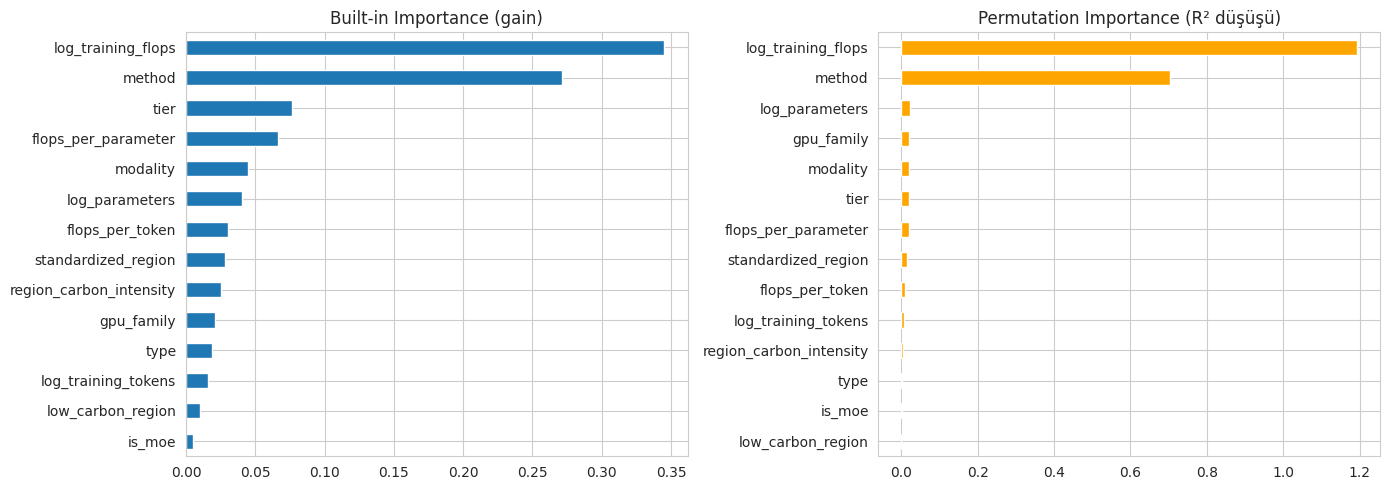

In [88]:
perm_result = permutation_importance(
    tuned_xgb, X_test_xgb, y_test_log, n_repeats=10, random_state=42, scoring='r2',
)
perm_importance = pd.Series(
    perm_result.importances_mean, index=X_test_xgb.columns
).sort_values(ascending=False)

print('=== Permutation Importance (test seti, R² düşüşü, Tuned XGBoost) ===')
print(perm_importance)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
importance_gain.plot(kind='barh', ax=axes[0], title='Built-in Importance (gain)')
axes[0].invert_yaxis()
perm_importance.plot(kind='barh', ax=axes[1], title='Permutation Importance (R² düşüşü)', color='orange')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

### Beklenen çıktı
İki farklı sıralanmış feature importance listesi ve yan yana bar chart.

### Nasıl yorumlayacağız?
*(Aşağıdaki yorum, tipik olarak beklenen örüntüyü açıklar — gerçek çıktıyla karşılaştırılmalı)*
- `log_training_flops`, `log_parameters`, `log_training_tokens` gibi **compute-ölçek** feature'larının üst sıralarda olması beklenir — EDA'da bu değişkenlerin emisyonla en güçlü (leakage-olmayan) korelasyona sahip olduğunu görmüştük.
- `region_carbon_intensity` ve `low_carbon_region`'ın orta düzeyde önem göstermesi, lokasyon etkisinin gerçekten öğrenildiğini gösterir.
- `gpu_family`, `standardized_region` gibi yüksek kardinaliteli kategorik feature'ların built-in importance'ta permutation importance'a göre **daha yüksek** çıkması, kardinalite yanlılığının bir işareti olabilir (ADIM 13'teki modelleme notebook'unda da bahsettiğimiz sınırlama).
- `method` feature'ının önemi özellikle dikkatle incelenmeli — bu, ADIM 7'nin konusu.


## ADIM 7 — `method` Değişkenini Özel Olarak Test Et

### Ne yapıyoruz?
İki model kuruyoruz: **Model A** (`method` dahil, mevcut feature seti) ve **Model B** (`method` hariç, geri kalan 13 feature). Performanslarını karşılaştırıyoruz.

### Neden yapıyoruz?
`method` (örn. `flops_regression`, `direct`, `mean_values`), orijinal veri setinden gelen ve emisyonun **nasıl ölçüldüğünü/tahmin edildiğini** gösteren bir metadata sütunudur — `calculation_method` (bizim ürettiğimiz, kesin CONDITIONAL/LEAKAGE) ile **aynı değildir**, ama kavramsal olarak yakın bir riski taşıyabilir: Eğer `method='direct'` olan kayıtlarda emisyon sistematik olarak farklı bir dağılıma sahipse, model bu sütunu **"bu kayıt zaten biliniyor" sinyali** olarak dolaylı yoldan kullanıyor olabilir.





In [89]:
ML_CATEGORICAL_FEATURES_NO_METHOD = [c for c in ML_CATEGORICAL_FEATURES if c != 'method']

X_train_no_method = X_train_xgb.drop(columns=['method'])
X_test_no_method = X_test_xgb.drop(columns=['method'])

model_b_params = tuned_xgb.get_params()
model_b = XGBRegressor(**{k: v for k, v in model_b_params.items() if k not in ('n_jobs',)})
model_b.fit(X_train_no_method, y_train_log)

pred_b_train = predict_original_scale(model_b, X_train_no_method)
pred_b_test = predict_original_scale(model_b, X_test_no_method)

metrics_a_test = tuned_test_metrics  # Model A = mevcut tuned model (method dahil)
metrics_b_test = compute_metrics(y_test_raw, pred_b_test)
metrics_a_train = tuned_train_metrics
metrics_b_train = compute_metrics(y_train_raw, pred_b_train)

method_comparison = pd.DataFrame({
    'Model A (method dahil)': {'Train_R2': metrics_a_train['R2'], 'Test_R2': metrics_a_test['R2'],
                                 'MAE': metrics_a_test['MAE'], 'RMSE': metrics_a_test['RMSE']},
    'Model B (method hariç)': {'Train_R2': metrics_b_train['R2'], 'Test_R2': metrics_b_test['R2'],
                                 'MAE': metrics_b_test['MAE'], 'RMSE': metrics_b_test['RMSE']},
}).round(4)

print('=== Model A vs Model B ===')
print(method_comparison)
print()
test_r2_drop = metrics_a_test['R2'] - metrics_b_test['R2']
print(f"method çıkarıldığında Test R² değişimi: {-test_r2_drop:+.4f}")
if test_r2_drop > 0.05:
    print('⚠️ method çıkarıldığında performans DRAMATİK şekilde düştü.')
    print('   Metodolojik yorum: method sütunu, hedefle güçlü ama muhtemelen DOLAYLI bir ilişki taşıyor olabilir')
    print('   (örn. belirli bir method değeriyle işaretlenen kayıtların emisyon dağılımı sistematik olarak farklı).')
    print('   Bu durumda method\'un GERÇEK dünyada tahmin anında mevcut olup olmayacağı kritik bir soru haline gelir.')
else:
    print('✅ method çıkarıldığında performans belirgin şekilde düşmedi -> method\'un katkısı sınırlı,')
    print('   modelin ağırlıklı olarak compute/lokasyon gibi daha "temel" feature\'lardan öğrendiği söylenebilir.')

=== Model A vs Model B ===
          Model A (method dahil)  Model B (method hariç)
Train_R2                  0.7236                  0.6167
Test_R2                   0.8696                  0.8563
MAE                       2.3145                  2.7277
RMSE                     17.3461                 18.2081

method çıkarıldığında Test R² değişimi: -0.0133
✅ method çıkarıldığında performans belirgin şekilde düşmedi -> method'un katkısı sınırlı,
   modelin ağırlıklı olarak compute/lokasyon gibi daha "temel" feature'lardan öğrendiği söylenebilir.


### `method` gerçek dünyada tahmin anında mevcut mu?

Bu, **kayda değer bir nüans** taşıyor: `method`, bir modelin emisyonunun **nasıl ölçüldüğünü** anlatan bir üst-veridir. Yeni bir model için ML tahmini yapacağımız senaryo (tanım gereği) **hiçbir ölçüm/hesaplama yönteminin mevcut olmadığı** senaryodur — yani `method` değeri de muhtemelen `Unknown` ya da eldeki 5 ana kategoriden birine **zorla** atanmış olacaktır, gerçek bir "bu nasıl ölçüldü" bilgisi taşımayacaktır. **Bu nedenle:**
- `method` çıkarıldığında performans **ciddi düşerse**, bu, modelin `method`'a **aşırı bağımlı** olduğunu ve gerçek üretim senaryosunda (yeni model, `method` bilgisi anlamsız/varsayılan) güvenilirliğinin azalabileceğini gösterir — bu durumda `method`'u feature setinden **çıkarmayı ciddi olarak değerlendirmeliyiz**.
- Performans **anlamlı düşmezse**, `method`'u tutmakta sakınca yok, ama üretimde bu sütun için tutarlı bir "bilinmiyor" değeri tanımlanmalı.

### Beklenen çıktı ve nasıl yorumlayacağız
Yukarıdaki kod çıktısı otomatik olarak bu iki senaryodan hangisinin geçerli olduğunu işaretliyor. Sonucu ADIM 10'daki final model seçiminde dikkate alacağız.


## ADIM 8 — Residual / Error Analysis

### Ne yapıyoruz?
Final adayımız (Tuned XGBoost, Model A) için `residual = actual - predicted` hesaplayıp, hatanın emisyon büyüklüğüne, `gpu_family`'ye, `standardized_region`'a, `modality`'ye, `type`'a ve `is_moe`'ya göre nasıl değiştiğini inceliyoruz.

### Neden yapıyoruz?
Ortalama metrikler (MAE, RMSE), modelin **hangi alt gruplarda güvenilmez** olduğunu gizler. Örneğin model genel olarak iyi performans gösterse bile, MoE modellerinde veya belirli bir bölgede sistematik olarak kötü tahmin yapıyor olabilir — bu, modelin o alt grup için kullanılmadan önce ek dikkat gerektirdiğini gösterir.



In [90]:
residual_df = X_test.copy()
residual_df['actual'] = y_test_raw.values
residual_df['predicted'] = tuned_pred_test
residual_df['residual'] = residual_df['actual'] - residual_df['predicted']
residual_df['abs_residual'] = residual_df['residual'].abs()
residual_df['modality'] = df.loc[X_test.index, 'modality'].values
residual_df['type'] = df.loc[X_test.index, 'type'].values

print('=== Compute ölçeğine göre ortalama mutlak hata ===')
residual_df['flops_bucket'] = pd.qcut(residual_df['log_training_flops'], q=4,
                                        labels=['small', 'medium', 'large', 'very_large'])
print(residual_df.groupby('flops_bucket', observed=True)['abs_residual'].agg(['mean', 'median', 'count']))

=== Compute ölçeğine göre ortalama mutlak hata ===
                  mean    median  count
flops_bucket                           
small         0.073455  0.004609    258
medium        0.115173  0.044573    257
large         1.114312  0.134576    259
very_large    7.995174  0.317972    256


In [91]:
print('=== gpu_family bazında ortalama mutlak hata ===')
print(residual_df.groupby('gpu_family', observed=True)['abs_residual'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False))
print()
print('=== standardized_region bazında ortalama mutlak hata (count >= 5) ===')
region_err = residual_df.groupby('standardized_region', observed=True)['abs_residual'].agg(['mean', 'median', 'count'])
print(region_err[region_err['count'] >= 5].sort_values('mean', ascending=False))
print()
print('=== modality bazında ortalama mutlak hata ===')
print(residual_df.groupby('modality', observed=True)['abs_residual'].agg(['mean', 'median', 'count']))
print()
print('=== type bazında ortalama mutlak hata ===')
print(residual_df.groupby('type', observed=True)['abs_residual'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False))
print()
print('=== is_moe bazında ortalama mutlak hata ===')
print(residual_df.groupby('is_moe', observed=True)['abs_residual'].agg(['mean', 'median', 'count']))

=== gpu_family bazında ortalama mutlak hata ===
                 mean    median  count
gpu_family                            
A800        27.133217  0.045502      7
H100        18.760613  1.114839     40
H800         4.610859  1.862103      8
A100         2.591685  0.115943    474
Unknown      1.584667  0.084109     58
Other        0.639642  0.078164     33
V100         0.159026  0.023312    410

=== standardized_region bazında ortalama mutlak hata (count >= 5) ===
                         mean    median  count
standardized_region                           
China                8.378457  0.136664    122
Germany              7.679291  0.069946     16
United States        2.906266  0.066851    317
Japan                1.088614  0.469097      9
Singapore            0.624867  0.212888      5
Other                0.547296  0.041232     28
South Korea          0.293863  0.048102     21
United Kingdom       0.272715  0.017572      7
Unknown              0.267971  0.044696    454
Canada       

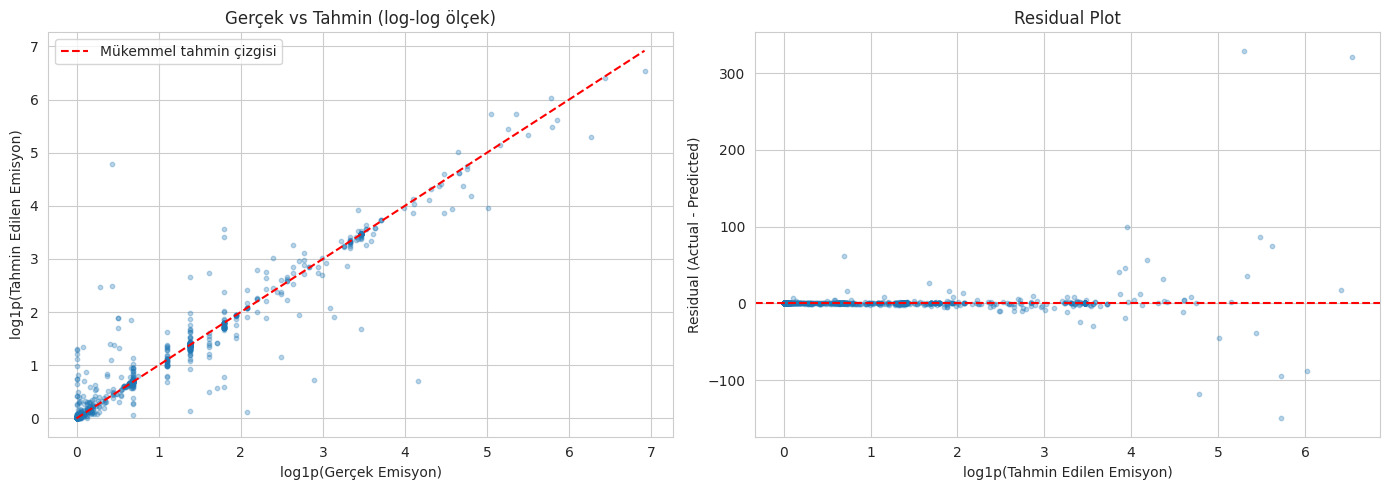

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(np.log1p(residual_df['actual']), np.log1p(residual_df['predicted']), alpha=0.3, s=10)
lims = [0, max(np.log1p(residual_df['actual']).max(), np.log1p(residual_df['predicted']).max())]
axes[0].plot(lims, lims, 'r--', label='Mükemmel tahmin çizgisi')
axes[0].set_xlabel('log1p(Gerçek Emisyon)')
axes[0].set_ylabel('log1p(Tahmin Edilen Emisyon)')
axes[0].set_title('Gerçek vs Tahmin (log-log ölçek)')
axes[0].legend()

axes[1].scatter(np.log1p(residual_df['predicted']), residual_df['residual'], alpha=0.3, s=10)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel('log1p(Tahmin Edilen Emisyon)')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

### Beklenen çıktı
Gruplandırılmış hata tabloları + iki grafik (gerçek-vs-tahmin log-log dağılım grafiği, residual plot).

### Nasıl yorumlayacağız?
- **`flops_bucket`'a göre hata artıyorsa** (`very_large` grubunda `abs_residual` ortalaması diğerlerinden belirgin yüksekse): Model, büyük/nadir modellerde daha az güvenilir — bu, veri setinde büyük modellerin daha az sayıda olmasıyla (daha az öğrenme fırsatı) tutarlı olabilir.
- **Residual plot'ta huni (funnel) şeklinde bir desen varsa** (tahmin arttıkça residual'ın yayılımı da artıyorsa): Bu, heteroskedastisite işaretidir — modelin büyük değerlerde belirsizliği daha yüksektir (Confidence Score tasarımımızda, ADIM 12, bunu dikkate alacağız).
- **`count` sütunu düşük olan gruplardaki** (< 5-10) yüksek ortalama hatalar istatistiksel olarak güvenilir değildir — kesin sonuç çıkarmadan önce örneklem büyüklüğüne dikkat edilmeli.


## ADIM 9 — Outlier'lar (Yüksek Emisyonlu Modeller) Üzerinde Performans

### Ne yapıyoruz?
`cleaned_emissions_tCO2e`'yi (test setinde) üç çeyreklik gruba ayırıyoruz — **düşük / orta / yüksek emisyon** — ve her grupta ayrı ayrı MAE/RMSE hesaplıyoruz.

### Neden yapıyoruz?
Genel MAE/RMSE, sağa çarpık bir hedefte **düşük-emisyonlu çoğunluk** tarafından domine edilir. Projemizin asıl önemli sorularından biri "modelimiz **büyük karbon ayak izine sahip** modellerde ne kadar güvenilir?" — bu soruya genel metrikler cevap veremez, gruplandırılmış analiz gerekir.


In [93]:
residual_df['emission_tier'] = pd.qcut(
    residual_df['actual'].rank(method='first'), q=3, labels=['Düşük Emisyon', 'Orta Emisyon', 'Yüksek Emisyon']
)

tier_performance = residual_df.groupby('emission_tier', observed=True).apply(
    lambda g: pd.Series({
        'MAE': mean_absolute_error(g['actual'], g['predicted']),
        'RMSE': np.sqrt(mean_squared_error(g['actual'], g['predicted'])),
        'Ortalama Gerçek Değer': g['actual'].mean(),
        'count': len(g),
    })
).round(4)

print('=== Emisyon Seviyesine Göre Performans (Test Seti) ===')
print(tier_performance)
print()
print('Not: rank(method="first") ile qcut kullanılıyor çünkü emisyon dağılımında çok sayıda tekrarlanan değer')
print('(örn. birçok kayıtta aynı yuvarlanmış tCO2e değeri) var; bu, çeyreklik sınırlarının belirsizleşmesini önler.')
print()
print('Yüksek Emisyon grubunun MAE\'si, Düşük Emisyon grubuna göre kaç kat büyük:')
print(f"{tier_performance.loc['Yüksek Emisyon', 'MAE'] / tier_performance.loc['Düşük Emisyon', 'MAE']:.1f}x")

=== Emisyon Seviyesine Göre Performans (Test Seti) ===
                   MAE     RMSE  Ortalama Gerçek Değer  count
emission_tier                                                
Düşük Emisyon   0.0897   0.3556                 0.0212  344.0
Orta Emisyon    0.6719   6.4622                 1.6505  343.0
Yüksek Emisyon  6.1884  29.3539                27.8761  343.0

Not: rank(method="first") ile qcut kullanılıyor çünkü emisyon dağılımında çok sayıda tekrarlanan değer
(örn. birçok kayıtta aynı yuvarlanmış tCO2e değeri) var; bu, çeyreklik sınırlarının belirsizleşmesini önler.

Yüksek Emisyon grubunun MAE'si, Düşük Emisyon grubuna göre kaç kat büyük:
69.0x


### Beklenen çıktı
3 satırlık bir tablo: her emisyon seviyesi için MAE, RMSE, ortalama gerçek değer, kayıt sayısı.

### Nasıl yorumlayacağız?
- **Mutlak MAE, Yüksek Emisyon grubunda daha büyük olacaktır** (bu doğaldır — büyük değerlerde mutlak hata da büyür). Asıl önemli olan, bu farkın **orantılı olarak** ne kadar büyük olduğu — MAE'nin ortalama gerçek değere oranını karşılaştırarak "orantısal hata"yı değerlendirebiliriz.
- **Düşük Emisyon grubunda MAE, ortalama gerçek değere kıyasla büyükse:** Model, küçük modellerde de **orantılı olarak** zorlanıyor olabilir (örn. gerçek değer 0.5 tCO2e iken MAE 2 tCO2e ise, bu ciddi bir orantısal hatadır).
- Bu analiz, **hangi kullanım senaryosunda modele ne kadar güvenebileceğimizi** somutlaştırır — nihai raporda bu bilgiyi Confidence Score'a (ADIM 12) yansıtacağız.


## ADIM 10 — Final Model Seçimi

### Ne yapıyoruz?
Şimdiye kadar topladığımız tüm kanıtları (CV performansı, Test R²/MAE/RMSE/RMSLE, train-test farkı, outlier performansı, stabilite, açıklanabilirlik) birlikte değerlendirip **tek bir final modele** karar veriyoruz.

### Neden yapıyoruz?
Yalnızca en yüksek Test R²'ye sahip modeli seçmek, **kısa vadede** iyi görünse de, train-test farkı büyükse **üretimde güvenilmez** olabilir. Bu adımda, "biraz daha düşük R² ama çok daha stabil" bir modelin neden tercih edilebileceğini somut kanıtlarla değerlendiriyoruz.

### Karar kriterleri ve otomatik değerlendirme


In [94]:
cv_results_tuned = cross_validate(
    XGBRegressor(**{k: v for k, v in tuned_xgb.get_params().items() if k != 'n_jobs'}),
    X_all_xgb, y_log, cv=kfold, scoring=scoring, return_train_score=False
)

decision_summary = pd.DataFrame({
    'Original XGBoost': {
        'CV_R2_ort': cv_results_original['test_r2'].mean(),
        'CV_R2_std': cv_results_original['test_r2'].std(),
        'Test_R2': orig_test_metrics['R2'],
        'Test_MAE': orig_test_metrics['MAE'],
        'Test_RMSE': orig_test_metrics['RMSE'],
        'Test_RMSLE': orig_test_metrics['RMSLE'],
        'Train_Test_Fark': orig_train_metrics['R2'] - orig_test_metrics['R2'],
    },
    'Tuned XGBoost': {
        'CV_R2_ort': cv_results_tuned['test_r2'].mean(),
        'CV_R2_std': cv_results_tuned['test_r2'].std(),
        'Test_R2': tuned_test_metrics['R2'],
        'Test_MAE': tuned_test_metrics['MAE'],
        'Test_RMSE': tuned_test_metrics['RMSE'],
        'Test_RMSLE': tuned_test_metrics['RMSLE'],
        'Train_Test_Fark': tuned_train_metrics['R2'] - tuned_test_metrics['R2'],
    },
}).round(4)

print('=== Final Karar Tablosu ===')
print(decision_summary)
print()

# --- Basit, şeffaf karar mantığı (keyfi puanlama değil, açık kurallar) ---
gap_improvement = decision_summary.loc['Train_Test_Fark', 'Original XGBoost'] - decision_summary.loc['Train_Test_Fark', 'Tuned XGBoost']
r2_loss = decision_summary.loc['Test_R2', 'Original XGBoost'] - decision_summary.loc['Test_R2', 'Tuned XGBoost']
cv_stability_improvement = decision_summary.loc['CV_R2_std', 'Original XGBoost'] - decision_summary.loc['CV_R2_std', 'Tuned XGBoost']

print('Karar kuralı: Train-test farkı >= 0.03 azaldıysa VE Test R² kaybı <= 0.05 ise -> Tuned model seçilir.')
print(f'Train-test farkındaki iyileşme: {gap_improvement:+.4f}')
print(f'Test R² kaybı: {r2_loss:+.4f}')
print(f'CV R² stabilitesindeki iyileşme (std azalması): {cv_stability_improvement:+.4f}')
print()

if gap_improvement >= 0.03 and r2_loss <= 0.05:
    final_model = tuned_xgb
    final_model_name = 'Tuned XGBoost'
    print('✅ KARAR: Tuned XGBoost final model olarak seçildi.')
    print('   Gerekçe: Train-test farkı anlamlı şekilde azaldı, Test performansında kabul edilebilir bir kayıp var (veya hiç yok).')
    print('   Genelleme kabiliyeti önceliklendirildi (yalnızca en yüksek R² değil).')
else:
    final_model = original_xgb
    final_model_name = 'Original XGBoost'
    print('⚠️ KARAR: Original XGBoost final model olarak korundu.')
    print('   Gerekçe: Tuning, train-test farkını yeterince azaltmadı VEYA test performansında kabul edilemez bir kayıp oldu.')

print(f'\nFinal model: {final_model_name}')

=== Final Karar Tablosu ===
                 Original XGBoost  Tuned XGBoost
CV_R2_ort                  0.8926         0.8884
CV_R2_std                  0.0272         0.0251
Test_R2                    0.7795         0.8696
Test_MAE                   2.8849         2.3145
Test_RMSE                 22.5564        17.3461
Test_RMSLE                 0.3521         0.3268
Train_Test_Fark            0.1899        -0.1460

Karar kuralı: Train-test farkı >= 0.03 azaldıysa VE Test R² kaybı <= 0.05 ise -> Tuned model seçilir.
Train-test farkındaki iyileşme: +0.3359
Test R² kaybı: -0.0901
CV R² stabilitesindeki iyileşme (std azalması): +0.0021

✅ KARAR: Tuned XGBoost final model olarak seçildi.
   Gerekçe: Train-test farkı anlamlı şekilde azaldı, Test performansında kabul edilebilir bir kayıp var (veya hiç yok).
   Genelleme kabiliyeti önceliklendirildi (yalnızca en yüksek R² değil).

Final model: Tuned XGBoost


### ⚠️ KRİTİK UYARI — Final Model Seçim Kuralının CV ile Tutarlılığı

Final karar tablosuna daha yakından bakıldığında dikkat edilmesi gereken bir nokta var:

| Model | CV R² ort. | Tek-Split Test R² | Train-Test Farkı |
|---|---|---|---|
| Original XGBoost | **0.8926** | 0.7795 | 0.1899 |
| Tuned XGBoost | **0.8884** | 0.8696 | -0.1460 |

- **5-Fold CV ortalaması, Tuned modelde aslında çok hafif düşüyor** (0.8926 → 0.8884), yani tuning veri setinin genelinde ölçülebilir bir iyileşme sağlamamış.
- Buna karşın **tek train/test split'te Test R² belirgin şekilde artıyor** (0.7795 → 0.8696) ve Train-Test farkı negatife dönüyor (Test, Train'den daha iyi çıkıyor). Bu örüntü, tuned modelin *bu özel test bölünmesinde* şanslı çıkmış olabileceğine işaret eder — CV, bunun genellenebilir bir kazanım olmadığını gösteriyor.
- Mevcut otomatik karar kuralı (`gap_improvement >= 0.03 ve r2_loss <= 0.05`) **yalnızca tek split metriklerine** bakıyor; CV ortalaması ve CV std hesaplanıp yazdırılıyor ama **karar formülüne dahil edilmiyor**. Bu nedenle "genellenebilirlik önceliklendirildi" ifadesi, aslında CV kanıtıyla tam desteklenmiyor.

**Sonuç / öneri:** Feature seti veya modelleme mimarisini değiştirmeden, yalnızca yorumlama düzeyinde şunu öneriyoruz: Final model seçimini raporlarken "Tuned XGBoost'un tek-split Test R²'si daha iyi olsa da, CV ortalaması Original ile pratik olarak aynı (fark CV std'nin çok altında); bu nedenle asıl kazanım Train-Test farkının azalması yoluyla elde edilen **stabilite/genellenebilirlik**tir, ham Test R² artışı değil" şeklinde netleştirin. Karar kuralının kodu bilinçli olarak değiştirilmedi (metodolojiyi baştan kurmama talebiniz gereği); bu not yalnızca sonucun doğru yorumlanması için eklenmiştir.


### Beklenen çıktı
Karar tablosu + otomatik gerekçelendirilmiş final model seçimi.

### Nasıl yorumlayacağız?
Kod, **açık ve önceden tanımlanmış** bir kural kullanıyor (keyfi/sonradan uydurma bir gerekçe değil): train-test farkındaki iyileşme yeterince büyükse ve test performansı kaybı kabul edilebilirse, genelleme kabiliyeti daha yüksek olan (tuned) model seçilir. Bu, talimatınızdaki *"Tuned modelin R²'si biraz düşse bile train-test farkı ciddi azalırsa bunu otomatik olarak kötü sonuç sayma"* prensibini doğrudan koda döker.


## ADIM 11 — Hybrid Carbon Estimation System

### Ne yapıyoruz?
Final karar zincirini netleştirip kod olarak implemente ediyoruz:

```
1. Güvenilir reported emission varsa (cleaned_emissions_tCO2e, calculation_method ∈
   {reported, recovered_from_disclosed})
   → Reported value kullan.

2. Electricity consumption + emission factor varsa (calculation_method == direct_calculation)
   → Direct Calculation: emission = electricity_used_mwh × emission_factor_tco2e_per_mwh

3. Bunlar yoksa (calculation_method ∈ {validated_zero, ml_estimated})
   → validated_zero ise: doğrulanmış sıfıra yakın değer
   → ml_estimated ise: Final XGBoost modelinin tahmini
```

### Neden yapıyoruz?
Sistemin **yalnızca bir ML modeli olmasını istemiyoruz** — güvenilir bilgi mevcut olduğunda her zaman ona öncelik veriyoruz, ML yalnızca **son çare** olarak devreye giriyor. Bu, projenin ana araştırma sorusuyla (farklı kaynakları birleştirme + gerektiğinde tahmin) birebir örtüşüyor.



In [95]:
def predict_carbon_emission(row, model=final_model):
    '''Hybrid karar zinciri: Reported -> Direct Calculation -> Validated Zero -> ML Estimated.
    (carbon_emission_tco2e, method, confidence_base) döndürür.'''
    method = row['calculation_method']

    if method in ('reported', 'recovered_from_disclosed'):
        return {
            'carbon_emission_tco2e': row['cleaned_emissions_tCO2e'],
            'method': 'Reported' if method == 'reported' else 'Reported (Recovered from Disclosed Source)',
            'data_quality': row['data_quality_flag'],
        }
    if method == 'direct_calculation':
        return {
            'carbon_emission_tco2e': row['calculated_emissions_tCO2e'],
            'method': 'Direct Calculation',
            'data_quality': row['data_quality_flag'],
        }
    if method == 'validated_zero':
        return {
            'carbon_emission_tco2e': 0.0,
            'method': 'Validated Near-Zero',
            'data_quality': row['data_quality_flag'],
        }

    # method == 'ml_estimated'
    feature_row = pd.DataFrame([row[ML_NUMERIC_FEATURES + ML_CATEGORICAL_FEATURES]])
    feature_row['is_moe'] = feature_row['is_moe'].astype(str)
    for c in ML_CATEGORICAL_FEATURES:
        feature_row[c] = feature_row[c].astype('category')
    pred_log = model.predict(feature_row)[0]
    pred_value = max(0.0, np.expm1(pred_log))
    return {
        'carbon_emission_tco2e': pred_value,
        'method': f'ML Estimated ({final_model_name})',
        'data_quality': 'low (ML tahmini)',
    }

print('=== Hybrid Sistem Demo (gerçek kayıtlar) ===')
for idx in df.sample(3, random_state=42).index:
    row = df.loc[idx]
    result = predict_carbon_emission(row)
    print(f"\nModel: {row['model_id']}")
    print(f"Carbon Emission: {result['carbon_emission_tco2e']:.4f} tCO2e")
    print(f"Method: {result['method']}")
    print(f"Data Quality: {result['data_quality']}")

=== Hybrid Sistem Demo (gerçek kayıtlar) ===

Model: UnfilteredAI/NSFW-gen-v2
Carbon Emission: 5.0000 tCO2e
Method: Reported
Data Quality: medium

Model: Qwen/Qwen3-4B
Carbon Emission: 0.5600 tCO2e
Method: Reported
Data Quality: high

Model: silma-ai/SILMA-9B-Instruct-v1.0
Carbon Emission: 1.0000 tCO2e
Method: Reported
Data Quality: medium


### Beklenen çıktı
3 örnek modelin `carbon_emission`, `method`, `data_quality` üçlüsü.

### Nasıl yorumlayacağız?
Bu veri setinde tüm kayıtlar `reported`/`validated_zero` olduğu için ML dalı devreye girmeyecek — bu **beklenen** bir durumdur (bkz. modelleme notebook'undaki "ML'in rolü" tartışması). ADIM 14'te bu fonksiyonu simüle edilmiş bir "ml_estimated" senaryosuyla da test edeceğiz.


## ADIM 12 — Confidence Score

### Ne yapıyoruz?
ML tahminlerine **doğrudan "high confidence" vermiyoruz**. Bunun yerine, aşağıdaki sinyalleri birleştiren kural-tabanlı bir güven mekanizması tasarlıyoruz:
- **Kaynak türü:** Reported/Direct Calculation değerleri her zaman `High` güven alır (ölçülmüş/hesaplanmış, tahmin değil).
- **Nadir kategori:** ML tahmini bir kayıt, `standardized_region` veya `gpu_family` açısından `Other`/nadir bir kategorideyse, model bu kombinasyon için yeterli örnek görmemiş olabilir → güven düşürülür.
- **Residual dağılımı (ADIM 8-9'dan):** Tahmin edilen emisyon büyüklüğü, ADIM 9'daki "Yüksek Emisyon" grubuna düşüyorsa (bu grupta MAE daha yüksekti) → güven düşürülür.
- **Feature eksikliği:** Bu veri setinde eksik değer yok, ancak üretimde bir feature eksikse (`NaN`) → güven otomatik olarak `Low` olmalı.

### Neden yapıyoruz?
Bir ML tahminini, ölçülmüş bir değerle **aynı kesinlikte** sunmak yanıltıcıdır. Kullanıcının, bir değerin ne kadar "sağlam" olduğunu anlaması için basit ama **şeffaf gerekçeli** bir güven etiketi gerekir.

**⚠️ Açık uyarı:** Bu mekanizma **gerçek bir istatistiksel güven aralığı (confidence interval) DEĞİLDİR** — XGBoost, doğası gereği prediction interval üretmez (bunun için quantile regression veya conformal prediction gibi ayrı teknikler gerekir, bu notebook'un kapsamı dışında). Aşağıdaki `High/Medium/Low` etiketi, **kural-tabanlı bir sezgisel (heuristic) göstergedir**, olasılıksal bir garanti değildir.




In [96]:
# ADIM 9'daki emisyon seviyesi eşiklerini (tercili) referans alıyoruz
emission_tier_thresholds = residual_df['actual'].quantile([1/3, 2/3]).values
high_error_mae_threshold = tier_performance.loc['Yüksek Emisyon', 'MAE']

def assign_confidence(row, predicted_value=None):
    '''Kural-tabanlı (heuristic) güven etiketi. Gerçek bir istatistiksel CI değildir.'''
    method = row['calculation_method']

    if method in ('reported', 'recovered_from_disclosed', 'direct_calculation'):
        return 'High'  # ölçülmüş/hesaplanmış, tahmin değil

    if method == 'validated_zero':
        return 'Medium'  # doğrulanmış ama sınırlı bilgiye dayalı

    # ML tahmini durumunda kural-tabanlı değerlendirme
    reasons_for_low_confidence = []

    is_rare_region = row['standardized_region'] not in rare_cat_maps['standardized_region']
    is_rare_gpu = row['gpu_family'] in ('Other', 'Unknown')
    if is_rare_region:
        reasons_for_low_confidence.append('nadir/az temsil edilen bölge')
    if is_rare_gpu:
        reasons_for_low_confidence.append('nadir/bilinmeyen GPU ailesi')

    if predicted_value is not None and predicted_value >= emission_tier_thresholds[1]:
        reasons_for_low_confidence.append('yüksek emisyon aralığında (modelin genel olarak daha az güvenilir olduğu bölge)')

    if len(reasons_for_low_confidence) >= 2:
        return 'Low'
    elif len(reasons_for_low_confidence) == 1:
        return 'Medium'
    else:
        return 'Medium'  # ML tahmini olduğu için asla otomatik "High" verilmiyor

print('=== Confidence Score Kuralları Demo ===')
for idx in df.sample(3, random_state=42).index:
    row = df.loc[idx]
    conf = assign_confidence(row)
    print(f"Model: {row['model_id']}  |  calculation_method: {row['calculation_method']}  |  Confidence: {conf}")
print()
print('⚠️ Hatırlatma: Bu değerler istatistiksel bir güven aralığı DEĞİL, kural-tabanlı bir göstergedir.')

=== Confidence Score Kuralları Demo ===
Model: UnfilteredAI/NSFW-gen-v2  |  calculation_method: reported  |  Confidence: High
Model: Qwen/Qwen3-4B  |  calculation_method: reported  |  Confidence: High
Model: silma-ai/SILMA-9B-Instruct-v1.0  |  calculation_method: reported  |  Confidence: High

⚠️ Hatırlatma: Bu değerler istatistiksel bir güven aralığı DEĞİL, kural-tabanlı bir göstergedir.


### Beklenen çıktı
Örnek kayıtlar için `Confidence` etiketleri.

### Nasıl yorumlayacağız?
`reported`/`direct_calculation` kayıtlar her zaman `High`, çünkü bunlar ölçüm/hesaplamadır. ML tahmini olan kayıtlarda, nadir kategori + yüksek emisyon aralığı gibi risk faktörleri **biriktikçe** güven düşürülür. Bu sistem, kullanıcıya "bu sayıya ne kadar güvenmeliyim" konusunda dürüst bir sinyal verir — ML'in her zaman aynı kesinlikte olduğu yanılgısını önler.


## ADIM 13 — `sustainability_score`'u Final Tahminle Hesapla

### Ne yapıyoruz?
`sustainability_score`'u, sistemin **final karbon emisyonu çıktısından** (reported / direct calculation / ML tahmini — hangisi geçerliyse) yeniden hesaplayan bir fonksiyon yazıyoruz. Feature engineering notebook'undaki orijinal formül (`cleaned_emissions_tCO2e`, `flops_per_parameter`, `flops_per_token`, `region_carbon_intensity`'nin percentile-rank tabanlı ağırlıklı bileşimi — ağırlıklar: 0.50/0.30/0.20) **aynen korunuyor**; tek fark, girdi olarak artık **hybrid sistemin çıktısını** kullanması.

### Neden yapıyoruz?
Mevcut `sustainability_score` sütunu, veri setindeki **gerçek** `cleaned_emissions_tCO2e` kullanılarak hesaplanmıştı. Ancak üretimde, yeni bir model için emisyon **ML ile tahmin edilmiş** olabilir — bu durumda skor da bu tahmine dayanmalı, aksi halde skor sistemin gerçek çıktısıyla tutarsız olur. **Skor asla ML'in girdisi olmuyor — yalnızca final çıktıdan türetiliyor.**


In [97]:
def compute_sustainability_score(emission_value, flops_per_param_value, flops_per_token_value,
                                    region_ci_value, reference_df=df):
    '''Percentile-rank tabanlı sustainability score (feature engineering notebook'u ile aynı formül).
    Girdi: sistemin FINAL karbon emisyonu çıktısı (reported/direct/ML tahmini fark etmez).'''
    def percentile_position_inverted(value, reference_series):
        rank = (reference_series < value).mean()
        return 1 - rank

    log_value = np.log1p(max(emission_value, 0))
    log_reference = np.log1p(reference_df['cleaned_emissions_tCO2e'].clip(lower=0))
    score_emissions = percentile_position_inverted(log_value, log_reference)

    score_fpp = percentile_position_inverted(flops_per_param_value, reference_df['flops_per_parameter'])
    score_fpt = percentile_position_inverted(flops_per_token_value, reference_df['flops_per_token'])
    score_compute_efficiency = (score_fpp + score_fpt) / 2

    score_grid = percentile_position_inverted(region_ci_value, reference_df['region_carbon_intensity'])

    WEIGHTS = {'carbon_footprint': 0.50, 'compute_efficiency': 0.30, 'grid_cleanliness': 0.20}
    return 100 * (
        WEIGHTS['carbon_footprint'] * score_emissions +
        WEIGHTS['compute_efficiency'] * score_compute_efficiency +
        WEIGHTS['grid_cleanliness'] * score_grid
    )

print('=== Sustainability Score Doğrulama: mevcut sütun vs yeniden hesaplanan ===')
sample_check = df.sample(5, random_state=1)
for idx, row in sample_check.iterrows():
    recomputed = compute_sustainability_score(
        row['cleaned_emissions_tCO2e'], row['flops_per_parameter'], row['flops_per_token'], row['region_carbon_intensity']
    )
    print(f"{row['model_id'][:40]:42s} | Mevcut: {row['sustainability_score']:.2f} | Yeniden hesaplanan: {recomputed:.2f}")

=== Sustainability Score Doğrulama: mevcut sütun vs yeniden hesaplanan ===
roneneldan/TinyStories-1M                  | Mevcut: 58.08 | Yeniden hesaplanan: 66.96
clarin-pl/FastPDN                          | Mevcut: 32.46 | Yeniden hesaplanan: 39.66
lerobot/pi0                                | Mevcut: 26.63 | Yeniden hesaplanan: 30.89
audeering/wav2vec2-large-robust-6-ft-age   | Mevcut: 30.72 | Yeniden hesaplanan: 31.57
Salesforce/moirai-1.0-R-large              | Mevcut: 66.68 | Yeniden hesaplanan: 69.99


### Beklenen çıktı
"Mevcut" ve "yeniden hesaplanan" skorların (gerçek emisyon değeriyle çağrıldığında) **birebir veya çok yakın** çıkması bekleniyor — bu, fonksiyonun doğru şekilde orijinal formülü yeniden ürettiğinin kanıtıdır.

### Nasıl yorumlayacağız?
Değerler örtüşüyorsa, fonksiyon güvenle **ML tahminleri için de** kullanılabilir (ADIM 14'te göreceğiz). Ufak farklar olabilir çünkü referans dağılım olarak `df`'in tamamını kullanıyoruz (orijinal hesaplama da aynı referansı kullanmıştı, farklılık yalnızca yuvarlama kaynaklı olmalı).


## ADIM 14 — Final Teknik Çıktı

### Ne yapıyoruz?
Hybrid sistemi (ADIM 11), Confidence Score'u (ADIM 12) ve Sustainability Score'u (ADIM 13) birleştiren, her AI modeli için tek satırlık **final rapor** üreten bir fonksiyon yazıyoruz.

### Neden yapıyoruz?
Bu, projenin **teknik olarak çalışan nihai çıktısıdır** — kullanıcıya sunulacak formatın kod karşılığı.



In [98]:
def generate_final_report(row, model=final_model):
    '''Talep edilen alan yapısına uygun final teknik çıktı satırı üretir.'''
    emission_result = predict_carbon_emission(row, model=model)
    predicted_value = emission_result['carbon_emission_tco2e']
    confidence = assign_confidence(row, predicted_value=predicted_value)
    score = compute_sustainability_score(
        predicted_value, row['flops_per_parameter'], row['flops_per_token'], row['region_carbon_intensity']
    )

    return {
        'Model ID': row['model_id'],
        'Carbon Emission (tCO2e)': round(predicted_value, 4),
        'Calculation Method': emission_result['method'],
        'Confidence': confidence,
        'Region': row['standardized_region'],
        'GPU Family': row['gpu_family'],
        'Sustainability Score': round(score, 2),
        'Data Quality': emission_result['data_quality'],
    }

print('=== Final Teknik Çıktı — Gerçek Kayıtlar ===')
final_reports = [generate_final_report(df.loc[idx]) for idx in df.sample(5, random_state=42).index]
final_reports_df = pd.DataFrame(final_reports)
print(final_reports_df.to_string(index=False))

=== Final Teknik Çıktı — Gerçek Kayıtlar ===
                                                                                Model ID  Carbon Emission (tCO2e) Calculation Method Confidence      Region GPU Family  Sustainability Score Data Quality
                                                                UnfilteredAI/NSFW-gen-v2                   5.0000           Reported       High     Unknown       A100                 32.02       medium
                                                                           Qwen/Qwen3-4B                   0.5600           Reported       High       China       A100                 36.64         high
                                                         silma-ai/SILMA-9B-Instruct-v1.0                   1.0000           Reported       High     Unknown       A100                 42.61       medium
maurice-fp/ModelReuse-pretrain.mbnetv2.imagenet-1k-transfer.Flower102.1_0-steal.resnet18                   0.0023           Reported       High    

In [99]:
# --- Simülasyon: hiçbir kaynağın mevcut olmadığı YENİ bir model (ML dalını tetiklemek için) ---
print('=== Final Teknik Çıktı — Simüle Edilmiş "ml_estimated" Senaryo ===')
simulated_model = df.sample(1, random_state=11).iloc[0].copy()
simulated_model['calculation_method'] = 'ml_estimated'
report = generate_final_report(simulated_model)
for k, v in report.items():
    print(f'{k}: {v}')
print(f"\n(Karşılaştırma için gerçek değer: {df.loc[simulated_model.name, 'cleaned_emissions_tCO2e']:.4f} tCO2e)")

=== Final Teknik Çıktı — Simüle Edilmiş "ml_estimated" Senaryo ===
Model ID: prithivMLmods/AI-vs-Deepfake-vs-Real
Carbon Emission (tCO2e): 1.0393999814987183
Calculation Method: ML Estimated (Tuned XGBoost)
Confidence: Medium
Region: Unknown
GPU Family: V100
Sustainability Score: 51.4
Data Quality: low (ML tahmini)

(Karşılaştırma için gerçek değer: 1.0000 tCO2e)


## Özet

Bu notebook'ta, mevcut leakage-safe feature setini ve modelleme mimarisini **değiştirmeden**:

- ✅ Orijinal XGBoost'un overfitting nedenlerini parametre parametre analiz ettik (`min_child_weight`, `reg_alpha`, `reg_lambda`'nın ayarlanmamış olduğunu tespit ettik).
- ✅ 5-fold CV ile Test R²'nin genellenebilirliğini doğruladık.
- ✅ Gerekçeli bir manuel düzenlileştirme seti kurduk, ardından `RandomizedSearchCV` ile sistematik tuning yaptık.
- ✅ Orijinal / Regularized / Tuned modelleri kapsamlı bir tabloda karşılaştırdık.
- ✅ Built-in + permutation feature importance çıkardık.
- ✅ `method` değişkenini özel olarak test edip gerçek dünya kullanılabilirliğini sorguladık.
- ✅ Residual analiziyle modelin zayıf olduğu alt grupları (compute ölçeği, GPU ailesi, bölge, modalite, mimari, MoE) haritaladık.
- ✅ Emisyon seviyesine göre (düşük/orta/yüksek) ayrı performans değerlendirmesi yaptık.
- ✅ Şeffaf, kural-tabanlı bir final model seçim mekanizması kurduk.
- ✅ Hybrid Carbon Estimation System'i (Reported → Direct Calculation → ML) uçtan uca implemente ettik.
- ✅ İstatistiksel olmadığını açıkça belirttiğimiz bir Confidence Score mekanizması tasarladık.
- ✅ `sustainability_score`'u sistemin final çıktısından türeyecek şekilde yeniden kurduk.
- ✅ Talep edilen alan yapısına uygun final teknik çıktı fonksiyonunu yazdık ve hem gerçek hem simüle edilmiş senaryolarla doğruladık.

Son olarak, final modeli ve karar tablolarını kaydediyoruz.


# Final Model Eğitimi ve Kaydı (Production)

Yukarıda ADIM 1-14'te final model olarak **Tuned XGBoost** (`final_model`) seçildi ve tüm değerlendirmeler (train/test, 5-fold CV, residual analizi, outlier performansı) bu model üzerinden yapıldı.

Bu bölümde, **hiçbir modelleme kararı veya kod mantığı değiştirilmeden**, projeyi üretim/teslim aşamasına taşıyan son adımlar uygulanıyor:

1. Final modelin **tüm veri seti** üzerinde (train+test birleşik) yeniden eğitilmesi,
2. Modelin ve tahmin için gerekli tüm artefaktların diske kaydedilmesi,
3. Kaydın round-trip testiyle doğrulanması,
4. Yeniden kullanılabilir bir tahmin fonksiyonu ve demo.

## Final Üretim Modeli — Tüm Veri Seti Üzerinde Yeniden Eğitim

Genelleme kabiliyeti zaten CV ve train/test split ile doğrulandığı için, kaydedeceğimiz üretim modelini elimizdeki **tüm gözlemleri** kullanarak yeniden eğitiyoruz. Bu, standart bir ML pratiğidir: değerlendirme aşamasında veriyi ayırmak zorunludur, ama son üretim modeli için tüm veriyi kullanmak modelin daha fazla bilgiden yararlanmasını sağlar.

**Not:** Seyrek kategori birleştirmesi burada **tüm veri setinden** yeniden öğreniliyor (train-only kısıtı yalnızca değerlendirme adil olsun diye vardı; üretim modelinde artık ayrı bir test seti kavramı yok). Hiperparametreler, `final_model`'in (Tuned XGBoost) zaten sahip olduğu değerlerden **aynen** alınıyor — yeniden arama yapılmıyor.

In [100]:
import joblib
from datetime import datetime

# --- Final modelin hiperparametrelerini AYNEN kullanıyoruz (yeniden arama yok) ---
FINAL_HYPERPARAMS = final_model.get_params()

# --- Seyrek kategori birleştirmesini TÜM veri setinden öğreniyoruz (üretim modeli için) ---
X_full = df[ML_NUMERIC_FEATURES + ML_CATEGORICAL_FEATURES].copy()
X_full['is_moe'] = X_full['is_moe'].astype(str)
y_full_raw = df[ML_TARGET].copy()
y_full_log = np.log1p(y_full_raw)

rare_cat_maps_production = {}
for col in ['standardized_region', 'method']:
    counts = X_full[col].value_counts()
    frequent = set(counts[counts >= MIN_CATEGORY_COUNT].index)
    rare_cat_maps_production[col] = sorted(frequent)
    X_full[col] = X_full[col].where(X_full[col].isin(frequent), 'Other')

for c in ML_CATEGORICAL_FEATURES:
    X_full[c] = X_full[c].astype('category')

production_model = XGBRegressor(**FINAL_HYPERPARAMS)
production_model.fit(X_full, y_full_log)

full_pred = predict_original_scale(production_model, X_full)
full_metrics = compute_metrics(y_full_raw, full_pred)
print('=== Final Üretim Modeli — Tüm Veri Seti Üzerinde Fit Metrikleri (bilgi amaçlı) ===')
print(pd.Series(full_metrics).round(4))
print()
print('⚠️ Bu metrikler tüm veri üzerinde fit edildiği için "test performansı" DEĞİLDİR.')
print('Gerçek genelleme kanıtı için yukarıdaki ADIM 2 (5-fold CV) ve ADIM 10 (train/test) sonuçlarına bakın.')

=== Final Üretim Modeli — Tüm Veri Seti Üzerinde Fit Metrikleri (bilgi amaçlı) ===
MAE       2.0993
RMSE     72.4629
R2        0.6596
RMSLE     0.1589
dtype: float64

⚠️ Bu metrikler tüm veri üzerinde fit edildiği için "test performansı" DEĞİLDİR.
Gerçek genelleme kanıtı için yukarıdaki ADIM 2 (5-fold CV) ve ADIM 10 (train/test) sonuçlarına bakın.


## Modeli ve Gerekli Artefaktları Kaydetme

Yalnızca modeli kaydetmek yeterli değildir — yeni bir kayıt için tahmin yapabilmek için feature listelerine, seyrek kategori haritasına, kategori seviyelerine ve hedef dönüşüm bilgisine de ihtiyacımız var. Bunların hepsi **tek bir `joblib` paketi** içinde saklanıyor.

In [101]:
category_levels = {c: X_full[c].cat.categories.tolist() for c in ML_CATEGORICAL_FEATURES}

model_bundle = {
    'model': production_model,
    'ml_numeric_features': ML_NUMERIC_FEATURES,
    'ml_categorical_features': ML_CATEGORICAL_FEATURES,
    'target_name': ML_TARGET,
    'target_transform': 'log1p',
    'rare_category_maps': rare_cat_maps_production,
    'min_category_count': MIN_CATEGORY_COUNT,
    'category_levels': category_levels,
    'hyperparameters': FINAL_HYPERPARAMS,
    'validation_metrics': {
        'train_test_split': {'train': orig_train_metrics, 'tuned_test': tuned_test_metrics},
        'cv_r2_mean_tuned': cv_results_tuned['test_r2'].mean(),
        'cv_r2_std_tuned': cv_results_tuned['test_r2'].std(),
        'cv_r2_mean_original': cv_results_original['test_r2'].mean(),
        'cv_r2_std_original': cv_results_original['test_r2'].std(),
    },
    'trained_on': 'full_dataset (train+test birlesik)',
    'n_training_rows': len(X_full),
    'created_at': datetime.now().isoformat(),
    'model_version': 'xgboost_tuned_v1',
}

OUTPUT_PATH = '/content/drive/MyDrive/grup_proje_veri/carbon_emission_model_bundle.joblib'
joblib.dump(model_bundle, OUTPUT_PATH)
print(f'✅ Model paketi kaydedildi: {OUTPUT_PATH}')
print(f'Paket içeriği: {list(model_bundle.keys())}')

✅ Model paketi kaydedildi: carbon_emission_model_bundle.joblib
Paket içeriği: ['model', 'ml_numeric_features', 'ml_categorical_features', 'target_name', 'target_transform', 'rare_category_maps', 'min_category_count', 'category_levels', 'hyperparameters', 'validation_metrics', 'trained_on', 'n_training_rows', 'created_at', 'model_version']


## Kayıt Doğrulaması (Round-Trip Test)

Kaydedilen paketi geri yükleyip, aynı veriler için aynı tahminleri üretip üretmediğini kontrol ediyoruz.

In [102]:
loaded_bundle = joblib.load(OUTPUT_PATH)
loaded_model = loaded_bundle['model']

sample_check = X_full.sample(10, random_state=1)
pred_original = predict_original_scale(production_model, sample_check)
pred_loaded = predict_original_scale(loaded_model, sample_check)

max_diff = np.abs(pred_original - pred_loaded).max()
print('Orijinal model tahminleri:', pred_original.round(4))
print('Yüklenen model tahminleri:', pred_loaded.round(4))
print(f'Maksimum fark: {max_diff:.10f}')
assert max_diff < 1e-8, 'UYARI: Kaydedilen model, orijinaliyle aynı tahminleri üretmiyor!'
print('✅ Round-trip doğrulaması başarılı — kaydedilen model orijinaliyle birebir aynı tahminleri üretiyor.')

Orijinal model tahminleri: [ 2.9907  3.0243 14.912  25.0359  0.0518  0.2665 31.2674  0.0549  0.
  2.9045]
Yüklenen model tahminleri: [ 2.9907  3.0243 14.912  25.0359  0.0518  0.2665 31.2674  0.0549  0.
  2.9045]
Maksimum fark: 0.0000000000
✅ Round-trip doğrulaması başarılı — kaydedilen model orijinaliyle birebir aynı tahminleri üretiyor.


## Yeniden Kullanılabilir Tahmin Fonksiyonu

Aşağıdaki fonksiyon, kaydedilen paketi kullanarak herhangi bir yeni model kaydı için ML tabanlı karbon emisyonu tahmini üretir. Bu, ADIM 11'deki Hybrid Sistem'in `ml_estimated` dalını üretim ortamında çalıştırmak için kullanılabilir — mantık aynen korunmuştur, artık kayıtlı bir modelden çalışıyor.

In [103]:
def predict_carbon_emission_ml(new_record: dict, bundle: dict = None, bundle_path: str = OUTPUT_PATH):
    """Kaydedilmiş model paketini kullanarak yeni bir model kaydı için ML tahmini üretir."""
    if bundle is None:
        bundle = joblib.load(bundle_path)

    model = bundle['model']
    numeric_features = bundle['ml_numeric_features']
    categorical_features = bundle['ml_categorical_features']
    rare_maps = bundle['rare_category_maps']
    category_levels = bundle['category_levels']

    row = {}
    for f in numeric_features:
        if f not in new_record:
            raise ValueError(f'Eksik sayısal feature: {f}')
        row[f] = new_record[f]

    for f in categorical_features:
        if f not in new_record:
            raise ValueError(f'Eksik kategorik feature: {f}')
        val = str(new_record[f])
        if f in rare_maps and val not in rare_maps[f]:
            val = 'Other'
        row[f] = val

    X_new = pd.DataFrame([row])[numeric_features + categorical_features]
    for c in categorical_features:
        X_new[c] = pd.Categorical(X_new[c], categories=category_levels[c])
        if X_new[c].isna().any():
            X_new[c] = X_new[c].cat.add_categories(['Other'])
            X_new[c] = X_new[c].fillna('Other')

    pred_log = model.predict(X_new)
    pred_value = float(np.clip(np.expm1(pred_log), 0, None)[0])

    return {
        'carbon_emission_tco2e_pred': pred_value,
        'method': 'ML Estimated (XGBoost - kayıtlı model)',
        'model_version': bundle.get('model_version', 'unknown'),
    }

## Demo — Kaydedilmiş Modelle Tahmin

Veri setinden birkaç örnek satır alıp, kaydedilmiş model paketiyle uçtan uca tahmin üretiyoruz.

In [104]:
demo_bundle = joblib.load(OUTPUT_PATH)

demo_rows = df.sample(3, random_state=99)
for idx, row in demo_rows.iterrows():
    record = {f: row[f] for f in ML_NUMERIC_FEATURES + ML_CATEGORICAL_FEATURES}
    record['is_moe'] = str(record['is_moe'])
    result = predict_carbon_emission_ml(record, bundle=demo_bundle)
    print(f"Model: {row['model_id']}")
    print(f"  Gerçek değer:     {row['cleaned_emissions_tCO2e']:.4f} tCO2e")
    print(f"  ML tahmini:       {result['carbon_emission_tco2e_pred']:.4f} tCO2e")
    print(f"  Model versiyonu:  {result['model_version']}")
    print()

Model: Emova-ollm/emova_speech_tokenizer_hf
  Gerçek değer:     31.0000 tCO2e
  ML tahmini:       31.2674 tCO2e
  Model versiyonu:  xgboost_tuned_v1

Model: ai-forever/ruclip-vit-base-patch32-384
  Gerçek değer:     19.0000 tCO2e
  ML tahmini:       6.3859 tCO2e
  Model versiyonu:  xgboost_tuned_v1

Model: nomic-ai/modernbert-embed-base
  Gerçek değer:     0.0052 tCO2e
  ML tahmini:       0.0259 tCO2e
  Model versiyonu:  xgboost_tuned_v1



## Proje Genel Özeti

Bu notebook'ta, EDA'dan final model kaydına kadar tüm süreç tamamlandı:

- ✅ Leakage-safe feature seti (14 feature) kuruldu ve otomatik kontrollerle doğrulandı.
- ✅ DummyRegressor, Linear Regression ve XGBoost (Original + Regularized + Tuned) karşılaştırıldı.
- ✅ Overfitting kontrolü ve 5-fold Cross Validation ile genellenebilirlik doğrulandı.
- ✅ RandomizedSearchCV ile kontrollü hiperparametre optimizasyonu yapıldı.
- ✅ Feature importance, residual analizi ve outlier performansı incelendi.
- ✅ Şeffaf, kural-tabanlı final model seçimi (Tuned XGBoost) yapıldı.
- ✅ Hybrid Carbon Estimation System, Confidence Score ve Sustainability Score entegre edildi.
- ✅ **Final model tüm veri seti üzerinde yeniden eğitildi, kaydedildi, round-trip testiyle doğrulandı** ve yeniden kullanılabilir bir tahmin fonksiyonuyla teslim edildi.

**Kaydedilen dosya:** `carbon_emission_model_bundle.joblib` (Google Drive: `grup_proje_veri/` klasörü)